# Introducción práctica a Imágenes Satelitales con NDVI (Sentinel-2)

**Objetivo:** aprender a cargar bandas multiespectrales (B4 y B8), calcular el NDVI, visualizar resultados, obtener estadísticas básicas, y guardar el resultado a GeoTIFF.

Año 2017 a 2025


## 1) Importaciones y rutas de datos
Modifique las rutas a las bandas **B4** (rojo) y **B8** (NIR). Para Sentinel-2, lo típico es trabajar con archivos `.tif` a 10 m.


2016

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import os
from rasterio.enums import Resampling

# Rutas de ejemplo: ajuste a su caso
PATH_B4 = '2016/2016-11-05/2016-11-05-00_00_2016-11-05-23_59_Sentinel-2_L2A_B04_(Raw).tiff'   # Banda roja
PATH_B8 = '2016/2016-11-05/2016-11-05-00_00_2016-11-05-23_59_Sentinel-2_L2A_B08_(Raw).tiff'   # Banda NIR
PATH_TRUE_COLOR = '2016/2016-11-05/2016-11-05-00_00_2016-11-05-23_59_Sentinel-2_L2A_True_color.tiff'

# Opcional (una de las dos): QA60 (máscara de nubes por bits) o SCL (clasificación de escena)
PATH_QA60 = None  # 'data/S2A_QA60.tif'  # Bits 10 (nubes) y 11 (cirros)
PATH_SCL  = None  # 'data/S2A_SCL_20m.tif'  # Clasificación de escena (20 m)


## 2) Funciones auxiliares
- Alineación espacial y de resolución de rasters
- Cálculo de NDVI
- Máscara de nubes opcional (QA60 o SCL)


In [2]:
def read_raster(path):
    ds = rasterio.open(path)
    arr = ds.read(1)
    return ds, arr

def read_raster_rgb(path):
    """Lee un raster con múltiples bandas (RGB) y devuelve el array en formato (H, W, C)."""
    ds = rasterio.open(path)
    # Lee todas las bandas y reorganiza a (H, W, C) para matplotlib
    arr = ds.read()  # Shape: (C, H, W)
    arr = np.transpose(arr, (1, 2, 0)).astype(np.float32)
    # Normaliza a 0-1 para visualización
    arr_min, arr_max = arr.min(), arr.max()
    if arr_max > arr_min:
        arr = (arr - arr_min) / (arr_max - arr_min)
    return ds, arr

def resample_to_match(src_ds, src_arr, ref_ds):
    """Resamplea src_arr (src_ds) para que coincida con la forma/proyección de ref_ds."""
    data = np.empty((1, ref_ds.height, ref_ds.width), dtype=src_arr.dtype)
    rasterio.warp.reproject(
        source=src_arr,
        destination=data[0],
        src_transform=src_ds.transform,
        src_crs=src_ds.crs,
        dst_transform=ref_ds.transform,
        dst_crs=ref_ds.crs,
        resampling=Resampling.bilinear,
    )
    return data[0]

def compute_ndvi(nir, red):
    nir = nir.astype('float32')
    red = red.astype('float32')
    num = (nir - red)
    den = (nir + red)
    with np.errstate(divide='ignore', invalid='ignore'):
        ndvi = np.where(den == 0, np.nan, num / den)
    return ndvi

def mask_clouds_qa60(qa60):
    """Devuelve una máscara booleana True para píxeles despejados (no nubes/cirros).
    Bits: 10 = clouds, 11 = cirrus."""
    # Extrae bits 10 y 11
    cloud_bit = (qa60 & (1 << 10)) != 0
    cirrus_bit = (qa60 & (1 << 11)) != 0
    clear = ~(cloud_bit | cirrus_bit)
    return clear

def mask_clouds_scl(scl):
    """Máscara booleana True = píxeles válidos (sin nubes/niebla/sombra). Basado en clases SCL Sentinel-2.
    Referencia (resumen): 0 No data; 1 Saturated/Defective; 2 Dark Area; 3 Cloud Shadows; 4 Vegetation; 5 Bare; 6 Water; 7 Unclassified;
    8 Cloud Medium; 9 Cloud High; 10 Cirrus; 11 Snow/Ice.
    Ajuste según su criterio de calidad.
    """
    bad_classes = {0,1,3,8,9,10,11}
    mask_good = ~np.isin(scl, list(bad_classes))
    return mask_good


## 3) Carga de bandas y alineación (si es necesario)
Esta celda abre las bandas B4 y B8. Si sus resoluciones/transformaciones difieren, B4 se re-muestrea a la malla de B8 (o viceversa).


In [3]:
ds_b4, b4 = read_raster(PATH_B4)
ds_b8, b8 = read_raster(PATH_B8)

# Si las dimensiones difieren, re-muestrear B4 a la malla de B8
if (ds_b4.width != ds_b8.width) or (ds_b4.height != ds_b8.height) or (ds_b4.transform != ds_b8.transform):
    b4 = resample_to_match(ds_b4, b4, ds_b8)

print("B4 shape:", b4.shape, "B8 shape:", b8.shape)


B4 shape: (49, 50) B8 shape: (49, 50)


## 5) Cargar máscara de nubes y generar máscara de validez
- Si se usa **QA60**: elimina nubes/cirros por bits.
- Si se usa **SCL**: conserva clases "buenas" (vegetación, suelo, agua) y filtra nubes/sombras.


In [4]:
valid_mask = None
if PATH_QA60:
    ds_q, qa = read_raster(PATH_QA60)
    if (ds_q.width != ds_b8.width) or (ds_q.height != ds_b8.height) or (ds_q.transform != ds_b8.transform):
        qa = resample_to_match(ds_q, qa, ds_b8)
    valid_mask = mask_clouds_qa60(qa)
elif PATH_SCL:
    ds_s, scl = read_raster(PATH_SCL)
    # SCL suele estar a 20 m; re-muestre a 10 m con nearest
    scl_10m = np.empty((ds_b8.height, ds_b8.width), dtype=scl.dtype)
    rasterio.warp.reproject(
        source=scl,
        destination=scl_10m,
        src_transform=ds_s.transform,
        src_crs=ds_s.crs,
        dst_transform=ds_b8.transform,
        dst_crs=ds_b8.crs,
        resampling=Resampling.nearest,
    )
    valid_mask = mask_clouds_scl(scl_10m)

if valid_mask is not None:
    print("Máscara válida (True=usable):", valid_mask.shape, np.mean(valid_mask), "proporción válida")
else:
    print("Sin máscara de nubes: se usará todo el ráster.")


Sin máscara de nubes: se usará todo el ráster.


## 7) Cálculo de NDVI
NDVI = (NIR - Red) / (NIR + Red). Se manejan divisiones por cero como `NaN`.


In [5]:
ndvi = compute_ndvi(b8, b4)
if valid_mask is not None:
    ndvi = np.where(valid_mask, ndvi, np.nan)
ndvi_min, ndvi_max = np.nanmin(ndvi), np.nanmax(ndvi)
print(f"NDVI rango: min={ndvi_min:.3f}, max={ndvi_max:.3f}")
ndvi_2016_1=ndvi

NDVI rango: min=-0.041, max=0.865


## 7) Visualización y estadísticas básicas
- Mapa NDVI (1 figura)
- Histograma de NDVI (1 figura)
- Valores estadísticos (media, mediana, percentiles)


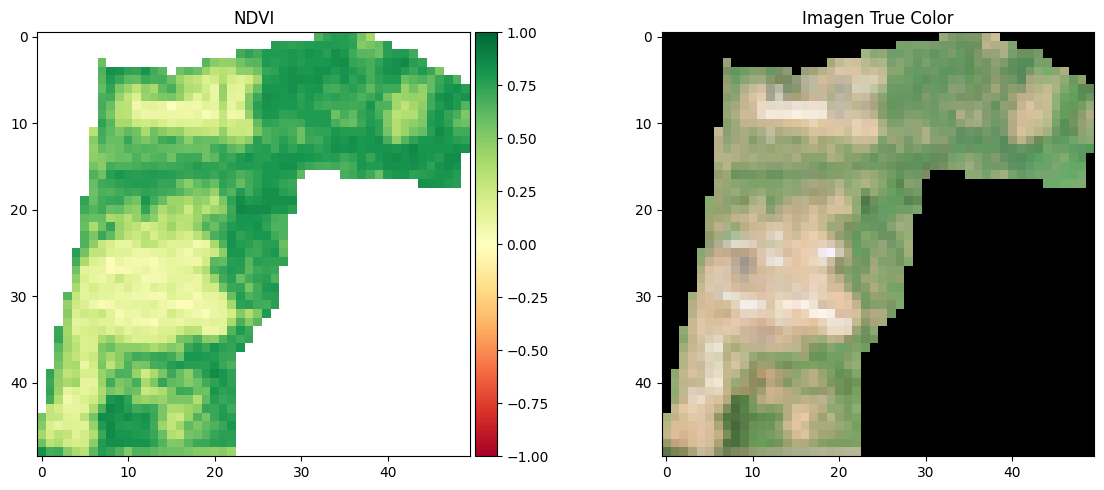

In [6]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

_, img = read_raster_rgb(PATH_TRUE_COLOR)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

im1 = ax1.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
ax1.set_title('NDVI')
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im1, cax=cax1)

ax2.imshow(img)
ax2.set_title('Imagen True Color')

plt.tight_layout()
plt.show()


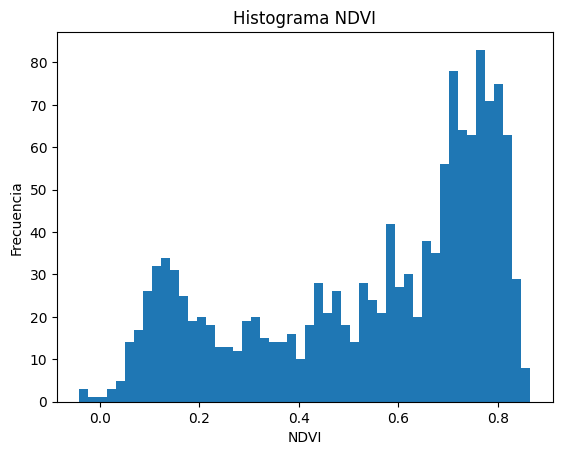

{'mean': 0.5444463491439819, 'median': 0.6274510025978088, 'p10': 0.1428571492433548, 'p90': 0.800000011920929}


In [7]:
plt.figure()
vals = ndvi[np.isfinite(ndvi)].ravel()
plt.hist(vals, bins=50)
plt.title('Histograma NDVI')
plt.xlabel('NDVI')
plt.ylabel('Frecuencia')
plt.show()

mean = float(np.nanmean(ndvi))
median = float(np.nanmedian(ndvi))
p10, p90 = float(np.nanpercentile(ndvi, 10)), float(np.nanpercentile(ndvi, 90))
print({"mean": mean, "median": median, "p10": p10, "p90": p90})


## 8) Guardar NDVI como GeoTIFF
El archivo se guardará con la misma proyección y transformada espacial que la banda de referencia.


In [8]:
out_path = 'outputs/ndvi.tif'
os.makedirs(os.path.dirname(out_path), exist_ok=True)
profile = ds_b8.profile.copy()
profile.update(dtype=rasterio.float32, count=1, nodata=np.nan)
with rasterio.open(out_path, 'w', **profile) as dst:
    dst.write(ndvi.astype('float32'), 1)
print('Guardado:', out_path)


Guardado: outputs/ndvi.tif


## Tarea: Comparación de dos fechas y mapa de cambio
Proporcione dos pares de bandas B4/B8 (t1 y t2). El resultado será un **mapa de diferencia de NDVI** (t2 - t1).


Ruta B4 t2 -> 2016/2016-12-05/2016-12-05-00_00_2016-12-05-23_59_Sentinel-2_L2A_B04_(Raw).tiff
Ruta B8 t2 -> 2016/2016-12-05/2016-12-05-00_00_2016-12-05-23_59_Sentinel-2_L2A_B08_(Raw).tiff


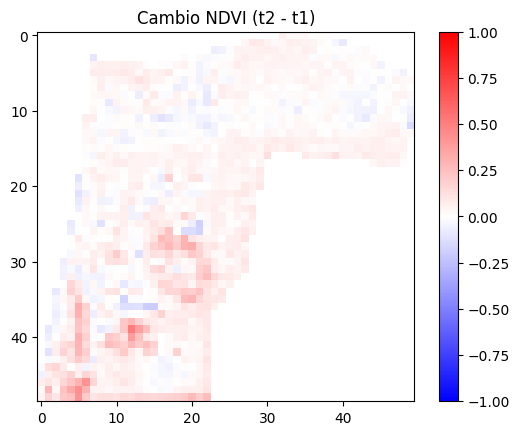

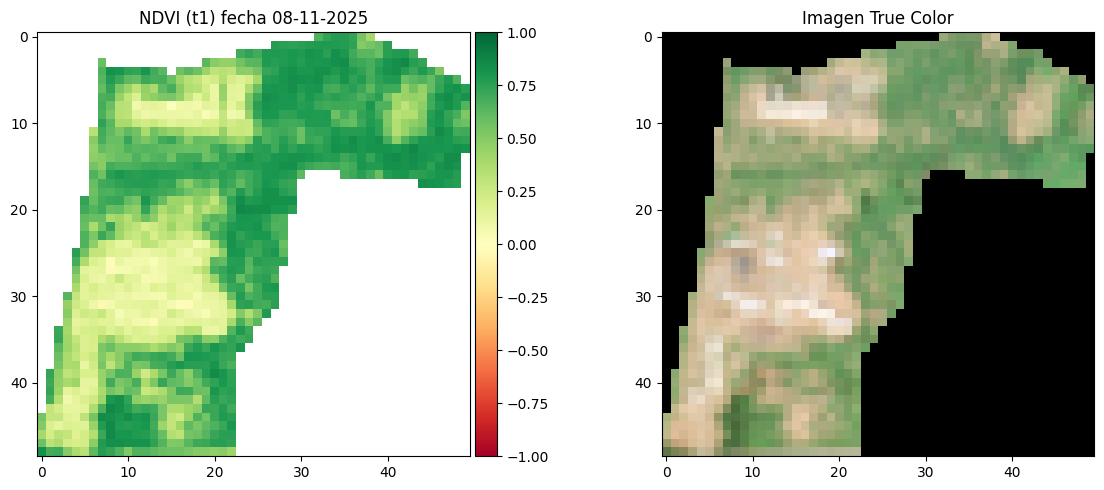

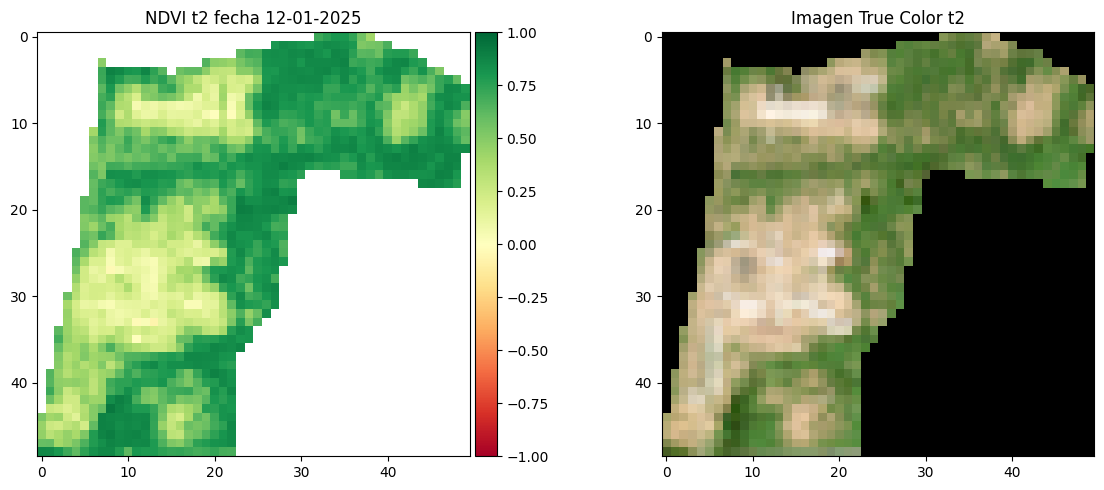

In [9]:
# Rutas de ejemplo para una segunda fecha (ajuste o deje en None)
PATH_B4_T2 = '2016/2016-12-05/2016-12-05-00_00_2016-12-05-23_59_Sentinel-2_L2A_B04_(Raw).tif'
PATH_B8_T2 = '2016/2016-12-05/2016-12-05-00_00_2016-12-05-23_59_Sentinel-2_L2A_B08_(Raw).tif'
# Asegurar extensión en la ruta True Color de la segunda fecha (evita error si falta la extensión)
PATH_TRUE_COLOR_T2 = '2016/2016-12-05/2016-12-05-00_00_2016-12-05-23_59_Sentinel-2_L2A_True_color.tiff'

have_t2 = False
ndvi_t2 = None
d_ndvi = None
img1 = None

# Si las rutas no existen exactamente, intentar detectar variantes (.tif/.tiff) o buscar en la carpeta data2
def find_band_file(path_hint, keyword='B04'):
    # Intenta variantes comunes de extensión y luego busca en data2 por palabra clave
    if path_hint and os.path.exists(path_hint):
        return path_hint
    # probar extensiones alternativas
    if path_hint:
        base = path_hint.rsplit('.', 1)[0]
        for ext in ('tif', 'tiff'):
            candidate = f'{base}.{ext}'
            if os.path.exists(candidate):
                return candidate
    # buscar en la carpeta data2 por keyword
    folder = os.path.dirname(path_hint) if path_hint else 'data2'
    if not folder:
        folder = 'data2'
    if os.path.isdir(folder):
        for fn in os.listdir(folder):
            if keyword in fn and (fn.lower().endswith('.tif') or fn.lower().endswith('.tiff')):
                return os.path.join(folder, fn)
    return None

# Resolver rutas (si las definidas no coinciden exactamente con archivos en disco)
PATH_B4_T2 = find_band_file(PATH_B4_T2, keyword='B04') or PATH_B4_T2
PATH_B8_T2 = find_band_file(PATH_B8_T2, keyword='B08') or PATH_B8_T2

print('Ruta B4 t2 ->', PATH_B4_T2)
print('Ruta B8 t2 ->', PATH_B8_T2)

# Verificar que las rutas estén definidas y que los archivos existan antes de abrirlos
if PATH_B4_T2 and PATH_B8_T2 and os.path.exists(PATH_B4_T2) and os.path.exists(PATH_B8_T2):
    try:
        ds_b4_t2, b4_t2 = read_raster(PATH_B4_T2)
        ds_b8_t2, b8_t2 = read_raster(PATH_B8_T2)
    except rasterio.errors.RasterioIOError as e:
        print("Error al abrir los archivos de la segunda fecha:", e)
    else:
        # Re-muestrear a la malla de referencia (ds_b8) si es necesario
        if (ds_b4_t2.width != ds_b8.width) or (ds_b4_t2.height != ds_b8.height) or (ds_b4_t2.transform != ds_b8.transform):
            b4_t2 = resample_to_match(ds_b4_t2, b4_t2, ds_b8)
        if (ds_b8_t2.width != ds_b8.width) or (ds_b8_t2.height != ds_b8.height) or (ds_b8_t2.transform != ds_b8.transform):
            b8_t2 = resample_to_match(ds_b8_t2, b8_t2, ds_b8)

        ndvi_t2 = compute_ndvi(b8_t2, b4_t2)
        ndvi_2016_2=ndvi_t2
        if valid_mask is not None:
            ndvi_t2 = np.where(valid_mask, ndvi_t2, np.nan)

        d_ndvi = ndvi_t2 - ndvi if ('ndvi' in globals() and ndvi is not None) else None
        have_t2 = True if ndvi_t2 is not None else False
        # Guardar diferencia NDVI en variables solicitadas:
        # - `df2016`: identificador válido en Python
        # - `2016df` almacenado en `globals()` (no es un identificador Python válido por iniciar con dígito)
        df2016 = d_ndvi
        globals()['2016df'] = d_ndvi

        plt.figure()
        plt.imshow(d_ndvi, cmap='bwr', vmin=-1, vmax=1) if d_ndvi is not None else print('No se puede mostrar d_ndvi (falta ndvi o ndvi_t2).')
        plt.title('Cambio NDVI (t2 - t1)')
        plt.colorbar() if d_ndvi is not None else None
        plt.show()
else:
    print('Proporcione PATH_B4_T2 y PATH_B8_T2 válidos y existentes en disco para calcular el cambio de NDVI entre fechas.')

# Mostrar NDVI y True Color t1 (si existe)
from mpl_toolkits.axes_grid1 import make_axes_locatable

try:
    if PATH_TRUE_COLOR and os.path.exists(PATH_TRUE_COLOR):
        _, img = read_raster_rgb(PATH_TRUE_COLOR)
    # si PATH_TRUE_COLOR no existe, puede que 'img' ya esté definido en el entorno; si no, se mostrará un placeholder
except Exception as e:
    print("No se pudo cargar PATH_TRUE_COLOR:", e)

if 'ndvi' in globals():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    im1 = ax1.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    ax1.set_title('NDVI (t1) fecha 08-11-2025')
    divider1 = make_axes_locatable(ax1)
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im1, cax=cax1)

    if 'img' in globals():
        ax2.imshow(img)
        ax2.set_title('Imagen True Color')
    else:
        ax2.text(0.5, 0.5, 'No True Color disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()
else:
    print("NDVI (t1) no disponible para mostrar.")

# Cargar y mostrar True Color t2 (si existe)
if PATH_TRUE_COLOR_T2 and os.path.exists(PATH_TRUE_COLOR_T2):
    try:
        _, img1 = read_raster_rgb(PATH_TRUE_COLOR_T2)
    except Exception as e:
        print("No se pudo cargar PATH_TRUE_COLOR_T2:", e)
        img1 = None
else:
    print("PATH_TRUE_COLOR_T2 no existe o no está definido, se omitirá la visualización de t2.")

# Mostrar NDVI t2 y True Color t2 si están disponibles
if have_t2 or (img1 is not None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    if have_t2:
        im1 = ax1.imshow(ndvi_t2, cmap='RdYlGn', vmin=-1, vmax=1)
        ax1.set_title('NDVI t2 fecha 12-01-2025')
        divider1 = make_axes_locatable(ax1)
        cax1 = divider1.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(im1, cax=cax1)
    else:
        ax1.text(0.5, 0.5, 'NDVI t2 no disponible', ha='center', va='center')
        ax1.set_axis_off()

    if img1 is not None:
        ax2.imshow(img1)
        ax2.set_title('Imagen True Color t2')
    else:
        ax2.text(0.5, 0.5, 'True Color t2 no disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()






Ubicación del máximo NDVI (fila, columna): (np.int64(43), np.int64(8))


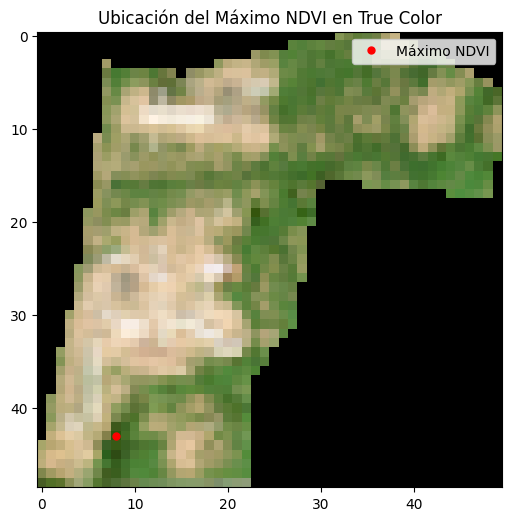

In [10]:
# Ubicación del máximo ndvi en filas y columnas
max_ndvi_idx = np.unravel_index(np.nanargmax(ndvi_t2), ndvi.shape)
print("Ubicación del máximo NDVI (fila, columna):", max_ndvi_idx)

# Visualización del píxel con máximo NDVI en la imagen true color
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img1)
ax.plot(max_ndvi_idx[1], max_ndvi_idx[0], 'ro', markersize=5, label='Máximo NDVI')
ax.set_title('Ubicación del Máximo NDVI en True Color') 
ax.legend()

Ubicación del máximo NDVI (fila, columna): (np.int64(43), np.int64(8))


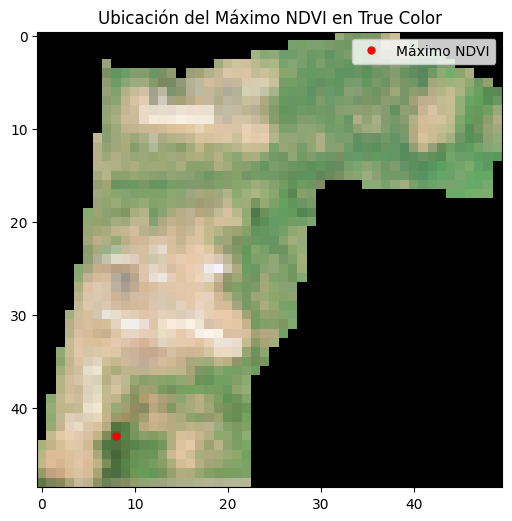

In [11]:
# Ubicación del máximo ndvi en filas y columnas
max_ndvi_idx = np.unravel_index(np.nanargmax(ndvi), ndvi.shape)
print("Ubicación del máximo NDVI (fila, columna):", max_ndvi_idx)

# Visualización del píxel con máximo NDVI en la imagen true color
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img)
ax.plot(max_ndvi_idx[1], max_ndvi_idx[0], 'ro', markersize=5, label='Máximo NDVI')
ax.set_title('Ubicación del Máximo NDVI en True Color') 
ax.legend()

In [12]:
if ndvi is None:
    print("ERROR: NDVI de la primera fecha (ndvi) no está definido.")
elif ndvi_t2 is None:
    print("ERROR: NDVI de la segunda fecha (ndvi_t2) no está definido.")
else:
    # ----------------------------
    # NDVI T1 (primera fecha)
    # ----------------------------
    ndvi1_max = np.nanmax(ndvi)
    ndvi1_min = np.nanmin(ndvi)
    ndvi1_mean = np.nanmean(ndvi)

    # ----------------------------
    # NDVI T2 (segunda fecha)
    # ----------------------------
    ndvi2_max = np.nanmax(ndvi_t2)
    ndvi2_min = np.nanmin(ndvi_t2)
    ndvi2_mean = np.nanmean(ndvi_t2)

    # ----------------------------
    # DIFERENCIA NDVI (t2 - t1)
    # ----------------------------
    dndvi_max = np.nanmax(d_ndvi)
    dndvi_min = np.nanmin(d_ndvi)
    dndvi_mean = np.nanmean(d_ndvi)

    print("\n===== NDVI FECHA 1 (t1) =====")
    print("NDVI max :", ndvi1_max)
    print("NDVI min :", ndvi1_min)
    print("NDVI mean:", ndvi1_mean)

    print("\n===== NDVI FECHA 2 (t2) =====")
    print("NDVI max :", ndvi2_max)
    print("NDVI min :", ndvi2_min)
    print("NDVI mean:", ndvi2_mean)

    print("\n===== DIFERENCIA NDVI (t2 - t1) =====")
    print("NDVI diff max :", dndvi_max)
    print("NDVI diff min :", dndvi_min)
    print("NDVI diff mean:", dndvi_mean)



===== NDVI FECHA 1 (t1) =====
NDVI max : 0.8651685
NDVI min : -0.04109589
NDVI mean: 0.54444635

===== NDVI FECHA 2 (t2) =====
NDVI max : 0.9220779
NDVI min : -0.06666667
NDVI mean: 0.5850972

===== DIFERENCIA NDVI (t2 - t1) =====
NDVI diff max : 0.50855136
NDVI diff min : -0.20006636
NDVI diff mean: 0.040650755


Ruta B4 t2 -> 2016/2016-12-05/2016-12-05-00_00_2016-12-05-23_59_Sentinel-2_L2A_B04_(Raw).tiff
Ruta B8 t2 -> 2016/2016-12-05/2016-12-05-00_00_2016-12-05-23_59_Sentinel-2_L2A_B08_(Raw).tiff


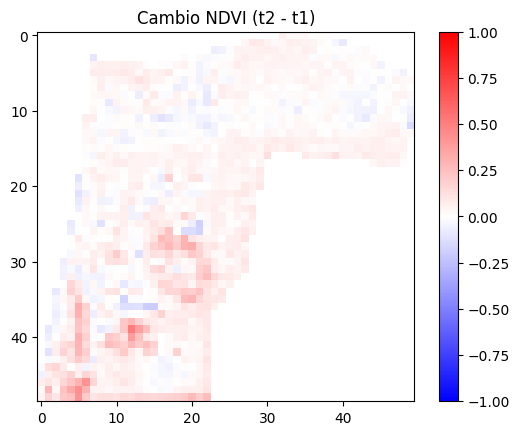

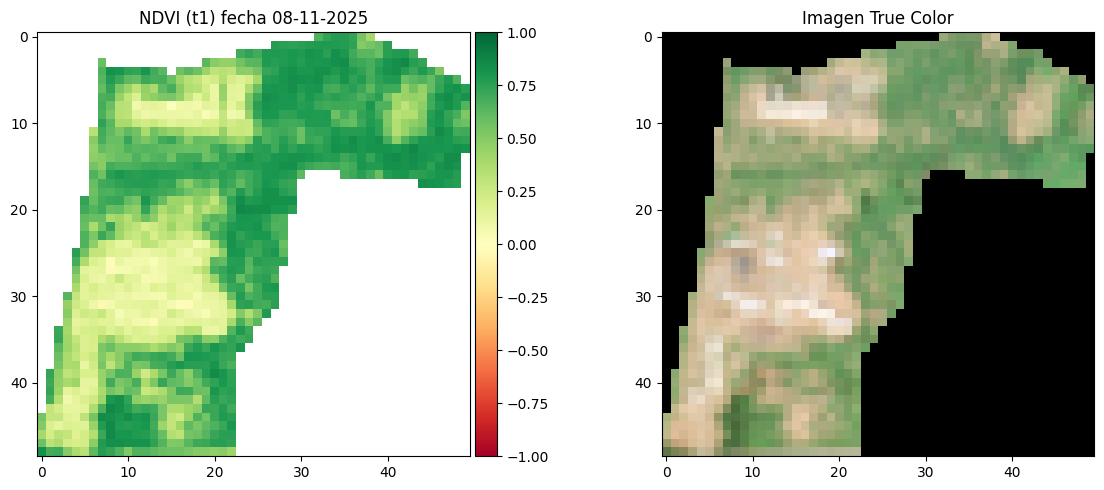

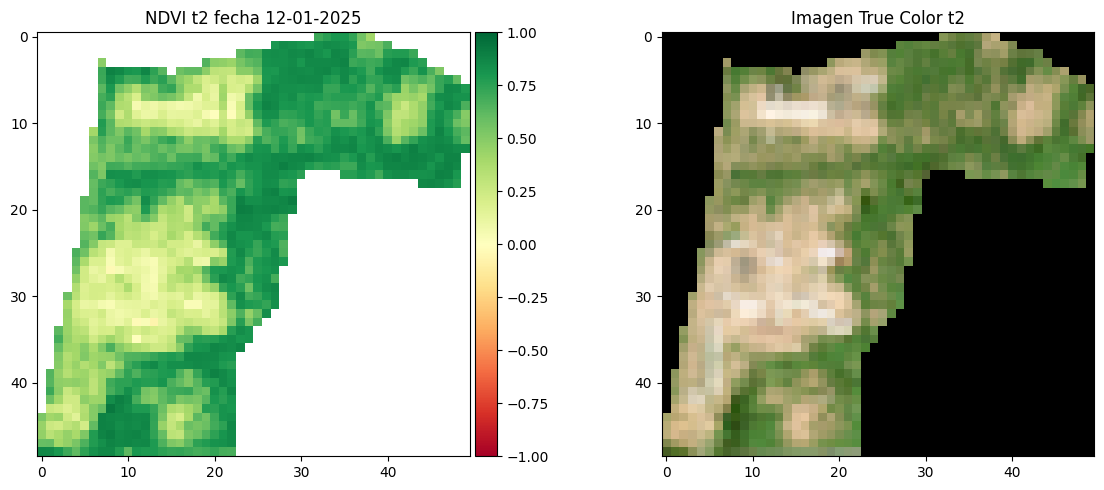

In [13]:
# Rutas de ejemplo para una segunda fecha (ajuste o deje en None)
PATH_B4_T2 = '2016/2016-12-05/2016-12-05-00_00_2016-12-05-23_59_Sentinel-2_L2A_B04_(Raw).tif'
PATH_B8_T2 = '2016/2016-12-05/2016-12-05-00_00_2016-12-05-23_59_Sentinel-2_L2A_B08_(Raw).tif'
# Asegurar extensión en la ruta True Color de la segunda fecha (evita error si falta la extensión)
PATH_TRUE_COLOR_T2 = '2016/2016-12-05/2016-12-05-00_00_2016-12-05-23_59_Sentinel-2_L2A_True_color.tiff'

have_t2 = False
ndvi_t2 = None
d_ndvi = None
img1 = None

# Si las rutas no existen exactamente, intentar detectar variantes (.tif/.tiff) o buscar en la carpeta data2
def find_band_file(path_hint, keyword='B04'):
    # Intenta variantes comunes de extensión y luego busca en data2 por palabra clave
    if path_hint and os.path.exists(path_hint):
        return path_hint
    # probar extensiones alternativas
    if path_hint:
        base = path_hint.rsplit('.', 1)[0]
        for ext in ('tif', 'tiff'):
            candidate = f'{base}.{ext}'
            if os.path.exists(candidate):
                return candidate
    # buscar en la carpeta data2 por keyword
    folder = os.path.dirname(path_hint) if path_hint else 'data2'
    if not folder:
        folder = 'data2'
    if os.path.isdir(folder):
        for fn in os.listdir(folder):
            if keyword in fn and (fn.lower().endswith('.tif') or fn.lower().endswith('.tiff')):
                return os.path.join(folder, fn)
    return None

# Resolver rutas (si las definidas no coinciden exactamente con archivos en disco)
PATH_B4_T2 = find_band_file(PATH_B4_T2, keyword='B04') or PATH_B4_T2
PATH_B8_T2 = find_band_file(PATH_B8_T2, keyword='B08') or PATH_B8_T2

print('Ruta B4 t2 ->', PATH_B4_T2)
print('Ruta B8 t2 ->', PATH_B8_T2)

# Verificar que las rutas estén definidas y que los archivos existan antes de abrirlos
if PATH_B4_T2 and PATH_B8_T2 and os.path.exists(PATH_B4_T2) and os.path.exists(PATH_B8_T2):
    try:
        ds_b4_t2, b4_t2 = read_raster(PATH_B4_T2)
        ds_b8_t2, b8_t2 = read_raster(PATH_B8_T2)
    except rasterio.errors.RasterioIOError as e:
        print("Error al abrir los archivos de la segunda fecha:", e)
    else:
        # Re-muestrear a la malla de referencia (ds_b8) si es necesario
        if (ds_b4_t2.width != ds_b8.width) or (ds_b4_t2.height != ds_b8.height) or (ds_b4_t2.transform != ds_b8.transform):
            b4_t2 = resample_to_match(ds_b4_t2, b4_t2, ds_b8)
        if (ds_b8_t2.width != ds_b8.width) or (ds_b8_t2.height != ds_b8.height) or (ds_b8_t2.transform != ds_b8.transform):
            b8_t2 = resample_to_match(ds_b8_t2, b8_t2, ds_b8)

        ndvi_t2 = compute_ndvi(b8_t2, b4_t2)
        if valid_mask is not None:
            ndvi_t2 = np.where(valid_mask, ndvi_t2, np.nan)
            
        d_ndvi = ndvi_t2 - ndvi if ('ndvi' in globals() and ndvi is not None) else None
        have_t2 = True if ndvi_t2 is not None else False
        # Guardar diferencia NDVI en variables solicitadas:
        # - `df2016`: identificador válido en Python
        # - `2016df` almacenado en `globals()` (no es un identificador Python válido por iniciar con dígito)
        df2016 = d_ndvi
        globals()['2016df'] = d_ndvi
        ndvi_2016_2=ndvi_t2
        plt.figure()
        plt.imshow(d_ndvi, cmap='bwr', vmin=-1, vmax=1) if d_ndvi is not None else print('No se puede mostrar d_ndvi (falta ndvi o ndvi_t2).')
        plt.title('Cambio NDVI (t2 - t1)')
        plt.colorbar() if d_ndvi is not None else None
        plt.show()
else:
    print('Proporcione PATH_B4_T2 y PATH_B8_T2 válidos y existentes en disco para calcular el cambio de NDVI entre fechas.')

# Mostrar NDVI y True Color t1 (si existe)
from mpl_toolkits.axes_grid1 import make_axes_locatable

try:
    if PATH_TRUE_COLOR and os.path.exists(PATH_TRUE_COLOR):
        _, img = read_raster_rgb(PATH_TRUE_COLOR)
    # si PATH_TRUE_COLOR no existe, puede que 'img' ya esté definido en el entorno; si no, se mostrará un placeholder
except Exception as e:
    print("No se pudo cargar PATH_TRUE_COLOR:", e)

if 'ndvi' in globals():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    im1 = ax1.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    ax1.set_title('NDVI (t1) fecha 08-11-2025')
    divider1 = make_axes_locatable(ax1)
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im1, cax=cax1)

    if 'img' in globals():
        ax2.imshow(img)
        ax2.set_title('Imagen True Color')
    else:
        ax2.text(0.5, 0.5, 'No True Color disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()
else:
    print("NDVI (t1) no disponible para mostrar.")

# Cargar y mostrar True Color t2 (si existe)
if PATH_TRUE_COLOR_T2 and os.path.exists(PATH_TRUE_COLOR_T2):
    try:
        _, img1 = read_raster_rgb(PATH_TRUE_COLOR_T2)
    except Exception as e:
        print("No se pudo cargar PATH_TRUE_COLOR_T2:", e)
        img1 = None
else:
    print("PATH_TRUE_COLOR_T2 no existe o no está definido, se omitirá la visualización de t2.")

# Mostrar NDVI t2 y True Color t2 si están disponibles
if have_t2 or (img1 is not None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    if have_t2:
        im1 = ax1.imshow(ndvi_t2, cmap='RdYlGn', vmin=-1, vmax=1)
        ax1.set_title('NDVI t2 fecha 12-01-2025')
        divider1 = make_axes_locatable(ax1)
        cax1 = divider1.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(im1, cax=cax1)
    else:
        ax1.text(0.5, 0.5, 'NDVI t2 no disponible', ha='center', va='center')
        ax1.set_axis_off()

    if img1 is not None:
        ax2.imshow(img1)
        ax2.set_title('Imagen True Color t2')
    else:
        ax2.text(0.5, 0.5, 'True Color t2 no disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()






## (Tarea opcional) Estadísticas zonales por polígonos
Calcule estadísticas de NDVI por polígonos (veredas, fincas, municipios, etc.). Requiere `geopandas` y `rasterstats`.


2017

B4 shape: (49, 50) B8 shape: (49, 50)
NDVI rango: min=-0.125, max=0.916


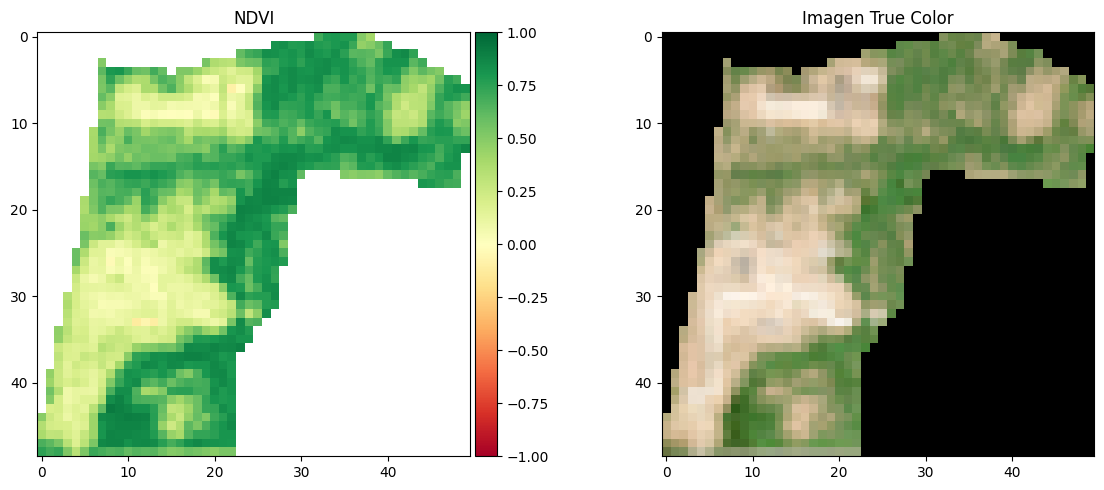

Ruta B4 t2 -> 2017/2017-12-15/2017-12-15-00_00_2017-12-15-23_59_Sentinel-2_L2A_B04_(Raw).tiff
Ruta B8 t2 -> 2017/2017-12-15/2017-12-15-00_00_2017-12-15-23_59_Sentinel-2_L2A_B08_(Raw).tiff


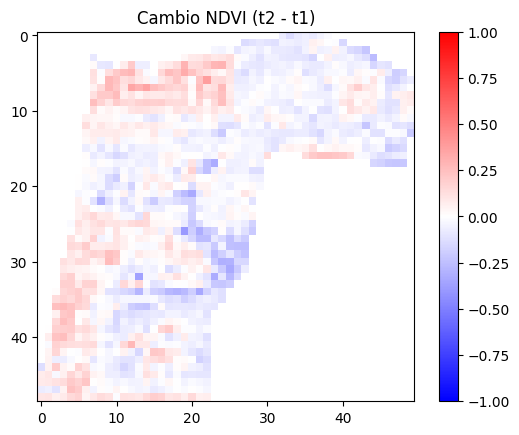

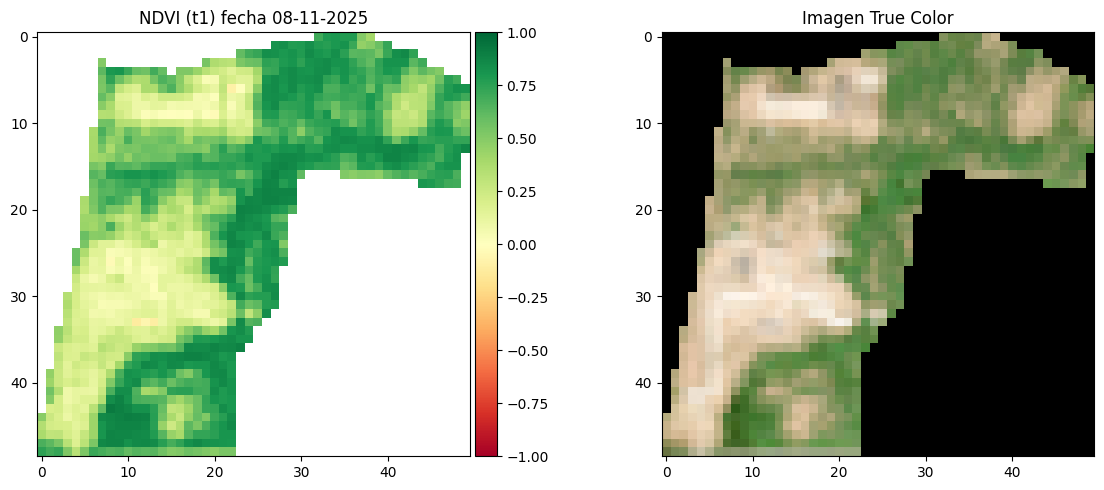

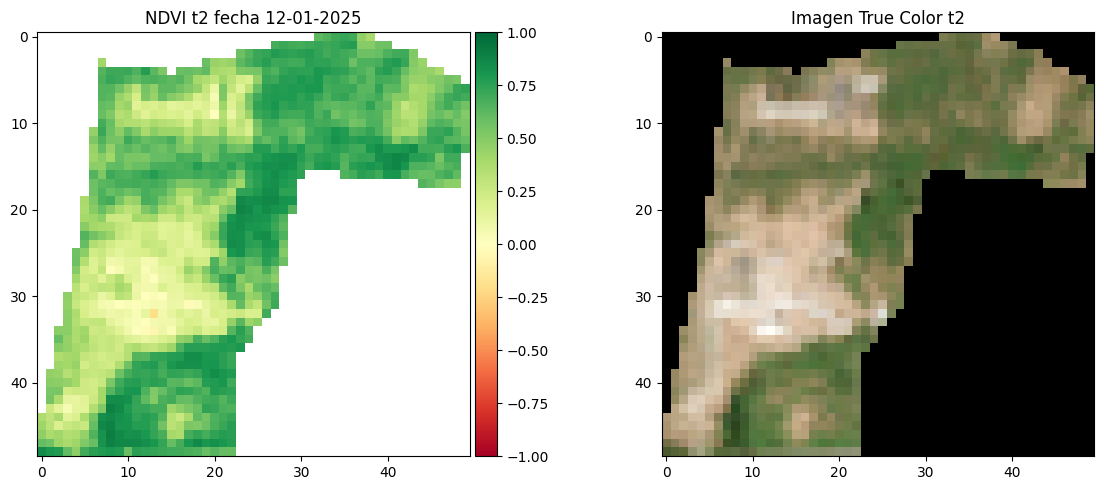

In [61]:

# Rutas de ejemplo: ajuste a su caso
PATH_B4 = '2017/2017-06-03/2017-06-03-00_00_2017-06-03-23_59_Sentinel-2_L2A_B04_(Raw).tiff'   # Banda roja
PATH_B8 = '2017/2017-06-03/2017-06-03-00_00_2017-06-03-23_59_Sentinel-2_L2A_B08_(Raw).tiff'   # Banda NIR
PATH_TRUE_COLOR = '2017/2017-06-03/2017-06-03-00_00_2017-06-03-23_59_Sentinel-2_L2A_True_color.tiff'

# Helper: buscar variantes de nombre/extension o en carpeta 'data2' antes de intentar abrir
def find_band_file(path_hint, keyword=None):
    if path_hint and os.path.exists(path_hint):
        return path_hint
    if path_hint:
        base = path_hint.rsplit('.', 1)[0]
        for ext in ('tif', 'tiff'):
            candidate = f'{base}.{ext}'
            if os.path.exists(candidate):
                return candidate
    folder = os.path.dirname(path_hint) if path_hint else 'data2'
    if not folder:
        folder = 'data2'
    if os.path.isdir(folder):
        for fn in os.listdir(folder):
            if (keyword is None or keyword in fn) and (fn.lower().endswith('.tif') or fn.lower().endswith('.tiff')):
                return os.path.join(folder, fn)
    return None

# Intentar resolver rutas antes de abrir para evitar RasterioIOError
PATH_B4 = find_band_file(PATH_B4, keyword='B04') or PATH_B4
PATH_B8 = find_band_file(PATH_B8, keyword='B08') or PATH_B8
PATH_TRUE_COLOR = find_band_file(PATH_TRUE_COLOR, keyword='True_color') or PATH_TRUE_COLOR

# Inicializar variables por si no podemos abrir los archivos
ds_b4 = ds_b8 = None
b4 = b8 = None

# Solo abrir si existe el archivo resuelto y capturar errores
if PATH_B4 and os.path.exists(PATH_B4):
    try:
        ds_b4, b4 = read_raster(PATH_B4)
    except Exception as e:
        print(f"Error al abrir PATH_B4 ({PATH_B4}):", e)
        ds_b4 = b4 = None
else:
    print(f"PATH_B4 no existe: {PATH_B4}")

if PATH_B8 and os.path.exists(PATH_B8):
    try:
        ds_b8, b8 = read_raster(PATH_B8)
    except Exception as e:
        print(f"Error al abrir PATH_B8 ({PATH_B8}):", e)
        ds_b8 = b8 = None
else:
    print(f"PATH_B8 no existe: {PATH_B8}")

# Si ambos bandas se cargaron correctamente, continuar
if ds_b4 is not None and ds_b8 is not None and b4 is not None and b8 is not None:
    # Si las dimensiones difieren, re-muestrear B4 a la malla de B8
    try:
        if (ds_b4.width != ds_b8.width) or (ds_b4.height != ds_b8.height) or (ds_b4.transform != ds_b8.transform):
            b4 = resample_to_match(ds_b4, b4, ds_b8)
    except Exception as e:
        print("Error al comparar/resamplear mallas:", e)

    print("B4 shape:", b4.shape, "B8 shape:", b8.shape)

    ndvi = compute_ndvi(b8, b4)
    if valid_mask is not None:
        ndvi = np.where(valid_mask, ndvi, np.nan)
    ndvi_min, ndvi_max = np.nanmin(ndvi), np.nanmax(ndvi)
    print(f"NDVI rango: min={ndvi_min:.3f}, max={ndvi_max:.3f}")
else:
    print("No se pudieron cargar B4 y/o B8 de la primera fecha. Se omite cálculo de NDVI (t1).")
    ndvi = None

ndvi_2017_1 = ndvi

from mpl_toolkits.axes_grid1 import make_axes_locatable

# Cargar imagen True Color solo si existe; si no, usar 'img' ya presente en el entorno o mostrar placeholder
img = None
try:
    if PATH_TRUE_COLOR and os.path.exists(PATH_TRUE_COLOR):
        _, img = read_raster_rgb(PATH_TRUE_COLOR)
    else:
        print(f"PATH_TRUE_COLOR no existe: {PATH_TRUE_COLOR}. Se usará 'img' existente en el entorno si hay.")
        img = globals().get('img', None)
except Exception as e:
    print("Error al cargar PATH_TRUE_COLOR:", e)
    img = globals().get('img', None)

# Evitar intentar plotear NDVI si no está disponible
if ndvi is None:
    print("NDVI no disponible — se omitirá la visualización inicial.")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    im1 = ax1.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    ax1.set_title('NDVI')
    divider1 = make_axes_locatable(ax1)
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im1, cax=cax1)

    if img is not None:
        ax2.imshow(img)
        ax2.set_title('Imagen True Color')
    else:
        ax2.text(0.5, 0.5, 'No True Color disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()


# Rutas de ejemplo para una segunda fecha (ajuste o deje en None)
PATH_B4_T2 = '2017/2017-12-15/2017-12-15-00_00_2017-12-15-23_59_Sentinel-2_L2A_B04_(Raw).tif'
PATH_B8_T2 = '2017/2017-12-15/2017-12-15-00_00_2017-12-15-23_59_Sentinel-2_L2A_B08_(Raw).tif'
# Asegurar extensión en la ruta True Color de la segunda fecha (evita error si falta la extensión)
PATH_TRUE_COLOR_T2 = '2017/2017-12-15/2017-12-15-00_00_2017-12-15-23_59_Sentinel-2_L2A_True_color.tiff'

have_t2 = False
ndvi_t2 = None
d_ndvi = None
img1 = None

# Resolver rutas (si las definidas no coinciden exactamente con archivos en disco)
PATH_B4_T2 = find_band_file(PATH_B4_T2, keyword='B04') or PATH_B4_T2
PATH_B8_T2 = find_band_file(PATH_B8_T2, keyword='B08') or PATH_B8_T2

print('Ruta B4 t2 ->', PATH_B4_T2)
print('Ruta B8 t2 ->', PATH_B8_T2)

# Verificar que las rutas estén definidas y que los archivos existan antes de abrirlos
if PATH_B4_T2 and PATH_B8_T2 and os.path.exists(PATH_B4_T2) and os.path.exists(PATH_B8_T2):
    try:
        ds_b4_t2, b4_t2 = read_raster(PATH_B4_T2)
        ds_b8_t2, b8_t2 = read_raster(PATH_B8_T2)
    except rasterio.errors.RasterioIOError as e:
        print("Error al abrir los archivos de la segunda fecha:", e)
    else:
        # Si no hay referencia de ds_b8 (t1) usar ds_b8_t2 como referencia para resamplear
        ref_ds = ds_b8 if (ds_b8 is not None) else ds_b8_t2
        try:
            if ds_b4_t2 is not None and ref_ds is not None and ((ds_b4_t2.width != ref_ds.width) or (ds_b4_t2.height != ref_ds.height) or (ds_b4_t2.transform != ref_ds.transform)):
                b4_t2 = resample_to_match(ds_b4_t2, b4_t2, ref_ds)
            if ds_b8_t2 is not None and ref_ds is not None and ((ds_b8_t2.width != ref_ds.width) or (ds_b8_t2.height != ref_ds.height) or (ds_b8_t2.transform != ref_ds.transform)):
                b8_t2 = resample_to_match(ds_b8_t2, b8_t2, ref_ds)
        except Exception as e:
            print("Error al re-muestrear bandas t2:", e)

        try:
            ndvi_t2 = compute_ndvi(b8_t2, b4_t2)
            ndvi_2017_2 = ndvi_t2
            if valid_mask is not None and ndvi_t2 is not None:
                ndvi_t2 = np.where(valid_mask, ndvi_t2, np.nan)
        except Exception as e:
            print("Error al calcular NDVI t2:", e)
            ndvi_t2 = None

        d_ndvi = None
        if (ndvi is not None) and (ndvi_t2 is not None):
            d_ndvi = ndvi_t2 - ndvi
        have_t2 = True if ndvi_t2 is not None else False
        # Guardar diferencia NDVI en variables solicitadas:
        df2017 = d_ndvi
        globals()['2016df'] = d_ndvi
        ndvi_2017_2 = ndvi_t2
        plt.figure()
        if d_ndvi is not None:
            plt.imshow(d_ndvi, cmap='bwr', vmin=-1, vmax=1)
            plt.title('Cambio NDVI (t2 - t1)')
            plt.colorbar()
        else:
            print('No se puede mostrar d_ndvi (falta ndvi o ndvi_t2).')
        plt.show()
else:
    print('Proporcione PATH_B4_T2 y PATH_B8_T2 válidos y existentes en disco para calcular el cambio de NDVI entre fechas.')

# Mostrar NDVI y True Color t1 (si existe)
from mpl_toolkits.axes_grid1 import make_axes_locatable

try:
    if PATH_TRUE_COLOR and os.path.exists(PATH_TRUE_COLOR):
        _, img = read_raster_rgb(PATH_TRUE_COLOR)
    # si PATH_TRUE_COLOR no existe, puede que 'img' ya esté definido en el entorno; si no, se mostrará un placeholder
except Exception as e:
    print("No se pudo cargar PATH_TRUE_COLOR:", e)
    img = globals().get('img', None)

if ndvi is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    im1 = ax1.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    ax1.set_title('NDVI (t1) fecha 08-11-2025')
    divider1 = make_axes_locatable(ax1)
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im1, cax=cax1)

    if img is not None:
        ax2.imshow(img)
        ax2.set_title('Imagen True Color')
    else:
        ax2.text(0.5, 0.5, 'No True Color disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()
else:
    print("NDVI (t1) no disponible para mostrar.")

# Cargar y mostrar True Color t2 (si existe)
if PATH_TRUE_COLOR_T2 and os.path.exists(PATH_TRUE_COLOR_T2):
    try:
        _, img1 = read_raster_rgb(PATH_TRUE_COLOR_T2)
    except Exception as e:
        print("No se pudo cargar PATH_TRUE_COLOR_T2:", e)
        img1 = None
else:
    print("PATH_TRUE_COLOR_T2 no existe o no está definido, se omitirá la visualización de t2.")

# Mostrar NDVI t2 y True Color t2 si están disponibles
if have_t2 or (img1 is not None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    if have_t2 and ndvi_t2 is not None:
        im1 = ax1.imshow(ndvi_t2, cmap='RdYlGn', vmin=-1, vmax=1)
        ax1.set_title('NDVI t2 fecha 12-01-2025')
        divider1 = make_axes_locatable(ax1)
        cax1 = divider1.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(im1, cax=cax1)
    else:
        ax1.text(0.5, 0.5, 'NDVI t2 no disponible', ha='center', va='center')
        ax1.set_axis_off()

    if img1 is not None:
        ax2.imshow(img1)
        ax2.set_title('Imagen True Color t2')
    else:
        ax2.text(0.5, 0.5, 'True Color t2 no disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()






Ubicación del máximo NDVI (fila, columna): (np.int64(46), np.int64(8))


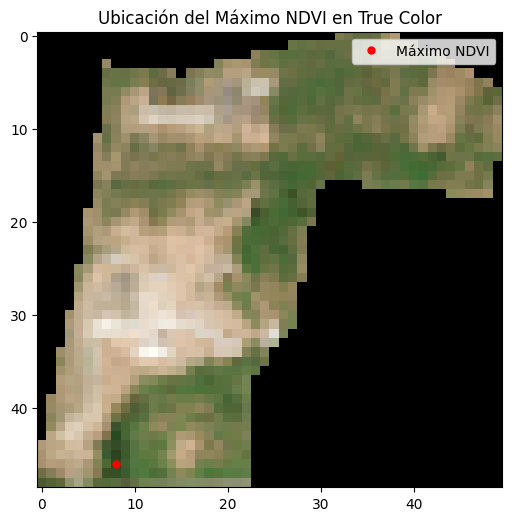

In [62]:
# Ubicación del máximo ndvi en filas y columnas
max_ndvi_idx = np.unravel_index(np.nanargmax(ndvi_t2), ndvi.shape)
print("Ubicación del máximo NDVI (fila, columna):", max_ndvi_idx)

# Visualización del píxel con máximo NDVI en la imagen true color
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img1)
ax.plot(max_ndvi_idx[1], max_ndvi_idx[0], 'ro', markersize=5, label='Máximo NDVI')
ax.set_title('Ubicación del Máximo NDVI en True Color') 
ax.legend()

Ubicación del máximo NDVI (fila, columna): (np.int64(43), np.int64(8))


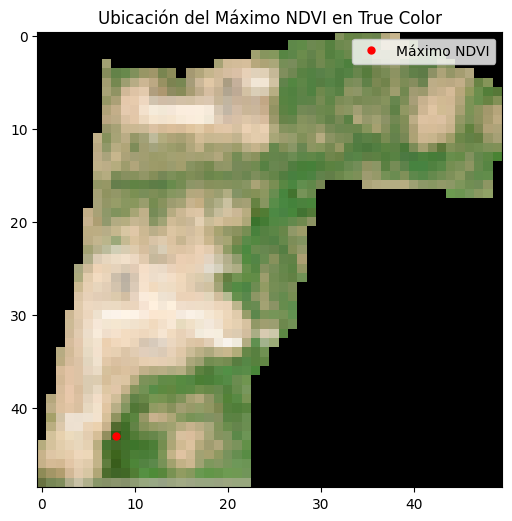

In [63]:
# Ubicación del máximo ndvi en filas y columnas
max_ndvi_idx = np.unravel_index(np.nanargmax(ndvi), ndvi.shape)
print("Ubicación del máximo NDVI (fila, columna):", max_ndvi_idx)

# Visualización del píxel con máximo NDVI en la imagen true color
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img)
ax.plot(max_ndvi_idx[1], max_ndvi_idx[0], 'ro', markersize=5, label='Máximo NDVI')
ax.set_title('Ubicación del Máximo NDVI en True Color') 
ax.legend()

2018


B4 shape: (49, 50) B8 shape: (49, 50)
NDVI rango: min=-0.093, max=0.848


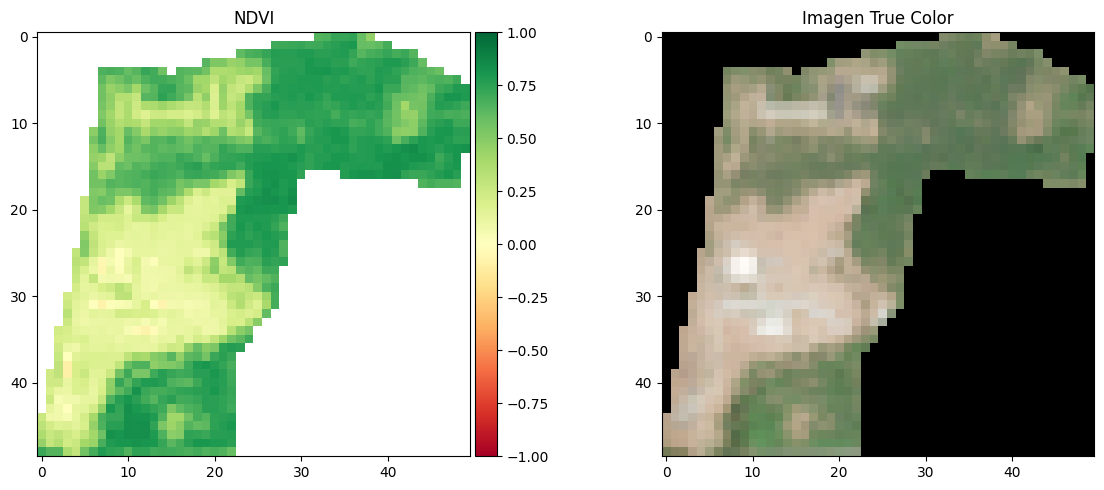

Ruta B4 t2 -> 2018/2018-12-25/2018-12-25-00_00_2018-12-25-23_59_Sentinel-2_L2A_B04_(Raw).tiff
Ruta B8 t2 -> 2018/2018-12-25/2018-12-25-00_00_2018-12-25-23_59_Sentinel-2_L2A_B08_(Raw).tiff


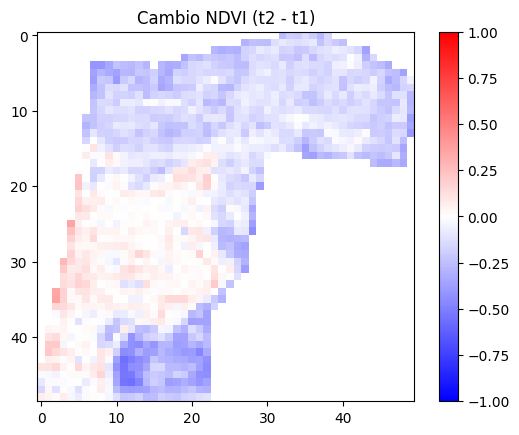

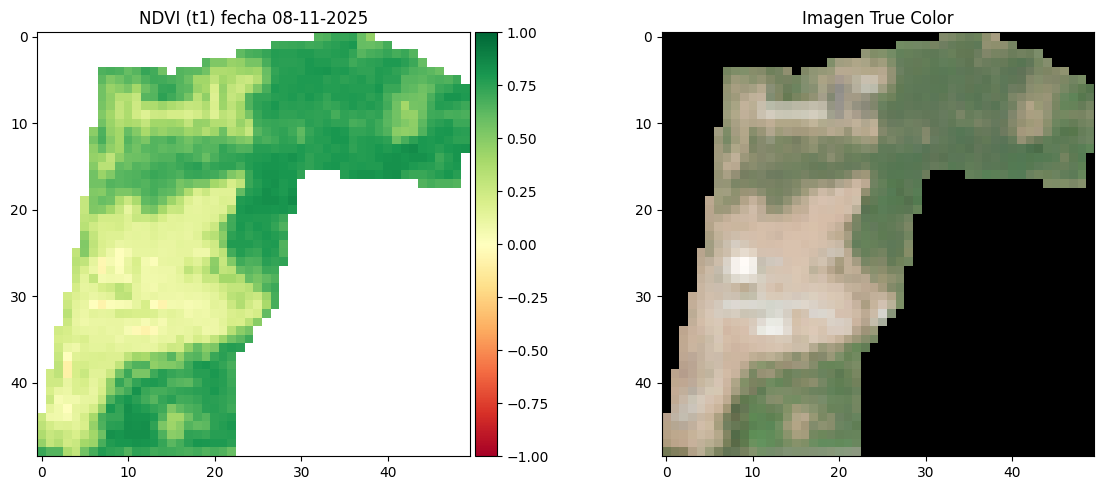

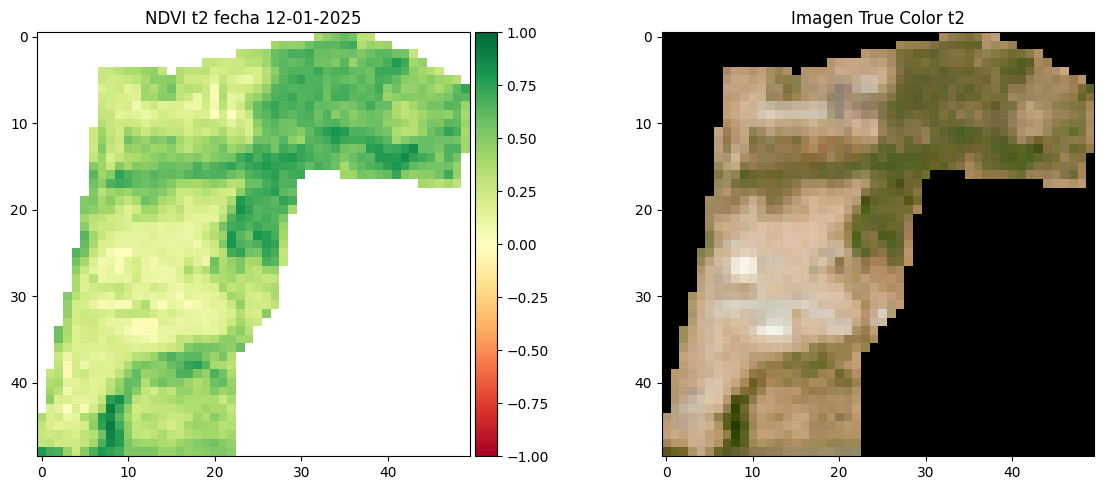

In [64]:

# Rutas de ejemplo: ajuste a su caso
PATH_B4 = '2018/2018-06-13/2018-06-13-00_00_2018-06-13-23_59_Sentinel-2_L2A_B04_(Raw).tiff'   # Banda roja
PATH_B8 = '2018/2018-06-13/2018-06-13-00_00_2018-06-13-23_59_Sentinel-2_L2A_B08_(Raw).tiff'   # Banda NIR
PATH_TRUE_COLOR = '2018/2018-06-13/2018-06-13-00_00_2018-06-13-23_59_Sentinel-2_L2A_True_color.tiff'

# Helper: buscar variantes de nombre/extension o en carpeta 'data2' antes de intentar abrir
def find_band_file(path_hint, keyword=None):
    if path_hint and os.path.exists(path_hint):
        return path_hint
    if path_hint:
        base = path_hint.rsplit('.', 1)[0]
        for ext in ('tif', 'tiff'):
            candidate = f'{base}.{ext}'
            if os.path.exists(candidate):
                return candidate
    folder = os.path.dirname(path_hint) if path_hint else 'data2'
    if not folder:
        folder = 'data2'
    if os.path.isdir(folder):
        for fn in os.listdir(folder):
            if (keyword is None or keyword in fn) and (fn.lower().endswith('.tif') or fn.lower().endswith('.tiff')):
                return os.path.join(folder, fn)
    return None

# Intentar resolver rutas antes de abrir para evitar RasterioIOError
PATH_B4 = find_band_file(PATH_B4, keyword='B04') or PATH_B4
PATH_B8 = find_band_file(PATH_B8, keyword='B08') or PATH_B8
PATH_TRUE_COLOR = find_band_file(PATH_TRUE_COLOR, keyword='True_color') or PATH_TRUE_COLOR

# Inicializar variables por si no podemos abrir los archivos
ds_b4 = ds_b8 = None
b4 = b8 = None

# Solo abrir si existe el archivo resuelto y capturar errores
if PATH_B4 and os.path.exists(PATH_B4):
    try:
        ds_b4, b4 = read_raster(PATH_B4)
    except Exception as e:
        print(f"Error al abrir PATH_B4 ({PATH_B4}):", e)
        ds_b4 = b4 = None
else:
    print(f"PATH_B4 no existe: {PATH_B4}")

if PATH_B8 and os.path.exists(PATH_B8):
    try:
        ds_b8, b8 = read_raster(PATH_B8)
    except Exception as e:
        print(f"Error al abrir PATH_B8 ({PATH_B8}):", e)
        ds_b8 = b8 = None
else:
    print(f"PATH_B8 no existe: {PATH_B8}")

# Si ambos bandas se cargaron correctamente, continuar
if ds_b4 is not None and ds_b8 is not None and b4 is not None and b8 is not None:
    # Si las dimensiones difieren, re-muestrear B4 a la malla de B8
    try:
        if (ds_b4.width != ds_b8.width) or (ds_b4.height != ds_b8.height) or (ds_b4.transform != ds_b8.transform):
            b4 = resample_to_match(ds_b4, b4, ds_b8)
    except Exception as e:
        print("Error al comparar/resamplear mallas:", e)

    print("B4 shape:", b4.shape, "B8 shape:", b8.shape)

    ndvi = compute_ndvi(b8, b4)
    ndvi_2018_1 = ndvi
    if valid_mask is not None:
        ndvi = np.where(valid_mask, ndvi, np.nan)
    ndvi_min, ndvi_max = np.nanmin(ndvi), np.nanmax(ndvi)
    print(f"NDVI rango: min={ndvi_min:.3f}, max={ndvi_max:.3f}")
else:
    print("No se pudieron cargar B4 y/o B8 de la primera fecha. Se omite cálculo de NDVI (t1).")
    ndvi = None



from mpl_toolkits.axes_grid1 import make_axes_locatable

# Cargar imagen True Color solo si existe; si no, usar 'img' ya presente en el entorno o mostrar placeholder
img = None
try:
    if PATH_TRUE_COLOR and os.path.exists(PATH_TRUE_COLOR):
        _, img = read_raster_rgb(PATH_TRUE_COLOR)
    else:
        print(f"PATH_TRUE_COLOR no existe: {PATH_TRUE_COLOR}. Se usará 'img' existente en el entorno si hay.")
        img = globals().get('img', None)
except Exception as e:
    print("Error al cargar PATH_TRUE_COLOR:", e)
    img = globals().get('img', None)

# Evitar intentar plotear NDVI si no está disponible
if ndvi is None:
    print("NDVI no disponible — se omitirá la visualización inicial.")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    im1 = ax1.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    ax1.set_title('NDVI')
    divider1 = make_axes_locatable(ax1)
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im1, cax=cax1)

    if img is not None:
        ax2.imshow(img)
        ax2.set_title('Imagen True Color')
    else:
        ax2.text(0.5, 0.5, 'No True Color disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()


# Rutas de ejemplo para una segunda fecha (ajuste o deje en None)
PATH_B4_T2 = '2018/2018-12-25/2018-12-25-00_00_2018-12-25-23_59_Sentinel-2_L2A_B04_(Raw).tif'
PATH_B8_T2 = '2018/2018-12-25/2018-12-25-00_00_2018-12-25-23_59_Sentinel-2_L2A_B08_(Raw).tif'
# Asegurar extensión en la ruta True Color de la segunda fecha (evita error si falta la extensión)
PATH_TRUE_COLOR_T2 = '2018/2018-12-25/2018-12-25-00_00_2018-12-25-23_59_Sentinel-2_L2A_True_color.tiff'

have_t2 = False
ndvi_t2 = None
d_ndvi = None
img1 = None

# Resolver rutas (si las definidas no coinciden exactamente con archivos en disco)
PATH_B4_T2 = find_band_file(PATH_B4_T2, keyword='B04') or PATH_B4_T2
PATH_B8_T2 = find_band_file(PATH_B8_T2, keyword='B08') or PATH_B8_T2

print('Ruta B4 t2 ->', PATH_B4_T2)
print('Ruta B8 t2 ->', PATH_B8_T2)

# Verificar que las rutas estén definidas y que los archivos existan antes de abrirlos
if PATH_B4_T2 and PATH_B8_T2 and os.path.exists(PATH_B4_T2) and os.path.exists(PATH_B8_T2):
    try:
        ds_b4_t2, b4_t2 = read_raster(PATH_B4_T2)
        ds_b8_t2, b8_t2 = read_raster(PATH_B8_T2)
    except rasterio.errors.RasterioIOError as e:
        print("Error al abrir los archivos de la segunda fecha:", e)
    else:
        # Si no hay referencia de ds_b8 (t1) usar ds_b8_t2 como referencia para resamplear
        ref_ds = ds_b8 if (ds_b8 is not None) else ds_b8_t2
        try:
            if ds_b4_t2 is not None and ref_ds is not None and ((ds_b4_t2.width != ref_ds.width) or (ds_b4_t2.height != ref_ds.height) or (ds_b4_t2.transform != ref_ds.transform)):
                b4_t2 = resample_to_match(ds_b4_t2, b4_t2, ref_ds)
            if ds_b8_t2 is not None and ref_ds is not None and ((ds_b8_t2.width != ref_ds.width) or (ds_b8_t2.height != ref_ds.height) or (ds_b8_t2.transform != ref_ds.transform)):
                b8_t2 = resample_to_match(ds_b8_t2, b8_t2, ref_ds)
        except Exception as e:
            print("Error al re-muestrear bandas t2:", e)

        try:
            ndvi_t2 = compute_ndvi(b8_t2, b4_t2)
            if valid_mask is not None and ndvi_t2 is not None:
                ndvi_t2 = np.where(valid_mask, ndvi_t2, np.nan)
        except Exception as e:
            print("Error al calcular NDVI t2:", e)
            ndvi_t2 = None
        ndvi_2018_2 = ndvi_t2
        d_ndvi = None
        if (ndvi is not None) and (ndvi_t2 is not None):
            d_ndvi = ndvi_t2 - ndvi
        have_t2 = True if ndvi_t2 is not None else False
        # Guardar diferencia NDVI en variables solicitadas:
        df2018 = d_ndvi
        globals()['2016df'] = d_ndvi

        plt.figure()
        if d_ndvi is not None:
            plt.imshow(d_ndvi, cmap='bwr', vmin=-1, vmax=1)
            plt.title('Cambio NDVI (t2 - t1)')
            plt.colorbar()
        else:
            print('No se puede mostrar d_ndvi (falta ndvi o ndvi_t2).')
        plt.show()
else:
    print('Proporcione PATH_B4_T2 y PATH_B8_T2 válidos y existentes en disco para calcular el cambio de NDVI entre fechas.')

# Mostrar NDVI y True Color t1 (si existe)
from mpl_toolkits.axes_grid1 import make_axes_locatable

try:
    if PATH_TRUE_COLOR and os.path.exists(PATH_TRUE_COLOR):
        _, img = read_raster_rgb(PATH_TRUE_COLOR)
    # si PATH_TRUE_COLOR no existe, puede que 'img' ya esté definido en el entorno; si no, se mostrará un placeholder
except Exception as e:
    print("No se pudo cargar PATH_TRUE_COLOR:", e)
    img = globals().get('img', None)

if ndvi is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    im1 = ax1.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    ax1.set_title('NDVI (t1) fecha 08-11-2025')
    divider1 = make_axes_locatable(ax1)
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im1, cax=cax1)

    if img is not None:
        ax2.imshow(img)
        ax2.set_title('Imagen True Color')
    else:
        ax2.text(0.5, 0.5, 'No True Color disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()
else:
    print("NDVI (t1) no disponible para mostrar.")

# Cargar y mostrar True Color t2 (si existe)
if PATH_TRUE_COLOR_T2 and os.path.exists(PATH_TRUE_COLOR_T2):
    try:
        _, img1 = read_raster_rgb(PATH_TRUE_COLOR_T2)
    except Exception as e:
        print("No se pudo cargar PATH_TRUE_COLOR_T2:", e)
        img1 = None
else:
    print("PATH_TRUE_COLOR_T2 no existe o no está definido, se omitirá la visualización de t2.")

# Mostrar NDVI t2 y True Color t2 si están disponibles
if have_t2 or (img1 is not None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    if have_t2 and ndvi_t2 is not None:
        im1 = ax1.imshow(ndvi_t2, cmap='RdYlGn', vmin=-1, vmax=1)
        ax1.set_title('NDVI t2 fecha 12-01-2025')
        divider1 = make_axes_locatable(ax1)
        cax1 = divider1.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(im1, cax=cax1)
    else:
        ax1.text(0.5, 0.5, 'NDVI t2 no disponible', ha='center', va='center')
        ax1.set_axis_off()

    if img1 is not None:
        ax2.imshow(img1)
        ax2.set_title('Imagen True Color t2')
    else:
        ax2.text(0.5, 0.5, 'True Color t2 no disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()






2019

B4 shape: (49, 50) B8 shape: (49, 50)
NDVI rango: min=-0.082, max=0.894


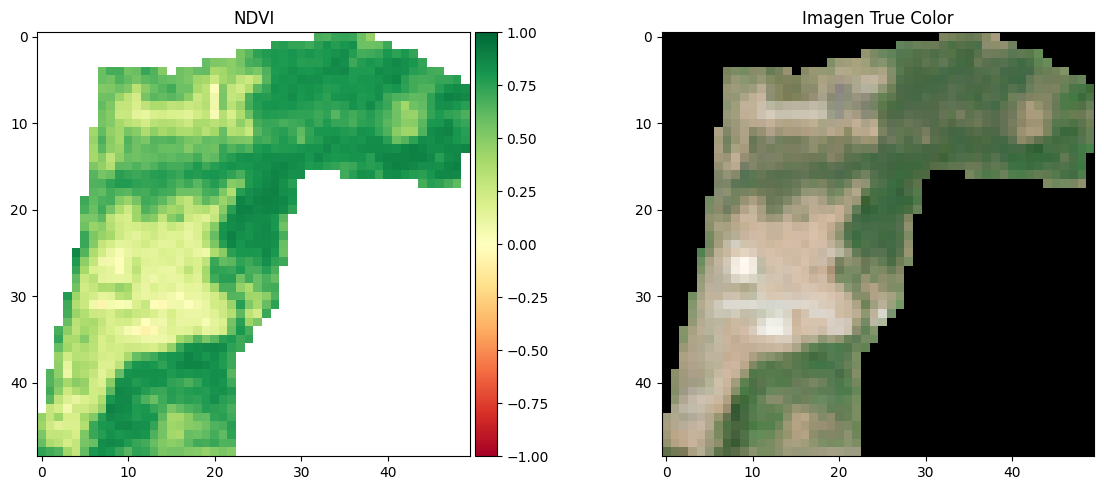

Ruta B4 t2 -> 2019/2019-12-30/2019-12-30-00_00_2019-12-30-23_59_Sentinel-2_L2A_B04_(Raw).tiff
Ruta B8 t2 -> 2019/2019-12-30/2019-12-30-00_00_2019-12-30-23_59_Sentinel-2_L2A_B08_(Raw).tiff


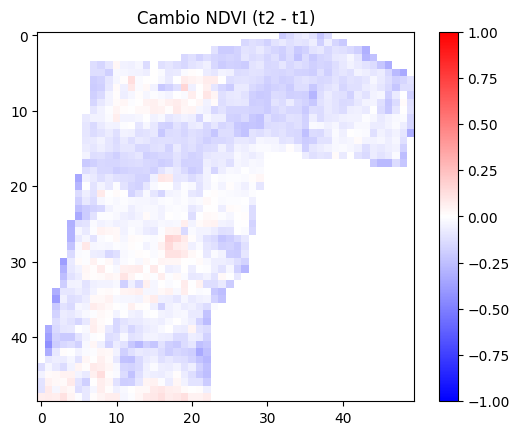

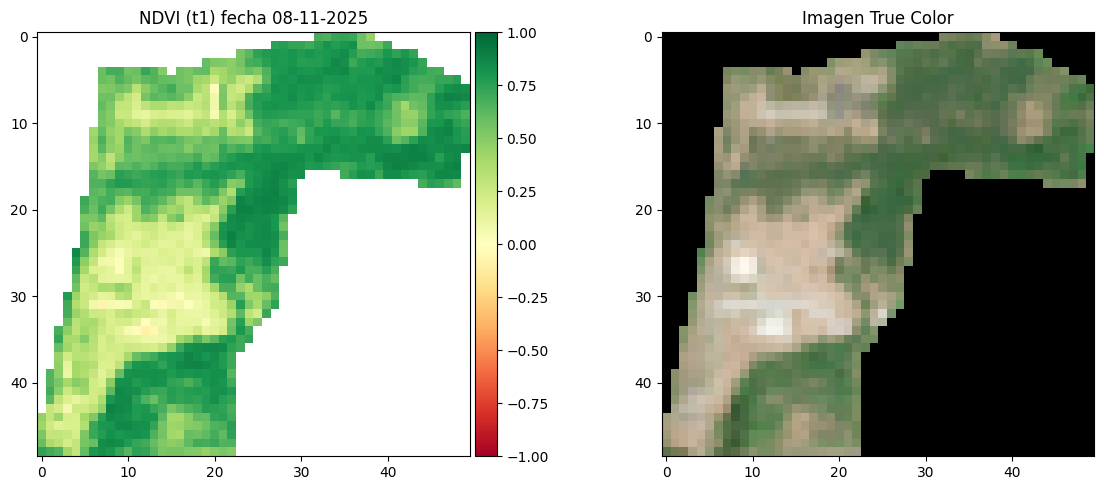

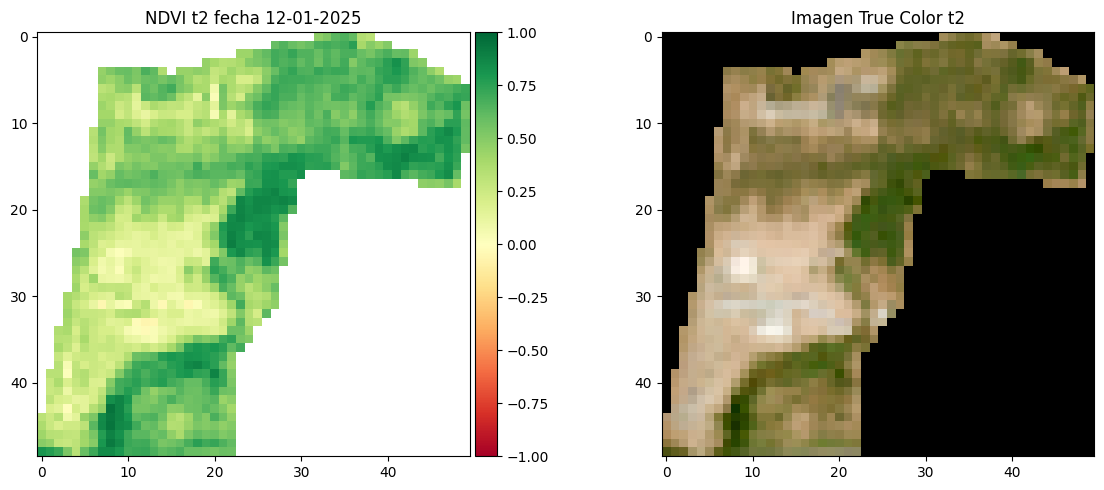

In [65]:

# Rutas de ejemplo: ajuste a su caso
PATH_B4 = '2019/2019-06-18/2019-06-18-00_00_2019-06-18-23_59_Sentinel-2_L2A_B04_(Raw).tiff'   # Banda roja
PATH_B8 = '2019/2019-06-18/2019-06-18-00_00_2019-06-18-23_59_Sentinel-2_L2A_B08_(Raw).tiff'   # Banda NIR
PATH_TRUE_COLOR = '2019/2019-06-18/2019-06-18-00_00_2019-06-18-23_59_Sentinel-2_L2A_True_color.tiff'

# Helper: buscar variantes de nombre/extension o en carpeta 'data2' antes de intentar abrir
def find_band_file(path_hint, keyword=None):
    if path_hint and os.path.exists(path_hint):
        return path_hint
    if path_hint:
        base = path_hint.rsplit('.', 1)[0]
        for ext in ('tif', 'tiff'):
            candidate = f'{base}.{ext}'
            if os.path.exists(candidate):
                return candidate
    folder = os.path.dirname(path_hint) if path_hint else 'data2'
    if not folder:
        folder = 'data2'
    if os.path.isdir(folder):
        for fn in os.listdir(folder):
            if (keyword is None or keyword in fn) and (fn.lower().endswith('.tif') or fn.lower().endswith('.tiff')):
                return os.path.join(folder, fn)
    return None

# Intentar resolver rutas antes de abrir para evitar RasterioIOError
PATH_B4 = find_band_file(PATH_B4, keyword='B04') or PATH_B4
PATH_B8 = find_band_file(PATH_B8, keyword='B08') or PATH_B8
PATH_TRUE_COLOR = find_band_file(PATH_TRUE_COLOR, keyword='True_color') or PATH_TRUE_COLOR

# Inicializar variables por si no podemos abrir los archivos
ds_b4 = ds_b8 = None
b4 = b8 = None

# Solo abrir si existe el archivo resuelto y capturar errores
if PATH_B4 and os.path.exists(PATH_B4):
    try:
        ds_b4, b4 = read_raster(PATH_B4)
    except Exception as e:
        print(f"Error al abrir PATH_B4 ({PATH_B4}):", e)
        ds_b4 = b4 = None
else:
    print(f"PATH_B4 no existe: {PATH_B4}")

if PATH_B8 and os.path.exists(PATH_B8):
    try:
        ds_b8, b8 = read_raster(PATH_B8)
    except Exception as e:
        print(f"Error al abrir PATH_B8 ({PATH_B8}):", e)
        ds_b8 = b8 = None
else:
    print(f"PATH_B8 no existe: {PATH_B8}")

# Si ambos bandas se cargaron correctamente, continuar
if ds_b4 is not None and ds_b8 is not None and b4 is not None and b8 is not None:
    # Si las dimensiones difieren, re-muestrear B4 a la malla de B8
    try:
        if (ds_b4.width != ds_b8.width) or (ds_b4.height != ds_b8.height) or (ds_b4.transform != ds_b8.transform):
            b4 = resample_to_match(ds_b4, b4, ds_b8)
    except Exception as e:
        print("Error al comparar/resamplear mallas:", e)

    print("B4 shape:", b4.shape, "B8 shape:", b8.shape)

    ndvi = compute_ndvi(b8, b4)
    if valid_mask is not None:
        ndvi = np.where(valid_mask, ndvi, np.nan)
    ndvi_min, ndvi_max = np.nanmin(ndvi), np.nanmax(ndvi)
    print(f"NDVI rango: min={ndvi_min:.3f}, max={ndvi_max:.3f}")
else:
    print("No se pudieron cargar B4 y/o B8 de la primera fecha. Se omite cálculo de NDVI (t1).")
    ndvi = None

ndvi_2019_1 = ndvi

from mpl_toolkits.axes_grid1 import make_axes_locatable

# Cargar imagen True Color solo si existe; si no, usar 'img' ya presente en el entorno o mostrar placeholder
img = None
try:
    if PATH_TRUE_COLOR and os.path.exists(PATH_TRUE_COLOR):
        _, img = read_raster_rgb(PATH_TRUE_COLOR)
    else:
        print(f"PATH_TRUE_COLOR no existe: {PATH_TRUE_COLOR}. Se usará 'img' existente en el entorno si hay.")
        img = globals().get('img', None)
except Exception as e:
    print("Error al cargar PATH_TRUE_COLOR:", e)
    img = globals().get('img', None)

# Evitar intentar plotear NDVI si no está disponible
if ndvi is None:
    print("NDVI no disponible — se omitirá la visualización inicial.")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    im1 = ax1.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    ax1.set_title('NDVI')
    divider1 = make_axes_locatable(ax1)
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im1, cax=cax1)

    if img is not None:
        ax2.imshow(img)
        ax2.set_title('Imagen True Color')
    else:
        ax2.text(0.5, 0.5, 'No True Color disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()


# Rutas de ejemplo para una segunda fecha (ajuste o deje en None)
PATH_B4_T2 = '2019/2019-12-30/2019-12-30-00_00_2019-12-30-23_59_Sentinel-2_L2A_B04_(Raw).tif'
PATH_B8_T2 = '2019/2019-12-30/2019-12-30-00_00_2019-12-30-23_59_Sentinel-2_L2A_B08_(Raw).tif'
# Asegurar extensión en la ruta True Color de la segunda fecha (evita error si falta la extensión)
PATH_TRUE_COLOR_T2 = '2019/2019-12-30/2019-12-30-00_00_2019-12-30-23_59_Sentinel-2_L2A_True_color.tiff'

have_t2 = False
ndvi_t2 = None
d_ndvi = None
img1 = None

# Resolver rutas (si las definidas no coinciden exactamente con archivos en disco)
PATH_B4_T2 = find_band_file(PATH_B4_T2, keyword='B04') or PATH_B4_T2
PATH_B8_T2 = find_band_file(PATH_B8_T2, keyword='B08') or PATH_B8_T2

print('Ruta B4 t2 ->', PATH_B4_T2)
print('Ruta B8 t2 ->', PATH_B8_T2)

# Verificar que las rutas estén definidas y que los archivos existan antes de abrirlos
if PATH_B4_T2 and PATH_B8_T2 and os.path.exists(PATH_B4_T2) and os.path.exists(PATH_B8_T2):
    try:
        ds_b4_t2, b4_t2 = read_raster(PATH_B4_T2)
        ds_b8_t2, b8_t2 = read_raster(PATH_B8_T2)
    except rasterio.errors.RasterioIOError as e:
        print("Error al abrir los archivos de la segunda fecha:", e)
    else:
        # Si no hay referencia de ds_b8 (t1) usar ds_b8_t2 como referencia para resamplear
        ref_ds = ds_b8 if (ds_b8 is not None) else ds_b8_t2
        try:
            if ds_b4_t2 is not None and ref_ds is not None and ((ds_b4_t2.width != ref_ds.width) or (ds_b4_t2.height != ref_ds.height) or (ds_b4_t2.transform != ref_ds.transform)):
                b4_t2 = resample_to_match(ds_b4_t2, b4_t2, ref_ds)
            if ds_b8_t2 is not None and ref_ds is not None and ((ds_b8_t2.width != ref_ds.width) or (ds_b8_t2.height != ref_ds.height) or (ds_b8_t2.transform != ref_ds.transform)):
                b8_t2 = resample_to_match(ds_b8_t2, b8_t2, ref_ds)
        except Exception as e:
            print("Error al re-muestrear bandas t2:", e)

        try:
            ndvi_t2 = compute_ndvi(b8_t2, b4_t2)
            if valid_mask is not None and ndvi_t2 is not None:
                ndvi_t2 = np.where(valid_mask, ndvi_t2, np.nan)
        except Exception as e:
            print("Error al calcular NDVI t2:", e)
            ndvi_t2 = None
        ndvi_2019_2 = ndvi_t2
        d_ndvi = None
        if (ndvi is not None) and (ndvi_t2 is not None):
            d_ndvi = ndvi_t2 - ndvi
        have_t2 = True if ndvi_t2 is not None else False
        # Guardar diferencia NDVI en variables solicitadas:
        df2019 = d_ndvi
        globals()['2019df'] = d_ndvi

        plt.figure()
        if d_ndvi is not None:
            plt.imshow(d_ndvi, cmap='bwr', vmin=-1, vmax=1)
            plt.title('Cambio NDVI (t2 - t1)')
            plt.colorbar()
        else:
            print('No se puede mostrar d_ndvi (falta ndvi o ndvi_t2).')
        plt.show()
else:
    print('Proporcione PATH_B4_T2 y PATH_B8_T2 válidos y existentes en disco para calcular el cambio de NDVI entre fechas.')

# Mostrar NDVI y True Color t1 (si existe)
from mpl_toolkits.axes_grid1 import make_axes_locatable

try:
    if PATH_TRUE_COLOR and os.path.exists(PATH_TRUE_COLOR):
        _, img = read_raster_rgb(PATH_TRUE_COLOR)
    # si PATH_TRUE_COLOR no existe, puede que 'img' ya esté definido en el entorno; si no, se mostrará un placeholder
except Exception as e:
    print("No se pudo cargar PATH_TRUE_COLOR:", e)
    img = globals().get('img', None)

if ndvi is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    im1 = ax1.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    ax1.set_title('NDVI (t1) fecha 08-11-2025')
    divider1 = make_axes_locatable(ax1)
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im1, cax=cax1)

    if img is not None:
        ax2.imshow(img)
        ax2.set_title('Imagen True Color')
    else:
        ax2.text(0.5, 0.5, 'No True Color disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()
else:
    print("NDVI (t1) no disponible para mostrar.")

# Cargar y mostrar True Color t2 (si existe)
if PATH_TRUE_COLOR_T2 and os.path.exists(PATH_TRUE_COLOR_T2):
    try:
        _, img1 = read_raster_rgb(PATH_TRUE_COLOR_T2)
    except Exception as e:
        print("No se pudo cargar PATH_TRUE_COLOR_T2:", e)
        img1 = None
else:
    print("PATH_TRUE_COLOR_T2 no existe o no está definido, se omitirá la visualización de t2.")

# Mostrar NDVI t2 y True Color t2 si están disponibles
if have_t2 or (img1 is not None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    if have_t2 and ndvi_t2 is not None:
        im1 = ax1.imshow(ndvi_t2, cmap='RdYlGn', vmin=-1, vmax=1)
        ax1.set_title('NDVI t2 fecha 12-01-2025')
        divider1 = make_axes_locatable(ax1)
        cax1 = divider1.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(im1, cax=cax1)
    else:
        ax1.text(0.5, 0.5, 'NDVI t2 no disponible', ha='center', va='center')
        ax1.set_axis_off()

    if img1 is not None:
        ax2.imshow(img1)
        ax2.set_title('Imagen True Color t2')
    else:
        ax2.text(0.5, 0.5, 'True Color t2 no disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()






2020

B4 shape: (49, 50) B8 shape: (49, 50)
NDVI rango: min=-0.076, max=0.857


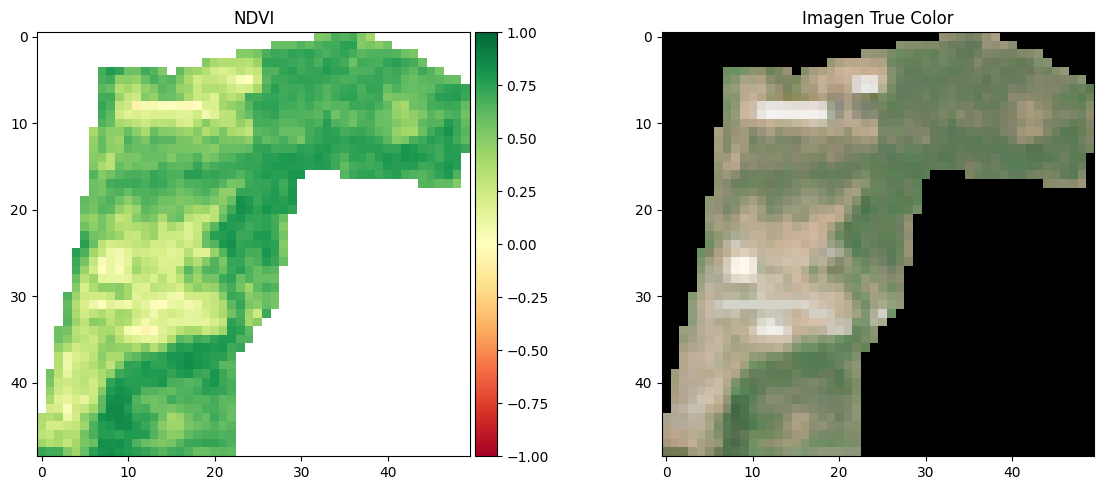

Ruta B4 t2 -> 2020/2020-12-14/2020-12-14-00_00_2020-12-14-23_59_Sentinel-2_L2A_B04_(Raw).tiff
Ruta B8 t2 -> 2020/2020-12-14/2020-12-14-00_00_2020-12-14-23_59_Sentinel-2_L2A_B08_(Raw).tiff


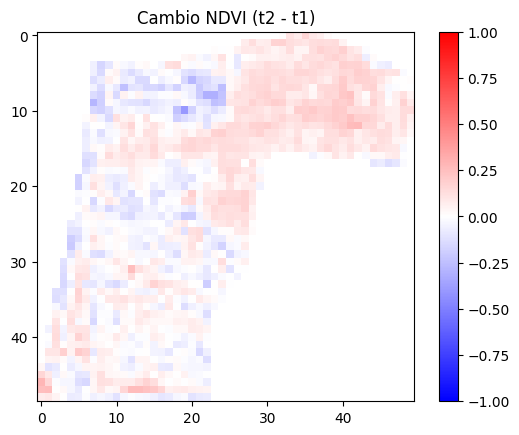

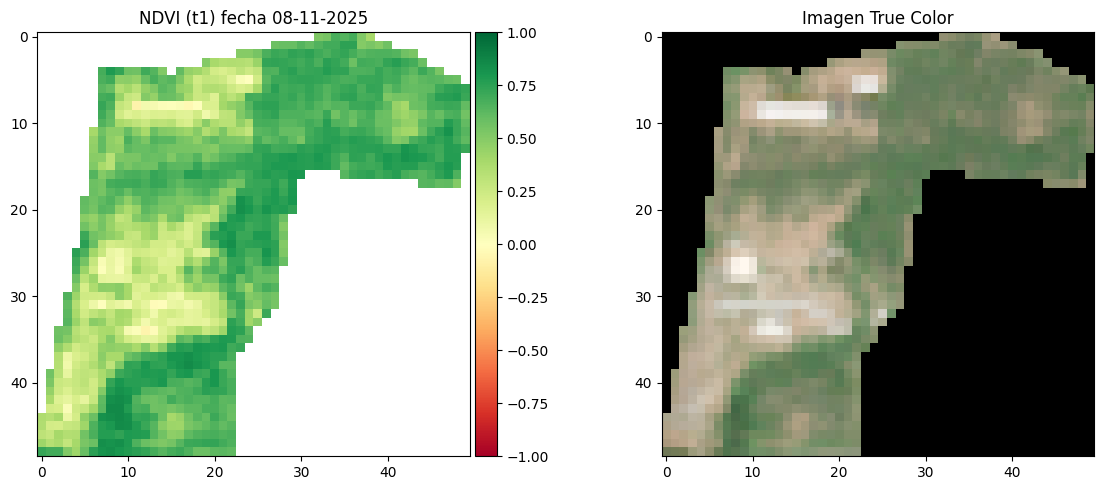

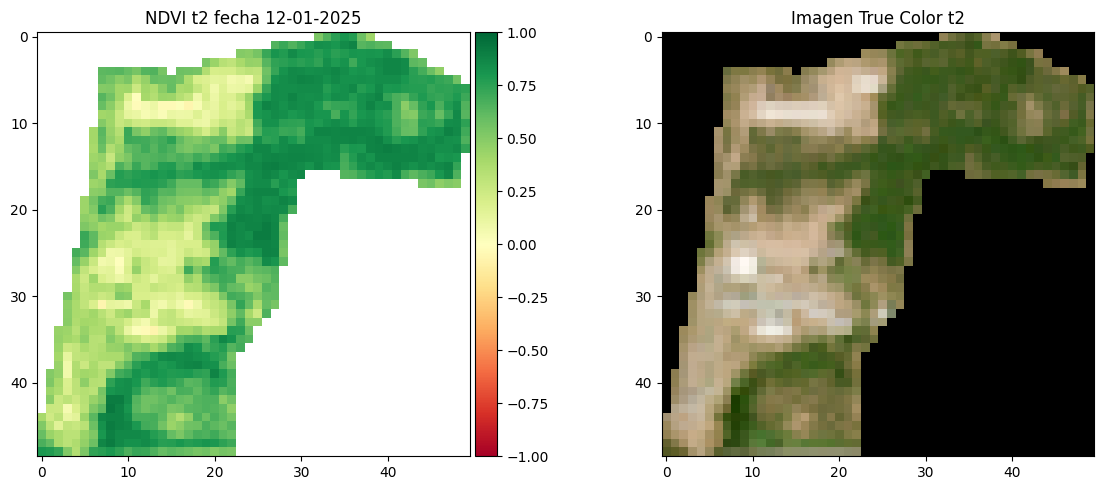

In [66]:

# Rutas de ejemplo: ajuste a su caso
PATH_B4 = '2020/2020-05-23/2020-05-23-00_00_2020-05-23-23_59_Sentinel-2_L2A_B04_(Raw).tiff'   # Banda roja
PATH_B8 = '2020/2020-05-23/2020-05-23-00_00_2020-05-23-23_59_Sentinel-2_L2A_B08_(Raw).tiff'   # Banda NIR
PATH_TRUE_COLOR = '2020/2020-05-23/2020-05-23-00_00_2020-05-23-23_59_Sentinel-2_L2A_True_color.tiff'

# Helper: buscar variantes de nombre/extension o en carpeta 'data2' antes de intentar abrir
def find_band_file(path_hint, keyword=None):
    if path_hint and os.path.exists(path_hint):
        return path_hint
    if path_hint:
        base = path_hint.rsplit('.', 1)[0]
        for ext in ('tif', 'tiff'):
            candidate = f'{base}.{ext}'
            if os.path.exists(candidate):
                return candidate
    folder = os.path.dirname(path_hint) if path_hint else 'data2'
    if not folder:
        folder = 'data2'
    if os.path.isdir(folder):
        for fn in os.listdir(folder):
            if (keyword is None or keyword in fn) and (fn.lower().endswith('.tif') or fn.lower().endswith('.tiff')):
                return os.path.join(folder, fn)
    return None

# Intentar resolver rutas antes de abrir para evitar RasterioIOError
PATH_B4 = find_band_file(PATH_B4, keyword='B04') or PATH_B4
PATH_B8 = find_band_file(PATH_B8, keyword='B08') or PATH_B8
PATH_TRUE_COLOR = find_band_file(PATH_TRUE_COLOR, keyword='True_color') or PATH_TRUE_COLOR

# Inicializar variables por si no podemos abrir los archivos
ds_b4 = ds_b8 = None
b4 = b8 = None

# Solo abrir si existe el archivo resuelto y capturar errores
if PATH_B4 and os.path.exists(PATH_B4):
    try:
        ds_b4, b4 = read_raster(PATH_B4)
    except Exception as e:
        print(f"Error al abrir PATH_B4 ({PATH_B4}):", e)
        ds_b4 = b4 = None
else:
    print(f"PATH_B4 no existe: {PATH_B4}")

if PATH_B8 and os.path.exists(PATH_B8):
    try:
        ds_b8, b8 = read_raster(PATH_B8)
    except Exception as e:
        print(f"Error al abrir PATH_B8 ({PATH_B8}):", e)
        ds_b8 = b8 = None
else:
    print(f"PATH_B8 no existe: {PATH_B8}")

# Si ambos bandas se cargaron correctamente, continuar
if ds_b4 is not None and ds_b8 is not None and b4 is not None and b8 is not None:
    # Si las dimensiones difieren, re-muestrear B4 a la malla de B8
    try:
        if (ds_b4.width != ds_b8.width) or (ds_b4.height != ds_b8.height) or (ds_b4.transform != ds_b8.transform):
            b4 = resample_to_match(ds_b4, b4, ds_b8)
    except Exception as e:
        print("Error al comparar/resamplear mallas:", e)

    print("B4 shape:", b4.shape, "B8 shape:", b8.shape)

    ndvi = compute_ndvi(b8, b4)
    if valid_mask is not None:
        ndvi = np.where(valid_mask, ndvi, np.nan)
    ndvi_min, ndvi_max = np.nanmin(ndvi), np.nanmax(ndvi)
    print(f"NDVI rango: min={ndvi_min:.3f}, max={ndvi_max:.3f}")
else:
    print("No se pudieron cargar B4 y/o B8 de la primera fecha. Se omite cálculo de NDVI (t1).")
    ndvi = None

ndvi_2020_1 = ndvi


from mpl_toolkits.axes_grid1 import make_axes_locatable

# Cargar imagen True Color solo si existe; si no, usar 'img' ya presente en el entorno o mostrar placeholder
img = None
try:
    if PATH_TRUE_COLOR and os.path.exists(PATH_TRUE_COLOR):
        _, img = read_raster_rgb(PATH_TRUE_COLOR)
    else:
        print(f"PATH_TRUE_COLOR no existe: {PATH_TRUE_COLOR}. Se usará 'img' existente en el entorno si hay.")
        img = globals().get('img', None)
except Exception as e:
    print("Error al cargar PATH_TRUE_COLOR:", e)
    img = globals().get('img', None)

# Evitar intentar plotear NDVI si no está disponible
if ndvi is None:
    print("NDVI no disponible — se omitirá la visualización inicial.")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    im1 = ax1.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    ax1.set_title('NDVI')
    divider1 = make_axes_locatable(ax1)
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im1, cax=cax1)

    if img is not None:
        ax2.imshow(img)
        ax2.set_title('Imagen True Color')
    else:
        ax2.text(0.5, 0.5, 'No True Color disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()


# Rutas de ejemplo para una segunda fecha (ajuste o deje en None)
PATH_B4_T2 = '2020/2020-12-14/2020-12-14-00_00_2020-12-14-23_59_Sentinel-2_L2A_B04_(Raw).tif'
PATH_B8_T2 = '2020/2020-12-14/2020-12-14-00_00_2020-12-14-23_59_Sentinel-2_L2A_B08_(Raw).tif'
# Asegurar extensión en la ruta True Color de la segunda fecha (evita error si falta la extensión)
PATH_TRUE_COLOR_T2 = '2020/2020-12-14/2020-12-14-00_00_2020-12-14-23_59_Sentinel-2_L2A_True_color.tiff'

have_t2 = False
ndvi_t2 = None
d_ndvi = None
img1 = None

# Resolver rutas (si las definidas no coinciden exactamente con archivos en disco)
PATH_B4_T2 = find_band_file(PATH_B4_T2, keyword='B04') or PATH_B4_T2
PATH_B8_T2 = find_band_file(PATH_B8_T2, keyword='B08') or PATH_B8_T2

print('Ruta B4 t2 ->', PATH_B4_T2)
print('Ruta B8 t2 ->', PATH_B8_T2)

# Verificar que las rutas estén definidas y que los archivos existan antes de abrirlos
if PATH_B4_T2 and PATH_B8_T2 and os.path.exists(PATH_B4_T2) and os.path.exists(PATH_B8_T2):
    try:
        ds_b4_t2, b4_t2 = read_raster(PATH_B4_T2)
        ds_b8_t2, b8_t2 = read_raster(PATH_B8_T2)
    except rasterio.errors.RasterioIOError as e:
        print("Error al abrir los archivos de la segunda fecha:", e)
    else:
        # Si no hay referencia de ds_b8 (t1) usar ds_b8_t2 como referencia para resamplear
        ref_ds = ds_b8 if (ds_b8 is not None) else ds_b8_t2
        try:
            if ds_b4_t2 is not None and ref_ds is not None and ((ds_b4_t2.width != ref_ds.width) or (ds_b4_t2.height != ref_ds.height) or (ds_b4_t2.transform != ref_ds.transform)):
                b4_t2 = resample_to_match(ds_b4_t2, b4_t2, ref_ds)
            if ds_b8_t2 is not None and ref_ds is not None and ((ds_b8_t2.width != ref_ds.width) or (ds_b8_t2.height != ref_ds.height) or (ds_b8_t2.transform != ref_ds.transform)):
                b8_t2 = resample_to_match(ds_b8_t2, b8_t2, ref_ds)
        except Exception as e:
            print("Error al re-muestrear bandas t2:", e)

        try:
            ndvi_t2 = compute_ndvi(b8_t2, b4_t2)
            if valid_mask is not None and ndvi_t2 is not None:
                ndvi_t2 = np.where(valid_mask, ndvi_t2, np.nan)
        except Exception as e:
            print("Error al calcular NDVI t2:", e)
            ndvi_t2 = None
        ndvi_2020_2 = ndvi_t2
        d_ndvi = None
        if (ndvi is not None) and (ndvi_t2 is not None):
            d_ndvi = ndvi_t2 - ndvi
        have_t2 = True if ndvi_t2 is not None else False
        # Guardar diferencia NDVI en variables solicitadas:
        df2020 = d_ndvi
        globals()['2020df'] = d_ndvi

        plt.figure()
        if d_ndvi is not None:
            plt.imshow(d_ndvi, cmap='bwr', vmin=-1, vmax=1)
            plt.title('Cambio NDVI (t2 - t1)')
            plt.colorbar()
        else:
            print('No se puede mostrar d_ndvi (falta ndvi o ndvi_t2).')
        plt.show()
else:
    print('Proporcione PATH_B4_T2 y PATH_B8_T2 válidos y existentes en disco para calcular el cambio de NDVI entre fechas.')

# Mostrar NDVI y True Color t1 (si existe)
from mpl_toolkits.axes_grid1 import make_axes_locatable

try:
    if PATH_TRUE_COLOR and os.path.exists(PATH_TRUE_COLOR):
        _, img = read_raster_rgb(PATH_TRUE_COLOR)
    # si PATH_TRUE_COLOR no existe, puede que 'img' ya esté definido en el entorno; si no, se mostrará un placeholder
except Exception as e:
    print("No se pudo cargar PATH_TRUE_COLOR:", e)
    img = globals().get('img', None)

if ndvi is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    im1 = ax1.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    ax1.set_title('NDVI (t1) fecha 08-11-2025')
    divider1 = make_axes_locatable(ax1)
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im1, cax=cax1)

    if img is not None:
        ax2.imshow(img)
        ax2.set_title('Imagen True Color')
    else:
        ax2.text(0.5, 0.5, 'No True Color disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()
else:
    print("NDVI (t1) no disponible para mostrar.")

# Cargar y mostrar True Color t2 (si existe)
if PATH_TRUE_COLOR_T2 and os.path.exists(PATH_TRUE_COLOR_T2):
    try:
        _, img1 = read_raster_rgb(PATH_TRUE_COLOR_T2)
    except Exception as e:
        print("No se pudo cargar PATH_TRUE_COLOR_T2:", e)
        img1 = None
else:
    print("PATH_TRUE_COLOR_T2 no existe o no está definido, se omitirá la visualización de t2.")

# Mostrar NDVI t2 y True Color t2 si están disponibles
if have_t2 or (img1 is not None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    if have_t2 and ndvi_t2 is not None:
        im1 = ax1.imshow(ndvi_t2, cmap='RdYlGn', vmin=-1, vmax=1)
        ax1.set_title('NDVI t2 fecha 12-01-2025')
        divider1 = make_axes_locatable(ax1)
        cax1 = divider1.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(im1, cax=cax1)
    else:
        ax1.text(0.5, 0.5, 'NDVI t2 no disponible', ha='center', va='center')
        ax1.set_axis_off()

    if img1 is not None:
        ax2.imshow(img1)
        ax2.set_title('Imagen True Color t2')
    else:
        ax2.text(0.5, 0.5, 'True Color t2 no disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()






2021

B4 shape: (49, 50) B8 shape: (49, 50)
NDVI rango: min=-0.100, max=0.879


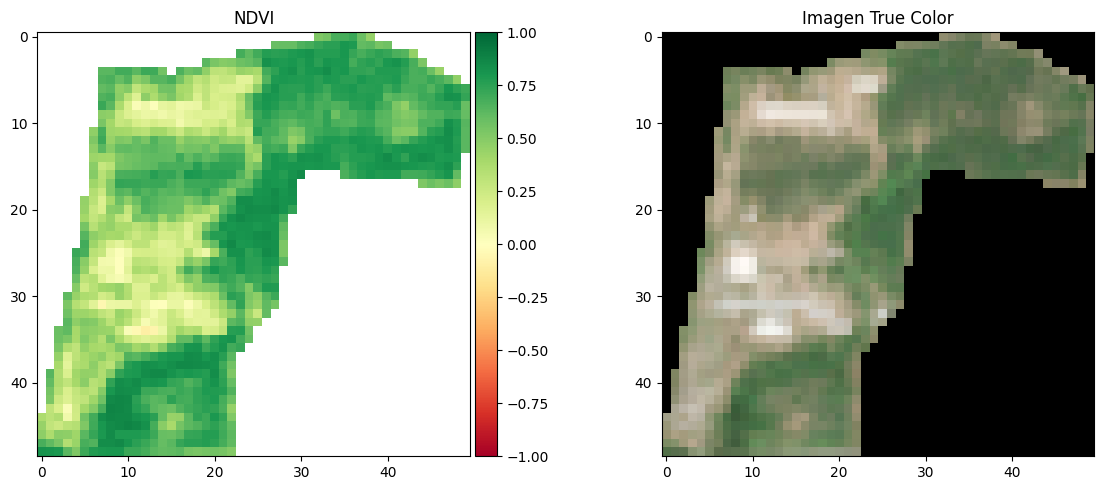

Ruta B4 t2 -> 2021/2021-12-14/2021-12-14-00_00_2021-12-14-23_59_Sentinel-2_L2A_B04_(Raw).tiff
Ruta B8 t2 -> 2021/2021-12-14/2021-12-14-00_00_2021-12-14-23_59_Sentinel-2_L2A_B08_(Raw).tiff


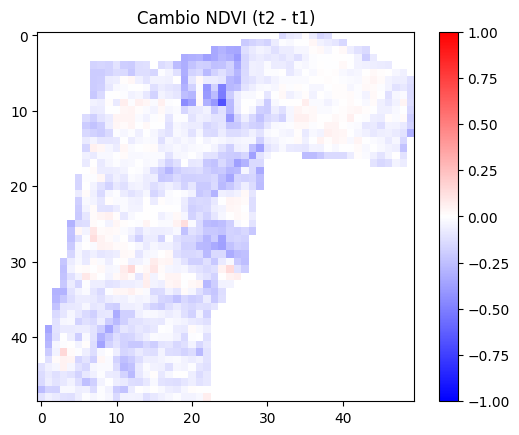

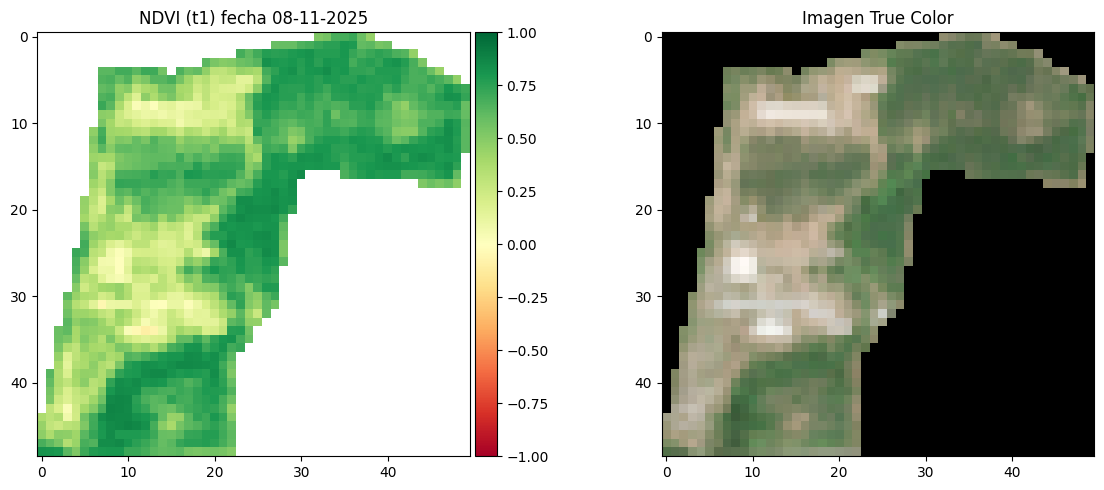

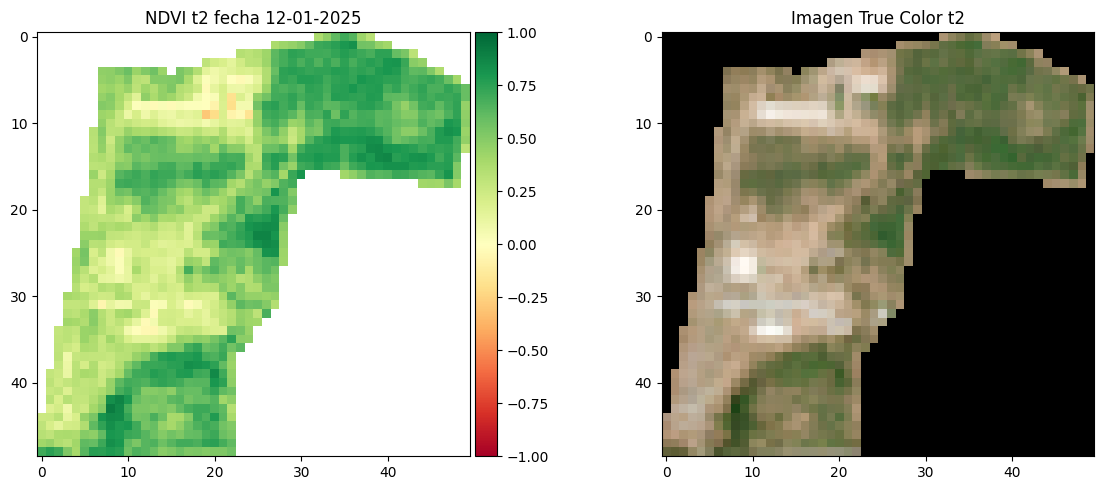

In [67]:

# Rutas de ejemplo: ajuste a su caso
PATH_B4 = '2021/2021-06-27/2021-06-27-00_00_2021-06-27-23_59_Sentinel-2_L2A_B04_(Raw).tiff'   # Banda roja
PATH_B8 = '2021/2021-06-27/2021-06-27-00_00_2021-06-27-23_59_Sentinel-2_L2A_B08_(Raw).tiff'   # Banda NIR
PATH_TRUE_COLOR = '2021/2021-06-27/2021-06-27-00_00_2021-06-27-23_59_Sentinel-2_L2A_True_color.tiff'

# Helper: buscar variantes de nombre/extension o en carpeta 'data2' antes de intentar abrir
def find_band_file(path_hint, keyword=None):
    if path_hint and os.path.exists(path_hint):
        return path_hint
    if path_hint:
        base = path_hint.rsplit('.', 1)[0]
        for ext in ('tif', 'tiff'):
            candidate = f'{base}.{ext}'
            if os.path.exists(candidate):
                return candidate
    folder = os.path.dirname(path_hint) if path_hint else 'data2'
    if not folder:
        folder = 'data2'
    if os.path.isdir(folder):
        for fn in os.listdir(folder):
            if (keyword is None or keyword in fn) and (fn.lower().endswith('.tif') or fn.lower().endswith('.tiff')):
                return os.path.join(folder, fn)
    return None

# Intentar resolver rutas antes de abrir para evitar RasterioIOError
PATH_B4 = find_band_file(PATH_B4, keyword='B04') or PATH_B4
PATH_B8 = find_band_file(PATH_B8, keyword='B08') or PATH_B8
PATH_TRUE_COLOR = find_band_file(PATH_TRUE_COLOR, keyword='True_color') or PATH_TRUE_COLOR

# Inicializar variables por si no podemos abrir los archivos
ds_b4 = ds_b8 = None
b4 = b8 = None

# Solo abrir si existe el archivo resuelto y capturar errores
if PATH_B4 and os.path.exists(PATH_B4):
    try:
        ds_b4, b4 = read_raster(PATH_B4)
    except Exception as e:
        print(f"Error al abrir PATH_B4 ({PATH_B4}):", e)
        ds_b4 = b4 = None
else:
    print(f"PATH_B4 no existe: {PATH_B4}")

if PATH_B8 and os.path.exists(PATH_B8):
    try:
        ds_b8, b8 = read_raster(PATH_B8)
    except Exception as e:
        print(f"Error al abrir PATH_B8 ({PATH_B8}):", e)
        ds_b8 = b8 = None
else:
    print(f"PATH_B8 no existe: {PATH_B8}")

# Si ambos bandas se cargaron correctamente, continuar
if ds_b4 is not None and ds_b8 is not None and b4 is not None and b8 is not None:
    # Si las dimensiones difieren, re-muestrear B4 a la malla de B8
    try:
        if (ds_b4.width != ds_b8.width) or (ds_b4.height != ds_b8.height) or (ds_b4.transform != ds_b8.transform):
            b4 = resample_to_match(ds_b4, b4, ds_b8)
    except Exception as e:
        print("Error al comparar/resamplear mallas:", e)

    print("B4 shape:", b4.shape, "B8 shape:", b8.shape)

    ndvi = compute_ndvi(b8, b4)
    if valid_mask is not None:
        ndvi = np.where(valid_mask, ndvi, np.nan)
    ndvi_min, ndvi_max = np.nanmin(ndvi), np.nanmax(ndvi)
    print(f"NDVI rango: min={ndvi_min:.3f}, max={ndvi_max:.3f}")
else:
    print("No se pudieron cargar B4 y/o B8 de la primera fecha. Se omite cálculo de NDVI (t1).")
    ndvi = None

ndvi_2021_1 = ndvi

from mpl_toolkits.axes_grid1 import make_axes_locatable

# Cargar imagen True Color solo si existe; si no, usar 'img' ya presente en el entorno o mostrar placeholder
img = None
try:
    if PATH_TRUE_COLOR and os.path.exists(PATH_TRUE_COLOR):
        _, img = read_raster_rgb(PATH_TRUE_COLOR)
    else:
        print(f"PATH_TRUE_COLOR no existe: {PATH_TRUE_COLOR}. Se usará 'img' existente en el entorno si hay.")
        img = globals().get('img', None)
except Exception as e:
    print("Error al cargar PATH_TRUE_COLOR:", e)
    img = globals().get('img', None)

# Evitar intentar plotear NDVI si no está disponible
if ndvi is None:
    print("NDVI no disponible — se omitirá la visualización inicial.")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    im1 = ax1.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    ax1.set_title('NDVI')
    divider1 = make_axes_locatable(ax1)
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im1, cax=cax1)

    if img is not None:
        ax2.imshow(img)
        ax2.set_title('Imagen True Color')
    else:
        ax2.text(0.5, 0.5, 'No True Color disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()


# Rutas de ejemplo para una segunda fecha (ajuste o deje en None)
PATH_B4_T2 = '2021/2021-12-14/2021-12-14-00_00_2021-12-14-23_59_Sentinel-2_L2A_B04_(Raw).tif'
PATH_B8_T2 = '2021/2021-12-14/2021-12-14-00_00_2021-12-14-23_59_Sentinel-2_L2A_B08_(Raw).tif'
# Asegurar extensión en la ruta True Color de la segunda fecha (evita error si falta la extensión)
PATH_TRUE_COLOR_T2 = '2021/2021-12-14/2021-12-14-00_00_2021-12-14-23_59_Sentinel-2_L2A_True_color.tiff'

have_t2 = False
ndvi_t2 = None
d_ndvi = None
img1 = None

# Resolver rutas (si las definidas no coinciden exactamente con archivos en disco)
PATH_B4_T2 = find_band_file(PATH_B4_T2, keyword='B04') or PATH_B4_T2
PATH_B8_T2 = find_band_file(PATH_B8_T2, keyword='B08') or PATH_B8_T2

print('Ruta B4 t2 ->', PATH_B4_T2)
print('Ruta B8 t2 ->', PATH_B8_T2)

# Verificar que las rutas estén definidas y que los archivos existan antes de abrirlos
if PATH_B4_T2 and PATH_B8_T2 and os.path.exists(PATH_B4_T2) and os.path.exists(PATH_B8_T2):
    try:
        ds_b4_t2, b4_t2 = read_raster(PATH_B4_T2)
        ds_b8_t2, b8_t2 = read_raster(PATH_B8_T2)
    except rasterio.errors.RasterioIOError as e:
        print("Error al abrir los archivos de la segunda fecha:", e)
    else:
        # Si no hay referencia de ds_b8 (t1) usar ds_b8_t2 como referencia para resamplear
        ref_ds = ds_b8 if (ds_b8 is not None) else ds_b8_t2
        try:
            if ds_b4_t2 is not None and ref_ds is not None and ((ds_b4_t2.width != ref_ds.width) or (ds_b4_t2.height != ref_ds.height) or (ds_b4_t2.transform != ref_ds.transform)):
                b4_t2 = resample_to_match(ds_b4_t2, b4_t2, ref_ds)
            if ds_b8_t2 is not None and ref_ds is not None and ((ds_b8_t2.width != ref_ds.width) or (ds_b8_t2.height != ref_ds.height) or (ds_b8_t2.transform != ref_ds.transform)):
                b8_t2 = resample_to_match(ds_b8_t2, b8_t2, ref_ds)
        except Exception as e:
            print("Error al re-muestrear bandas t2:", e)

        try:
            ndvi_t2 = compute_ndvi(b8_t2, b4_t2)
            if valid_mask is not None and ndvi_t2 is not None:
                ndvi_t2 = np.where(valid_mask, ndvi_t2, np.nan)
        except Exception as e:
            print("Error al calcular NDVI t2:", e)
            ndvi_t2 = None
        ndvi_2021_2 = ndvi_t2
        d_ndvi = None
        if (ndvi is not None) and (ndvi_t2 is not None):
            d_ndvi = ndvi_t2 - ndvi
        have_t2 = True if ndvi_t2 is not None else False
        # Guardar diferencia NDVI en variables solicitadas:
        df2021 = d_ndvi
        globals()['2021df'] = d_ndvi

        plt.figure()
        if d_ndvi is not None:
            plt.imshow(d_ndvi, cmap='bwr', vmin=-1, vmax=1)
            plt.title('Cambio NDVI (t2 - t1)')
            plt.colorbar()
        else:
            print('No se puede mostrar d_ndvi (falta ndvi o ndvi_t2).')
        plt.show()
else:
    print('Proporcione PATH_B4_T2 y PATH_B8_T2 válidos y existentes en disco para calcular el cambio de NDVI entre fechas.')

# Mostrar NDVI y True Color t1 (si existe)
from mpl_toolkits.axes_grid1 import make_axes_locatable

try:
    if PATH_TRUE_COLOR and os.path.exists(PATH_TRUE_COLOR):
        _, img = read_raster_rgb(PATH_TRUE_COLOR)
    # si PATH_TRUE_COLOR no existe, puede que 'img' ya esté definido en el entorno; si no, se mostrará un placeholder
except Exception as e:
    print("No se pudo cargar PATH_TRUE_COLOR:", e)
    img = globals().get('img', None)

if ndvi is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    im1 = ax1.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    ax1.set_title('NDVI (t1) fecha 08-11-2025')
    divider1 = make_axes_locatable(ax1)
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im1, cax=cax1)

    if img is not None:
        ax2.imshow(img)
        ax2.set_title('Imagen True Color')
    else:
        ax2.text(0.5, 0.5, 'No True Color disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()
else:
    print("NDVI (t1) no disponible para mostrar.")

# Cargar y mostrar True Color t2 (si existe)
if PATH_TRUE_COLOR_T2 and os.path.exists(PATH_TRUE_COLOR_T2):
    try:
        _, img1 = read_raster_rgb(PATH_TRUE_COLOR_T2)
    except Exception as e:
        print("No se pudo cargar PATH_TRUE_COLOR_T2:", e)
        img1 = None
else:
    print("PATH_TRUE_COLOR_T2 no existe o no está definido, se omitirá la visualización de t2.")

# Mostrar NDVI t2 y True Color t2 si están disponibles
if have_t2 or (img1 is not None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    if have_t2 and ndvi_t2 is not None:
        im1 = ax1.imshow(ndvi_t2, cmap='RdYlGn', vmin=-1, vmax=1)
        ax1.set_title('NDVI t2 fecha 12-01-2025')
        divider1 = make_axes_locatable(ax1)
        cax1 = divider1.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(im1, cax=cax1)
    else:
        ax1.text(0.5, 0.5, 'NDVI t2 no disponible', ha='center', va='center')
        ax1.set_axis_off()

    if img1 is not None:
        ax2.imshow(img1)
        ax2.set_title('Imagen True Color t2')
    else:
        ax2.text(0.5, 0.5, 'True Color t2 no disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()






2022

B4 shape: (49, 50) B8 shape: (49, 50)
NDVI rango: min=-0.133, max=0.867


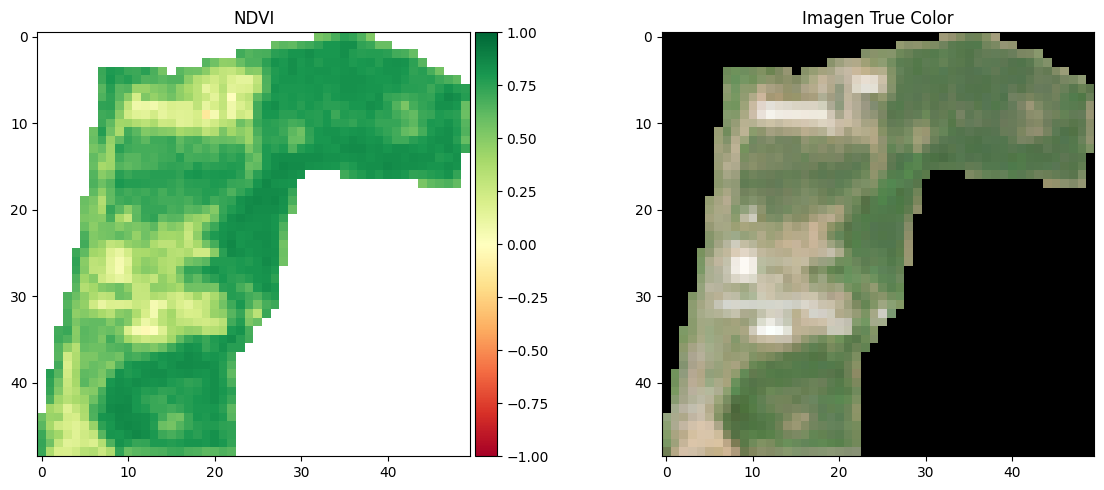

Ruta B4 t2 -> 2022/2022-12-09/2022-12-09-00_00_2022-12-09-23_59_Sentinel-2_L2A_B04_(Raw).tiff
Ruta B8 t2 -> 2022/2022-12-09/2022-12-09-00_00_2022-12-09-23_59_Sentinel-2_L2A_B08_(Raw).tiff


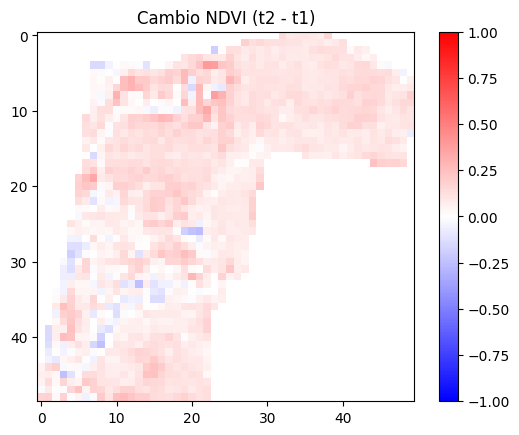

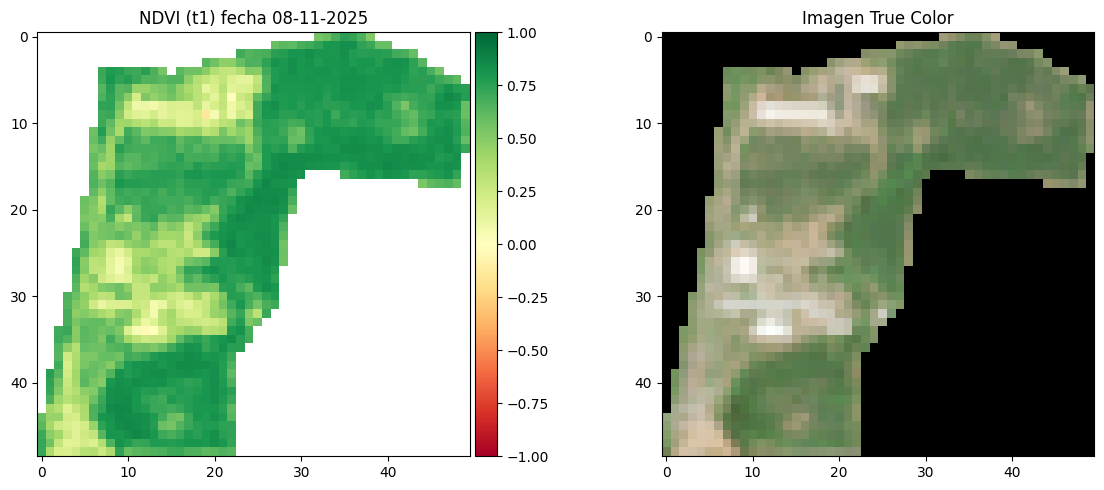

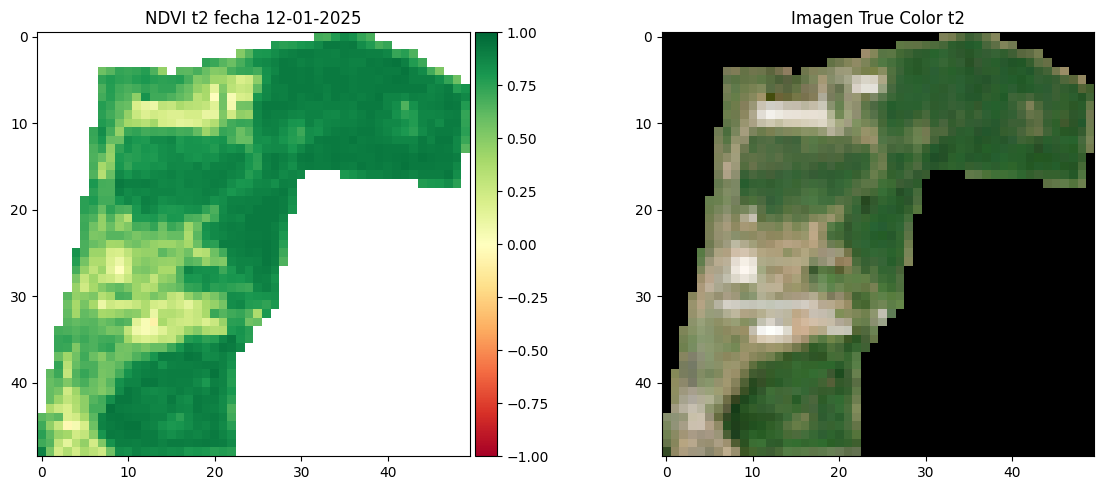

In [68]:

# Rutas de ejemplo: ajuste a su caso
PATH_B4 = '2022/2022-05-23/2022-05-23-00_00_2020-05-23-23_59_Sentinel-2_L2A_B04_(Raw).tiff'   # Banda roja
PATH_B8 = '2022/2022-05-23/2022-05-23-00_00_2020-05-23-23_59_Sentinel-2_L2A_B08_(Raw).tiff'   # Banda NIR
PATH_TRUE_COLOR = '2022/2022-05-23/2022-05-23-00_00_2020-05-23-23_59_Sentinel-2_L2A_True_color.tiff'

# Helper: buscar variantes de nombre/extension o en carpeta 'data2' antes de intentar abrir
def find_band_file(path_hint, keyword=None):
    if path_hint and os.path.exists(path_hint):
        return path_hint
    if path_hint:
        base = path_hint.rsplit('.', 1)[0]
        for ext in ('tif', 'tiff'):
            candidate = f'{base}.{ext}'
            if os.path.exists(candidate):
                return candidate
    folder = os.path.dirname(path_hint) if path_hint else 'data2'
    if not folder:
        folder = 'data2'
    if os.path.isdir(folder):
        for fn in os.listdir(folder):
            if (keyword is None or keyword in fn) and (fn.lower().endswith('.tif') or fn.lower().endswith('.tiff')):
                return os.path.join(folder, fn)
    return None

# Intentar resolver rutas antes de abrir para evitar RasterioIOError
PATH_B4 = find_band_file(PATH_B4, keyword='B04') or PATH_B4
PATH_B8 = find_band_file(PATH_B8, keyword='B08') or PATH_B8
PATH_TRUE_COLOR = find_band_file(PATH_TRUE_COLOR, keyword='True_color') or PATH_TRUE_COLOR

# Inicializar variables por si no podemos abrir los archivos
ds_b4 = ds_b8 = None
b4 = b8 = None

# Solo abrir si existe el archivo resuelto y capturar errores
if PATH_B4 and os.path.exists(PATH_B4):
    try:
        ds_b4, b4 = read_raster(PATH_B4)
    except Exception as e:
        print(f"Error al abrir PATH_B4 ({PATH_B4}):", e)
        ds_b4 = b4 = None
else:
    print(f"PATH_B4 no existe: {PATH_B4}")

if PATH_B8 and os.path.exists(PATH_B8):
    try:
        ds_b8, b8 = read_raster(PATH_B8)
    except Exception as e:
        print(f"Error al abrir PATH_B8 ({PATH_B8}):", e)
        ds_b8 = b8 = None
else:
    print(f"PATH_B8 no existe: {PATH_B8}")

# Si ambos bandas se cargaron correctamente, continuar
if ds_b4 is not None and ds_b8 is not None and b4 is not None and b8 is not None:
    # Si las dimensiones difieren, re-muestrear B4 a la malla de B8
    try:
        if (ds_b4.width != ds_b8.width) or (ds_b4.height != ds_b8.height) or (ds_b4.transform != ds_b8.transform):
            b4 = resample_to_match(ds_b4, b4, ds_b8)
    except Exception as e:
        print("Error al comparar/resamplear mallas:", e)

    print("B4 shape:", b4.shape, "B8 shape:", b8.shape)

    ndvi = compute_ndvi(b8, b4)
    if valid_mask is not None:
        ndvi = np.where(valid_mask, ndvi, np.nan)
    ndvi_min, ndvi_max = np.nanmin(ndvi), np.nanmax(ndvi)
    print(f"NDVI rango: min={ndvi_min:.3f}, max={ndvi_max:.3f}")
else:
    print("No se pudieron cargar B4 y/o B8 de la primera fecha. Se omite cálculo de NDVI (t1).")
    ndvi = None
ndvi_2022_1 = ndvi


from mpl_toolkits.axes_grid1 import make_axes_locatable

# Cargar imagen True Color solo si existe; si no, usar 'img' ya presente en el entorno o mostrar placeholder
img = None
try:
    if PATH_TRUE_COLOR and os.path.exists(PATH_TRUE_COLOR):
        _, img = read_raster_rgb(PATH_TRUE_COLOR)
    else:
        print(f"PATH_TRUE_COLOR no existe: {PATH_TRUE_COLOR}. Se usará 'img' existente en el entorno si hay.")
        img = globals().get('img', None)
except Exception as e:
    print("Error al cargar PATH_TRUE_COLOR:", e)
    img = globals().get('img', None)

# Evitar intentar plotear NDVI si no está disponible
if ndvi is None:
    print("NDVI no disponible — se omitirá la visualización inicial.")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    im1 = ax1.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    ax1.set_title('NDVI')
    divider1 = make_axes_locatable(ax1)
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im1, cax=cax1)

    if img is not None:
        ax2.imshow(img)
        ax2.set_title('Imagen True Color')
    else:
        ax2.text(0.5, 0.5, 'No True Color disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()


# Rutas de ejemplo para una segunda fecha (ajuste o deje en None)
PATH_B4_T2 = '2022/2022-12-09/2022-12-09-00_00_2022-12-09-23_59_Sentinel-2_L2A_B04_(Raw).tif'
PATH_B8_T2 = '2022/2022-12-09/2022-12-09-00_00_2022-12-09-23_59_Sentinel-2_L2A_B08_(Raw).tif'
# Asegurar extensión en la ruta True Color de la segunda fecha (evita error si falta la extensión)
PATH_TRUE_COLOR_T2 = '2022/2022-12-09/2022-12-09-00_00_2022-12-09-23_59_Sentinel-2_L2A_True_color.tiff'

have_t2 = False
ndvi_t2 = None
d_ndvi = None
img1 = None

# Resolver rutas (si las definidas no coinciden exactamente con archivos en disco)
PATH_B4_T2 = find_band_file(PATH_B4_T2, keyword='B04') or PATH_B4_T2
PATH_B8_T2 = find_band_file(PATH_B8_T2, keyword='B08') or PATH_B8_T2

print('Ruta B4 t2 ->', PATH_B4_T2)
print('Ruta B8 t2 ->', PATH_B8_T2)

# Verificar que las rutas estén definidas y que los archivos existan antes de abrirlos
if PATH_B4_T2 and PATH_B8_T2 and os.path.exists(PATH_B4_T2) and os.path.exists(PATH_B8_T2):
    try:
        ds_b4_t2, b4_t2 = read_raster(PATH_B4_T2)
        ds_b8_t2, b8_t2 = read_raster(PATH_B8_T2)
    except rasterio.errors.RasterioIOError as e:
        print("Error al abrir los archivos de la segunda fecha:", e)
    else:
        # Si no hay referencia de ds_b8 (t1) usar ds_b8_t2 como referencia para resamplear
        ref_ds = ds_b8 if (ds_b8 is not None) else ds_b8_t2
        try:
            if ds_b4_t2 is not None and ref_ds is not None and ((ds_b4_t2.width != ref_ds.width) or (ds_b4_t2.height != ref_ds.height) or (ds_b4_t2.transform != ref_ds.transform)):
                b4_t2 = resample_to_match(ds_b4_t2, b4_t2, ref_ds)
            if ds_b8_t2 is not None and ref_ds is not None and ((ds_b8_t2.width != ref_ds.width) or (ds_b8_t2.height != ref_ds.height) or (ds_b8_t2.transform != ref_ds.transform)):
                b8_t2 = resample_to_match(ds_b8_t2, b8_t2, ref_ds)
        except Exception as e:
            print("Error al re-muestrear bandas t2:", e)

        try:
            ndvi_t2 = compute_ndvi(b8_t2, b4_t2)
            if valid_mask is not None and ndvi_t2 is not None:
                ndvi_t2 = np.where(valid_mask, ndvi_t2, np.nan)
        except Exception as e:
            print("Error al calcular NDVI t2:", e)
            ndvi_t2 = None
        ndvi_2022_2 = ndvi_t2
        d_ndvi = None
        if (ndvi is not None) and (ndvi_t2 is not None):
            d_ndvi = ndvi_t2 - ndvi
        have_t2 = True if ndvi_t2 is not None else False
        # Guardar diferencia NDVI en variables solicitadas:
        df2022 = d_ndvi
        globals()['2022df'] = d_ndvi

        plt.figure()
        if d_ndvi is not None:
            plt.imshow(d_ndvi, cmap='bwr', vmin=-1, vmax=1)
            plt.title('Cambio NDVI (t2 - t1)')
            plt.colorbar()
        else:
            print('No se puede mostrar d_ndvi (falta ndvi o ndvi_t2).')
        plt.show()
else:
    print('Proporcione PATH_B4_T2 y PATH_B8_T2 válidos y existentes en disco para calcular el cambio de NDVI entre fechas.')

# Mostrar NDVI y True Color t1 (si existe)
from mpl_toolkits.axes_grid1 import make_axes_locatable

try:
    if PATH_TRUE_COLOR and os.path.exists(PATH_TRUE_COLOR):
        _, img = read_raster_rgb(PATH_TRUE_COLOR)
    # si PATH_TRUE_COLOR no existe, puede que 'img' ya esté definido en el entorno; si no, se mostrará un placeholder
except Exception as e:
    print("No se pudo cargar PATH_TRUE_COLOR:", e)
    img = globals().get('img', None)

if ndvi is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    im1 = ax1.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    ax1.set_title('NDVI (t1) fecha 08-11-2025')
    divider1 = make_axes_locatable(ax1)
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im1, cax=cax1)

    if img is not None:
        ax2.imshow(img)
        ax2.set_title('Imagen True Color')
    else:
        ax2.text(0.5, 0.5, 'No True Color disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()
else:
    print("NDVI (t1) no disponible para mostrar.")

# Cargar y mostrar True Color t2 (si existe)
if PATH_TRUE_COLOR_T2 and os.path.exists(PATH_TRUE_COLOR_T2):
    try:
        _, img1 = read_raster_rgb(PATH_TRUE_COLOR_T2)
    except Exception as e:
        print("No se pudo cargar PATH_TRUE_COLOR_T2:", e)
        img1 = None
else:
    print("PATH_TRUE_COLOR_T2 no existe o no está definido, se omitirá la visualización de t2.")

# Mostrar NDVI t2 y True Color t2 si están disponibles
if have_t2 or (img1 is not None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    if have_t2 and ndvi_t2 is not None:
        im1 = ax1.imshow(ndvi_t2, cmap='RdYlGn', vmin=-1, vmax=1)
        ax1.set_title('NDVI t2 fecha 12-01-2025')
        divider1 = make_axes_locatable(ax1)
        cax1 = divider1.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(im1, cax=cax1)
    else:
        ax1.text(0.5, 0.5, 'NDVI t2 no disponible', ha='center', va='center')
        ax1.set_axis_off()

    if img1 is not None:
        ax2.imshow(img1)
        ax2.set_title('Imagen True Color t2')
    else:
        ax2.text(0.5, 0.5, 'True Color t2 no disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()






2023

B4 shape: (49, 50) B8 shape: (49, 50)
NDVI rango: min=-0.076, max=0.936


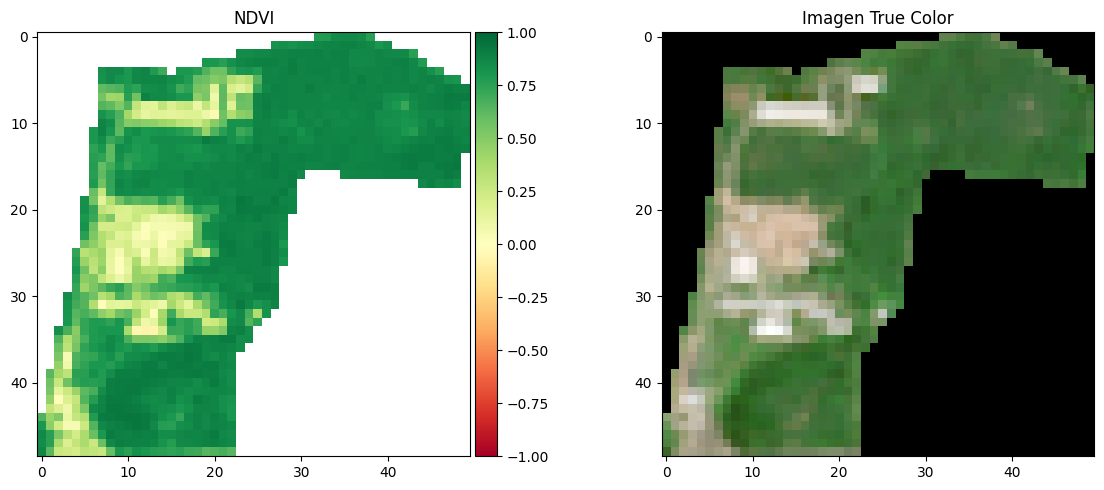

Ruta B4 t2 -> 2023/2023-12-09/2023-12-09-00_00_2023-12-09-23_59_Sentinel-2_L2A_B04_(Raw).tiff
Ruta B8 t2 -> 2023/2023-12-09/2023-12-09-00_00_2023-12-09-23_59_Sentinel-2_L2A_B08_(Raw).tiff


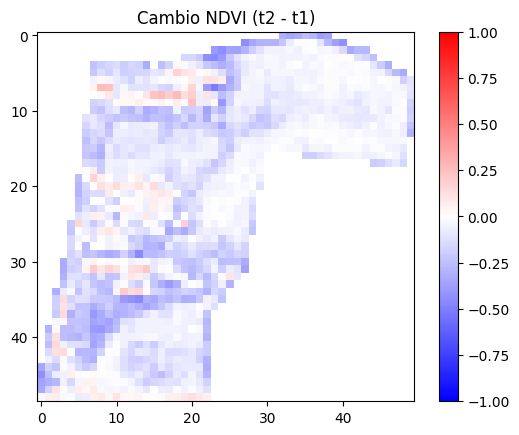

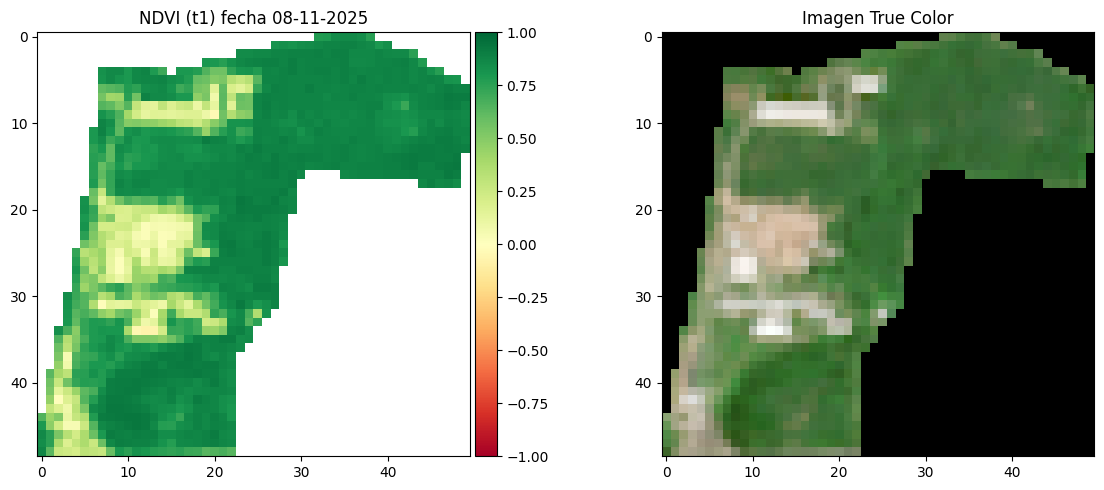

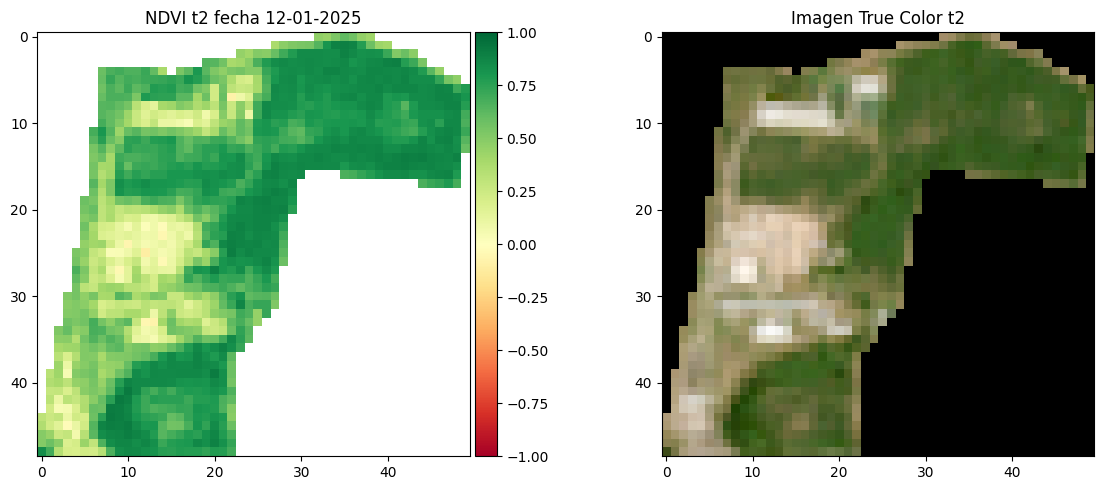

In [69]:

# Rutas de ejemplo: ajuste a su caso
PATH_B4 = '2023/2023-06-12/2023-06-12-00_00_2023-06-12-23_59_Sentinel-2_L2A_B04_(Raw).tiff'   # Banda roja
PATH_B8 = '2023/2023-06-12/2023-06-12-00_00_2023-06-12-23_59_Sentinel-2_L2A_B08_(Raw).tiff'   # Banda NIR
PATH_TRUE_COLOR = '2023/2023-06-12/2023-06-12-00_00_2023-06-12-23_59_Sentinel-2_L2A_True_color.tiff'

# Helper: buscar variantes de nombre/extension o en carpeta 'data2' antes de intentar abrir
def find_band_file(path_hint, keyword=None):
    if path_hint and os.path.exists(path_hint):
        return path_hint
    if path_hint:
        base = path_hint.rsplit('.', 1)[0]
        for ext in ('tif', 'tiff'):
            candidate = f'{base}.{ext}'
            if os.path.exists(candidate):
                return candidate
    folder = os.path.dirname(path_hint) if path_hint else 'data2'
    if not folder:
        folder = 'data2'
    if os.path.isdir(folder):
        for fn in os.listdir(folder):
            if (keyword is None or keyword in fn) and (fn.lower().endswith('.tif') or fn.lower().endswith('.tiff')):
                return os.path.join(folder, fn)
    return None

# Intentar resolver rutas antes de abrir para evitar RasterioIOError
PATH_B4 = find_band_file(PATH_B4, keyword='B04') or PATH_B4
PATH_B8 = find_band_file(PATH_B8, keyword='B08') or PATH_B8
PATH_TRUE_COLOR = find_band_file(PATH_TRUE_COLOR, keyword='True_color') or PATH_TRUE_COLOR

# Inicializar variables por si no podemos abrir los archivos
ds_b4 = ds_b8 = None
b4 = b8 = None

# Solo abrir si existe el archivo resuelto y capturar errores
if PATH_B4 and os.path.exists(PATH_B4):
    try:
        ds_b4, b4 = read_raster(PATH_B4)
    except Exception as e:
        print(f"Error al abrir PATH_B4 ({PATH_B4}):", e)
        ds_b4 = b4 = None
else:
    print(f"PATH_B4 no existe: {PATH_B4}")

if PATH_B8 and os.path.exists(PATH_B8):
    try:
        ds_b8, b8 = read_raster(PATH_B8)
    except Exception as e:
        print(f"Error al abrir PATH_B8 ({PATH_B8}):", e)
        ds_b8 = b8 = None
else:
    print(f"PATH_B8 no existe: {PATH_B8}")

# Si ambos bandas se cargaron correctamente, continuar
if ds_b4 is not None and ds_b8 is not None and b4 is not None and b8 is not None:
    # Si las dimensiones difieren, re-muestrear B4 a la malla de B8
    try:
        if (ds_b4.width != ds_b8.width) or (ds_b4.height != ds_b8.height) or (ds_b4.transform != ds_b8.transform):
            b4 = resample_to_match(ds_b4, b4, ds_b8)
    except Exception as e:
        print("Error al comparar/resamplear mallas:", e)

    print("B4 shape:", b4.shape, "B8 shape:", b8.shape)

    ndvi = compute_ndvi(b8, b4)
    if valid_mask is not None:
        ndvi = np.where(valid_mask, ndvi, np.nan)
    ndvi_min, ndvi_max = np.nanmin(ndvi), np.nanmax(ndvi)
    print(f"NDVI rango: min={ndvi_min:.3f}, max={ndvi_max:.3f}")
else:
    print("No se pudieron cargar B4 y/o B8 de la primera fecha. Se omite cálculo de NDVI (t1).")
    ndvi = None

ndvi_2023_1 = ndvi


from mpl_toolkits.axes_grid1 import make_axes_locatable

# Cargar imagen True Color solo si existe; si no, usar 'img' ya presente en el entorno o mostrar placeholder
img = None
try:
    if PATH_TRUE_COLOR and os.path.exists(PATH_TRUE_COLOR):
        _, img = read_raster_rgb(PATH_TRUE_COLOR)
    else:
        print(f"PATH_TRUE_COLOR no existe: {PATH_TRUE_COLOR}. Se usará 'img' existente en el entorno si hay.")
        img = globals().get('img', None)
except Exception as e:
    print("Error al cargar PATH_TRUE_COLOR:", e)
    img = globals().get('img', None)

# Evitar intentar plotear NDVI si no está disponible
if ndvi is None:
    print("NDVI no disponible — se omitirá la visualización inicial.")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    im1 = ax1.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    ax1.set_title('NDVI')
    divider1 = make_axes_locatable(ax1)
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im1, cax=cax1)

    if img is not None:
        ax2.imshow(img)
        ax2.set_title('Imagen True Color')
    else:
        ax2.text(0.5, 0.5, 'No True Color disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()


# Rutas de ejemplo para una segunda fecha (ajuste o deje en None)
PATH_B4_T2 = '2023/2023-12-09/2023-12-09-00_00_2023-12-09-23_59_Sentinel-2_L2A_B04_(Raw).tif'
PATH_B8_T2 = '2023/2023-12-09/2023-12-09-00_00_2023-12-09-23_59_Sentinel-2_L2A_B08_(Raw).tif'
# Asegurar extensión en la ruta True Color de la segunda fecha (evita error si falta la extensión)
PATH_TRUE_COLOR_T2 = '2023/2023-12-09/2023-12-09-00_00_2023-12-09-23_59_Sentinel-2_L2A_True_color.tiff'

have_t2 = False
ndvi_t2 = None
d_ndvi = None
img1 = None

# Resolver rutas (si las definidas no coinciden exactamente con archivos en disco)
PATH_B4_T2 = find_band_file(PATH_B4_T2, keyword='B04') or PATH_B4_T2
PATH_B8_T2 = find_band_file(PATH_B8_T2, keyword='B08') or PATH_B8_T2

print('Ruta B4 t2 ->', PATH_B4_T2)
print('Ruta B8 t2 ->', PATH_B8_T2)

# Verificar que las rutas estén definidas y que los archivos existan antes de abrirlos
if PATH_B4_T2 and PATH_B8_T2 and os.path.exists(PATH_B4_T2) and os.path.exists(PATH_B8_T2):
    try:
        ds_b4_t2, b4_t2 = read_raster(PATH_B4_T2)
        ds_b8_t2, b8_t2 = read_raster(PATH_B8_T2)
    except rasterio.errors.RasterioIOError as e:
        print("Error al abrir los archivos de la segunda fecha:", e)
    else:
        # Si no hay referencia de ds_b8 (t1) usar ds_b8_t2 como referencia para resamplear
        ref_ds = ds_b8 if (ds_b8 is not None) else ds_b8_t2
        try:
            if ds_b4_t2 is not None and ref_ds is not None and ((ds_b4_t2.width != ref_ds.width) or (ds_b4_t2.height != ref_ds.height) or (ds_b4_t2.transform != ref_ds.transform)):
                b4_t2 = resample_to_match(ds_b4_t2, b4_t2, ref_ds)
            if ds_b8_t2 is not None and ref_ds is not None and ((ds_b8_t2.width != ref_ds.width) or (ds_b8_t2.height != ref_ds.height) or (ds_b8_t2.transform != ref_ds.transform)):
                b8_t2 = resample_to_match(ds_b8_t2, b8_t2, ref_ds)
        except Exception as e:
            print("Error al re-muestrear bandas t2:", e)

        try:
            ndvi_t2 = compute_ndvi(b8_t2, b4_t2)
            if valid_mask is not None and ndvi_t2 is not None:
                ndvi_t2 = np.where(valid_mask, ndvi_t2, np.nan)
        except Exception as e:
            print("Error al calcular NDVI t2:", e)
            ndvi_t2 = None
        ndvi_2023_2 = ndvi_t2
        d_ndvi = None
        if (ndvi is not None) and (ndvi_t2 is not None):
            d_ndvi = ndvi_t2 - ndvi
        have_t2 = True if ndvi_t2 is not None else False
        # Guardar diferencia NDVI en variables solicitadas:
        df2023 = d_ndvi
        globals()['2023df'] = d_ndvi

        plt.figure()
        if d_ndvi is not None:
            plt.imshow(d_ndvi, cmap='bwr', vmin=-1, vmax=1)
            plt.title('Cambio NDVI (t2 - t1)')
            plt.colorbar()
        else:
            print('No se puede mostrar d_ndvi (falta ndvi o ndvi_t2).')
        plt.show()
else:
    print('Proporcione PATH_B4_T2 y PATH_B8_T2 válidos y existentes en disco para calcular el cambio de NDVI entre fechas.')

# Mostrar NDVI y True Color t1 (si existe)
from mpl_toolkits.axes_grid1 import make_axes_locatable

try:
    if PATH_TRUE_COLOR and os.path.exists(PATH_TRUE_COLOR):
        _, img = read_raster_rgb(PATH_TRUE_COLOR)
    # si PATH_TRUE_COLOR no existe, puede que 'img' ya esté definido en el entorno; si no, se mostrará un placeholder
except Exception as e:
    print("No se pudo cargar PATH_TRUE_COLOR:", e)
    img = globals().get('img', None)

if ndvi is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    im1 = ax1.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    ax1.set_title('NDVI (t1) fecha 08-11-2025')
    divider1 = make_axes_locatable(ax1)
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im1, cax=cax1)

    if img is not None:
        ax2.imshow(img)
        ax2.set_title('Imagen True Color')
    else:
        ax2.text(0.5, 0.5, 'No True Color disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()
else:
    print("NDVI (t1) no disponible para mostrar.")

# Cargar y mostrar True Color t2 (si existe)
if PATH_TRUE_COLOR_T2 and os.path.exists(PATH_TRUE_COLOR_T2):
    try:
        _, img1 = read_raster_rgb(PATH_TRUE_COLOR_T2)
    except Exception as e:
        print("No se pudo cargar PATH_TRUE_COLOR_T2:", e)
        img1 = None
else:
    print("PATH_TRUE_COLOR_T2 no existe o no está definido, se omitirá la visualización de t2.")

# Mostrar NDVI t2 y True Color t2 si están disponibles
if have_t2 or (img1 is not None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    if have_t2 and ndvi_t2 is not None:
        im1 = ax1.imshow(ndvi_t2, cmap='RdYlGn', vmin=-1, vmax=1)
        ax1.set_title('NDVI t2 fecha 12-01-2025')
        divider1 = make_axes_locatable(ax1)
        cax1 = divider1.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(im1, cax=cax1)
    else:
        ax1.text(0.5, 0.5, 'NDVI t2 no disponible', ha='center', va='center')
        ax1.set_axis_off()

    if img1 is not None:
        ax2.imshow(img1)
        ax2.set_title('Imagen True Color t2')
    else:
        ax2.text(0.5, 0.5, 'True Color t2 no disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()






2024

B4 shape: (49, 50) B8 shape: (49, 50)
NDVI rango: min=-0.005, max=0.776


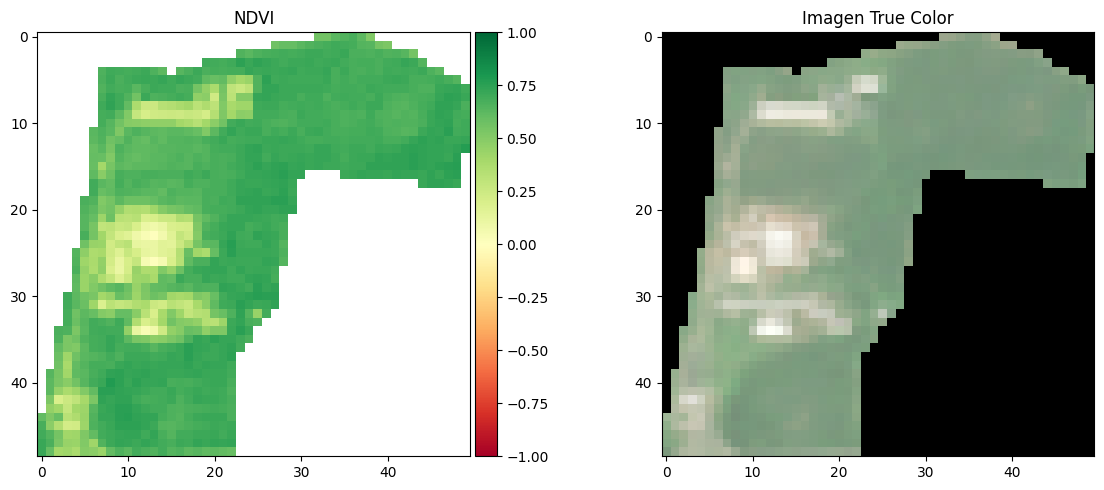

Ruta B4 t2 -> 2024/2024-12-08/2024-12-08-00_00_2024-12-08-23_59_Sentinel-2_L2A_B04_(Raw).tiff
Ruta B8 t2 -> 2024/2024-12-08/2024-12-08-00_00_2024-12-08-23_59_Sentinel-2_L2A_B08_(Raw).tiff


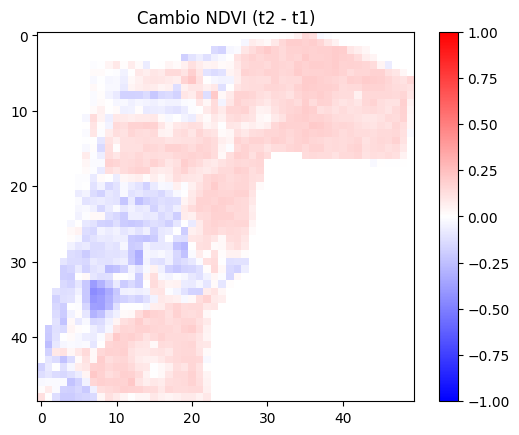

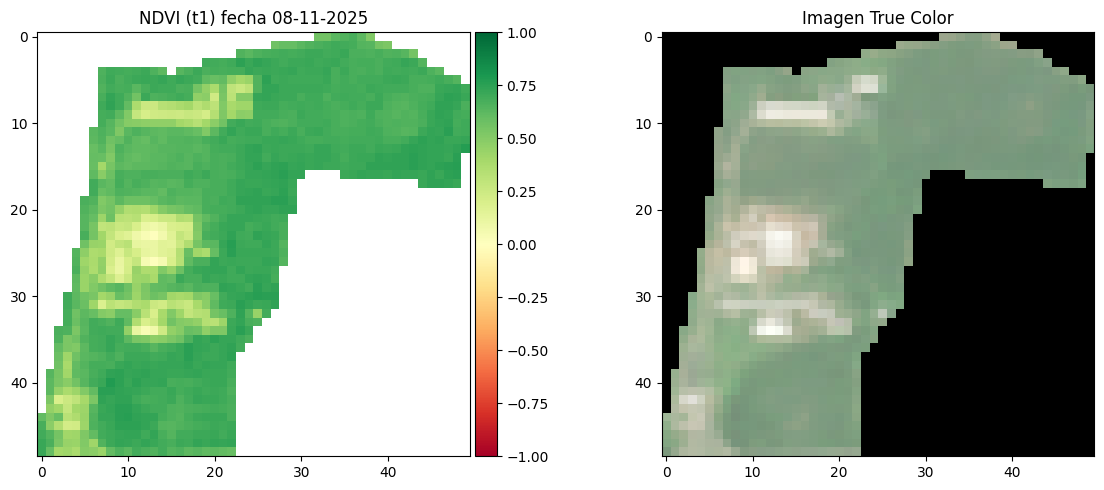

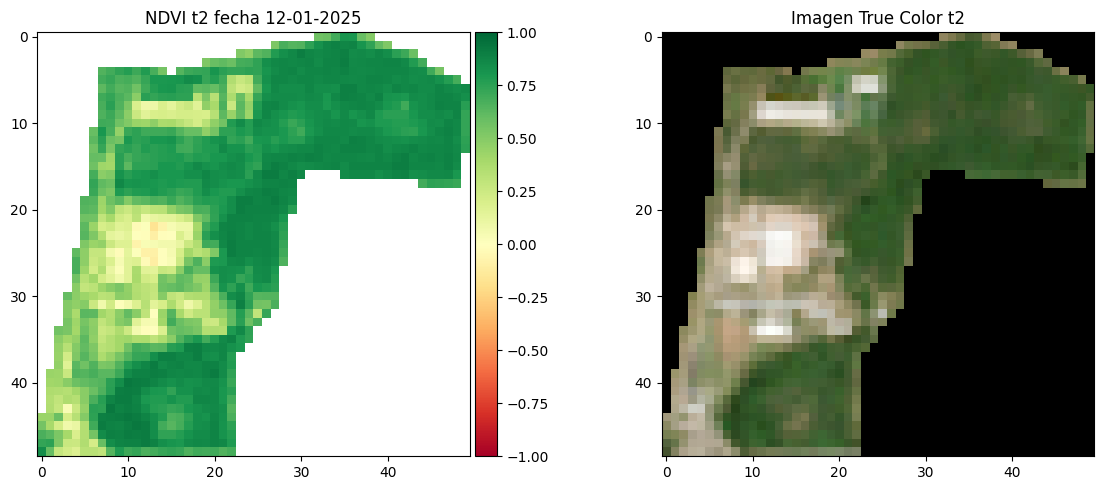

In [70]:

# Rutas de ejemplo: ajuste a su caso
PATH_B4 = '2024/2024-06-16/2024-06-16-00_00_2024-06-16-23_59_Sentinel-2_L2A_B04_(Raw).tiff'   # Banda roja
PATH_B8 = '2024/2024-06-16/2024-06-16-00_00_2024-06-16-23_59_Sentinel-2_L2A_B08_(Raw).tiff'   # Banda NIR
PATH_TRUE_COLOR = '2024/2024-06-16/2024-06-16-00_00_2024-06-16-23_59_Sentinel-2_L2A_True_color.tiff'

# Helper: buscar variantes de nombre/extension o en carpeta 'data2' antes de intentar abrir
def find_band_file(path_hint, keyword=None):
    if path_hint and os.path.exists(path_hint):
        return path_hint
    if path_hint:
        base = path_hint.rsplit('.', 1)[0]
        for ext in ('tif', 'tiff'):
            candidate = f'{base}.{ext}'
            if os.path.exists(candidate):
                return candidate
    folder = os.path.dirname(path_hint) if path_hint else 'data2'
    if not folder:
        folder = 'data2'
    if os.path.isdir(folder):
        for fn in os.listdir(folder):
            if (keyword is None or keyword in fn) and (fn.lower().endswith('.tif') or fn.lower().endswith('.tiff')):
                return os.path.join(folder, fn)
    return None

# Intentar resolver rutas antes de abrir para evitar RasterioIOError
PATH_B4 = find_band_file(PATH_B4, keyword='B04') or PATH_B4
PATH_B8 = find_band_file(PATH_B8, keyword='B08') or PATH_B8
PATH_TRUE_COLOR = find_band_file(PATH_TRUE_COLOR, keyword='True_color') or PATH_TRUE_COLOR

# Inicializar variables por si no podemos abrir los archivos
ds_b4 = ds_b8 = None
b4 = b8 = None

# Solo abrir si existe el archivo resuelto y capturar errores
if PATH_B4 and os.path.exists(PATH_B4):
    try:
        ds_b4, b4 = read_raster(PATH_B4)
    except Exception as e:
        print(f"Error al abrir PATH_B4 ({PATH_B4}):", e)
        ds_b4 = b4 = None
else:
    print(f"PATH_B4 no existe: {PATH_B4}")

if PATH_B8 and os.path.exists(PATH_B8):
    try:
        ds_b8, b8 = read_raster(PATH_B8)
    except Exception as e:
        print(f"Error al abrir PATH_B8 ({PATH_B8}):", e)
        ds_b8 = b8 = None
else:
    print(f"PATH_B8 no existe: {PATH_B8}")

# Si ambos bandas se cargaron correctamente, continuar
if ds_b4 is not None and ds_b8 is not None and b4 is not None and b8 is not None:
    # Si las dimensiones difieren, re-muestrear B4 a la malla de B8
    try:
        if (ds_b4.width != ds_b8.width) or (ds_b4.height != ds_b8.height) or (ds_b4.transform != ds_b8.transform):
            b4 = resample_to_match(ds_b4, b4, ds_b8)
    except Exception as e:
        print("Error al comparar/resamplear mallas:", e)

    print("B4 shape:", b4.shape, "B8 shape:", b8.shape)

    ndvi = compute_ndvi(b8, b4)
    if valid_mask is not None:
        ndvi = np.where(valid_mask, ndvi, np.nan)
    ndvi_min, ndvi_max = np.nanmin(ndvi), np.nanmax(ndvi)
    print(f"NDVI rango: min={ndvi_min:.3f}, max={ndvi_max:.3f}")
else:
    print("No se pudieron cargar B4 y/o B8 de la primera fecha. Se omite cálculo de NDVI (t1).")
    ndvi = None
ndvi_2024_1 = ndvi


from mpl_toolkits.axes_grid1 import make_axes_locatable

# Cargar imagen True Color solo si existe; si no, usar 'img' ya presente en el entorno o mostrar placeholder
img = None
try:
    if PATH_TRUE_COLOR and os.path.exists(PATH_TRUE_COLOR):
        _, img = read_raster_rgb(PATH_TRUE_COLOR)
    else:
        print(f"PATH_TRUE_COLOR no existe: {PATH_TRUE_COLOR}. Se usará 'img' existente en el entorno si hay.")
        img = globals().get('img', None)
except Exception as e:
    print("Error al cargar PATH_TRUE_COLOR:", e)
    img = globals().get('img', None)

# Evitar intentar plotear NDVI si no está disponible
if ndvi is None:
    print("NDVI no disponible — se omitirá la visualización inicial.")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    im1 = ax1.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    ax1.set_title('NDVI')
    divider1 = make_axes_locatable(ax1)
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im1, cax=cax1)

    if img is not None:
        ax2.imshow(img)
        ax2.set_title('Imagen True Color')
    else:
        ax2.text(0.5, 0.5, 'No True Color disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()


# Rutas de ejemplo para una segunda fecha (ajuste o deje en None)
PATH_B4_T2 = '2024/2024-12-08/2024-12-08-00_00_2024-12-08-23_59_Sentinel-2_L2A_B04_(Raw).tif'
PATH_B8_T2 = '2024/2024-12-08/2024-12-08-00_00_2024-12-08-23_59_Sentinel-2_L2A_B08_(Raw).tif'
# Asegurar extensión en la ruta True Color de la segunda fecha (evita error si falta la extensión)
PATH_TRUE_COLOR_T2 = '2024/2024-12-08/2024-12-08-00_00_2024-12-08-23_59_Sentinel-2_L2A_True_color.tiff'

have_t2 = False
ndvi_t2 = None
d_ndvi = None
img1 = None

# Resolver rutas (si las definidas no coinciden exactamente con archivos en disco)
PATH_B4_T2 = find_band_file(PATH_B4_T2, keyword='B04') or PATH_B4_T2
PATH_B8_T2 = find_band_file(PATH_B8_T2, keyword='B08') or PATH_B8_T2

print('Ruta B4 t2 ->', PATH_B4_T2)
print('Ruta B8 t2 ->', PATH_B8_T2)

# Verificar que las rutas estén definidas y que los archivos existan antes de abrirlos
if PATH_B4_T2 and PATH_B8_T2 and os.path.exists(PATH_B4_T2) and os.path.exists(PATH_B8_T2):
    try:
        ds_b4_t2, b4_t2 = read_raster(PATH_B4_T2)
        ds_b8_t2, b8_t2 = read_raster(PATH_B8_T2)
    except rasterio.errors.RasterioIOError as e:
        print("Error al abrir los archivos de la segunda fecha:", e)
    else:
        # Si no hay referencia de ds_b8 (t1) usar ds_b8_t2 como referencia para resamplear
        ref_ds = ds_b8 if (ds_b8 is not None) else ds_b8_t2
        try:
            if ds_b4_t2 is not None and ref_ds is not None and ((ds_b4_t2.width != ref_ds.width) or (ds_b4_t2.height != ref_ds.height) or (ds_b4_t2.transform != ref_ds.transform)):
                b4_t2 = resample_to_match(ds_b4_t2, b4_t2, ref_ds)
            if ds_b8_t2 is not None and ref_ds is not None and ((ds_b8_t2.width != ref_ds.width) or (ds_b8_t2.height != ref_ds.height) or (ds_b8_t2.transform != ref_ds.transform)):
                b8_t2 = resample_to_match(ds_b8_t2, b8_t2, ref_ds)
        except Exception as e:
            print("Error al re-muestrear bandas t2:", e)

        try:
            ndvi_t2 = compute_ndvi(b8_t2, b4_t2)
            if valid_mask is not None and ndvi_t2 is not None:
                ndvi_t2 = np.where(valid_mask, ndvi_t2, np.nan)
        except Exception as e:
            print("Error al calcular NDVI t2:", e)
            ndvi_t2 = None
        ndvi_2024_2 = ndvi_t2
        d_ndvi = None
        if (ndvi is not None) and (ndvi_t2 is not None):
            d_ndvi = ndvi_t2 - ndvi
        have_t2 = True if ndvi_t2 is not None else False
        # Guardar diferencia NDVI en variables solicitadas:
        df2024 = d_ndvi
        globals()['2024df'] = d_ndvi

        plt.figure()
        if d_ndvi is not None:
            plt.imshow(d_ndvi, cmap='bwr', vmin=-1, vmax=1)
            plt.title('Cambio NDVI (t2 - t1)')
            plt.colorbar()
        else:
            print('No se puede mostrar d_ndvi (falta ndvi o ndvi_t2).')
        plt.show()
else:
    print('Proporcione PATH_B4_T2 y PATH_B8_T2 válidos y existentes en disco para calcular el cambio de NDVI entre fechas.')

# Mostrar NDVI y True Color t1 (si existe)
from mpl_toolkits.axes_grid1 import make_axes_locatable

try:
    if PATH_TRUE_COLOR and os.path.exists(PATH_TRUE_COLOR):
        _, img = read_raster_rgb(PATH_TRUE_COLOR)
    # si PATH_TRUE_COLOR no existe, puede que 'img' ya esté definido en el entorno; si no, se mostrará un placeholder
except Exception as e:
    print("No se pudo cargar PATH_TRUE_COLOR:", e)
    img = globals().get('img', None)

if ndvi is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    im1 = ax1.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    ax1.set_title('NDVI (t1) fecha 08-11-2025')
    divider1 = make_axes_locatable(ax1)
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im1, cax=cax1)

    if img is not None:
        ax2.imshow(img)
        ax2.set_title('Imagen True Color')
    else:
        ax2.text(0.5, 0.5, 'No True Color disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()
else:
    print("NDVI (t1) no disponible para mostrar.")

# Cargar y mostrar True Color t2 (si existe)
if PATH_TRUE_COLOR_T2 and os.path.exists(PATH_TRUE_COLOR_T2):
    try:
        _, img1 = read_raster_rgb(PATH_TRUE_COLOR_T2)
    except Exception as e:
        print("No se pudo cargar PATH_TRUE_COLOR_T2:", e)
        img1 = None
else:
    print("PATH_TRUE_COLOR_T2 no existe o no está definido, se omitirá la visualización de t2.")

# Mostrar NDVI t2 y True Color t2 si están disponibles
if have_t2 or (img1 is not None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    if have_t2 and ndvi_t2 is not None:
        im1 = ax1.imshow(ndvi_t2, cmap='RdYlGn', vmin=-1, vmax=1)
        ax1.set_title('NDVI t2 fecha 12-01-2025')
        divider1 = make_axes_locatable(ax1)
        cax1 = divider1.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(im1, cax=cax1)
    else:
        ax1.text(0.5, 0.5, 'NDVI t2 no disponible', ha='center', va='center')
        ax1.set_axis_off()

    if img1 is not None:
        ax2.imshow(img1)
        ax2.set_title('Imagen True Color t2')
    else:
        ax2.text(0.5, 0.5, 'True Color t2 no disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()






2025

B4 shape: (49, 50) B8 shape: (49, 50)
NDVI rango: min=-0.118, max=0.936


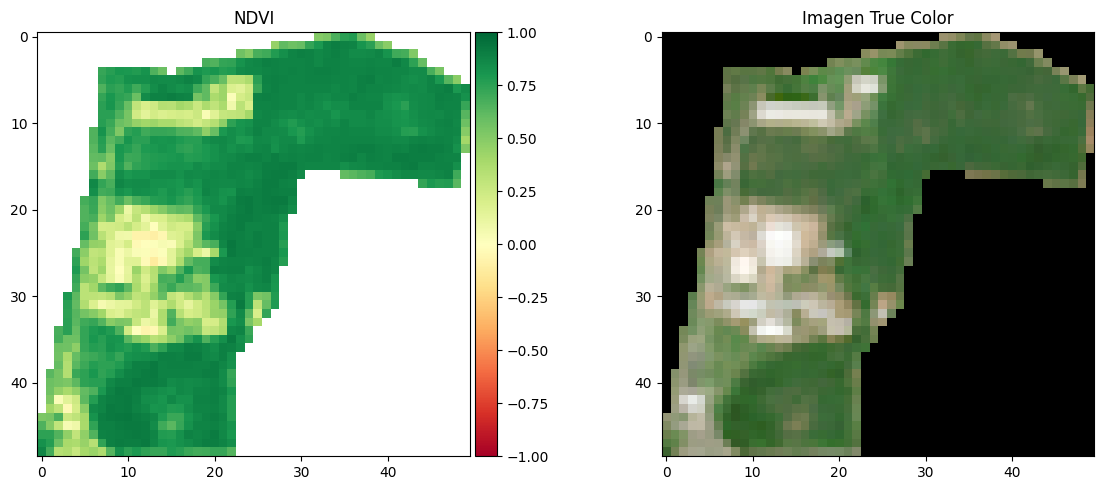

Ruta B4 t2 -> 2025/2025-11-08/2025-11-08-00_00_2025-11-08-23_59_Sentinel-2_L2A_B04_(Raw).tiff
Ruta B8 t2 -> 2025/2025-11-08/2025-11-08-00_00_2025-11-08-23_59_Sentinel-2_L2A_B08_(Raw).tiff


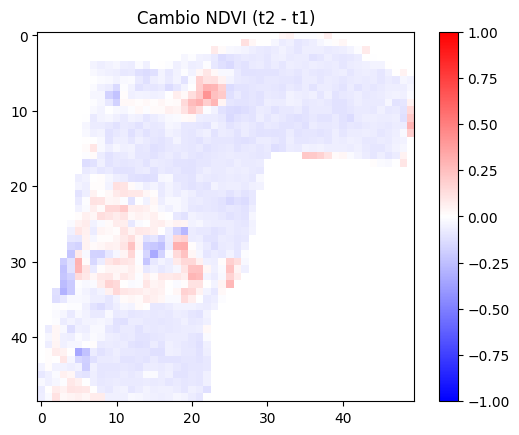

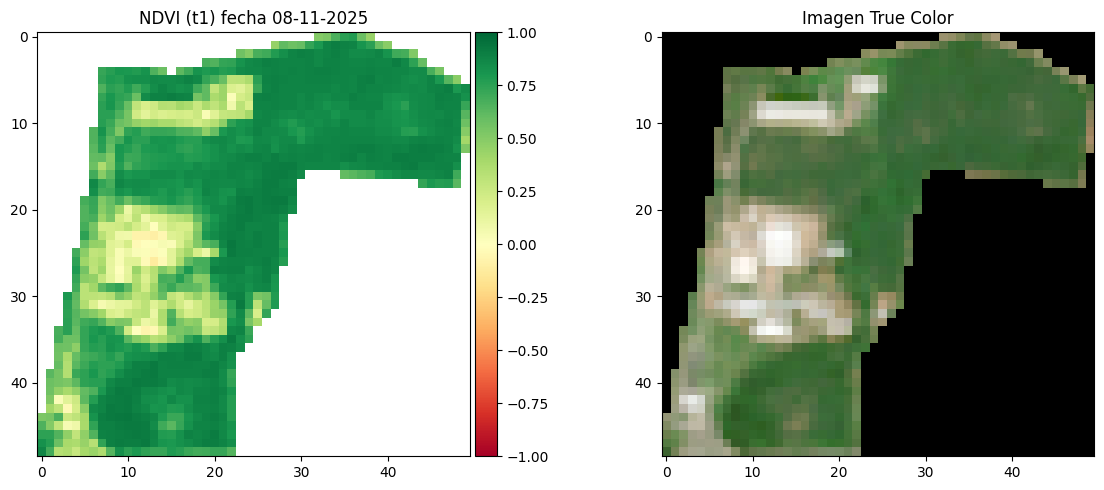

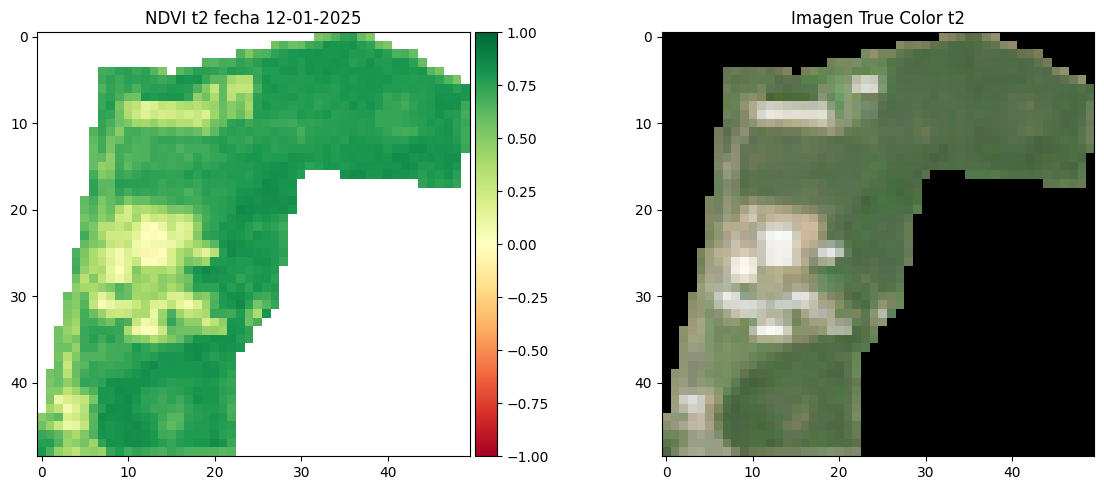

In [71]:

# Rutas de ejemplo: ajuste a su caso
PATH_B4 = '2025/2025-06-03/2025-06-03-00_00_2025-06-03-23_59_Sentinel-2_L2A_B04_(Raw).tiff'   # Banda roja
PATH_B8 = '2025/2025-06-03/2025-06-03-00_00_2025-06-03-23_59_Sentinel-2_L2A_B08_(Raw).tiff'   # Banda NIR
PATH_TRUE_COLOR = '2025/2025-06-03/2025-06-03-00_00_2025-06-03-23_59_Sentinel-2_L2A_True_color.tiff'

# Helper: buscar variantes de nombre/extension o en carpeta 'data2' antes de intentar abrir
def find_band_file(path_hint, keyword=None):
    if path_hint and os.path.exists(path_hint):
        return path_hint
    if path_hint:
        base = path_hint.rsplit('.', 1)[0]
        for ext in ('tif', 'tiff'):
            candidate = f'{base}.{ext}'
            if os.path.exists(candidate):
                return candidate
    folder = os.path.dirname(path_hint) if path_hint else 'data2'
    if not folder:
        folder = 'data2'
    if os.path.isdir(folder):
        for fn in os.listdir(folder):
            if (keyword is None or keyword in fn) and (fn.lower().endswith('.tif') or fn.lower().endswith('.tiff')):
                return os.path.join(folder, fn)
    return None

# Intentar resolver rutas antes de abrir para evitar RasterioIOError
PATH_B4 = find_band_file(PATH_B4, keyword='B04') or PATH_B4
PATH_B8 = find_band_file(PATH_B8, keyword='B08') or PATH_B8
PATH_TRUE_COLOR = find_band_file(PATH_TRUE_COLOR, keyword='True_color') or PATH_TRUE_COLOR

# Inicializar variables por si no podemos abrir los archivos
ds_b4 = ds_b8 = None
b4 = b8 = None

# Solo abrir si existe el archivo resuelto y capturar errores
if PATH_B4 and os.path.exists(PATH_B4):
    try:
        ds_b4, b4 = read_raster(PATH_B4)
    except Exception as e:
        print(f"Error al abrir PATH_B4 ({PATH_B4}):", e)
        ds_b4 = b4 = None
else:
    print(f"PATH_B4 no existe: {PATH_B4}")

if PATH_B8 and os.path.exists(PATH_B8):
    try:
        ds_b8, b8 = read_raster(PATH_B8)
    except Exception as e:
        print(f"Error al abrir PATH_B8 ({PATH_B8}):", e)
        ds_b8 = b8 = None
else:
    print(f"PATH_B8 no existe: {PATH_B8}")

# Si ambos bandas se cargaron correctamente, continuar
if ds_b4 is not None and ds_b8 is not None and b4 is not None and b8 is not None:
    # Si las dimensiones difieren, re-muestrear B4 a la malla de B8
    try:
        if (ds_b4.width != ds_b8.width) or (ds_b4.height != ds_b8.height) or (ds_b4.transform != ds_b8.transform):
            b4 = resample_to_match(ds_b4, b4, ds_b8)
    except Exception as e:
        print("Error al comparar/resamplear mallas:", e)

    print("B4 shape:", b4.shape, "B8 shape:", b8.shape)

    ndvi = compute_ndvi(b8, b4)
    if valid_mask is not None:
        ndvi = np.where(valid_mask, ndvi, np.nan)
    ndvi_min, ndvi_max = np.nanmin(ndvi), np.nanmax(ndvi)
    print(f"NDVI rango: min={ndvi_min:.3f}, max={ndvi_max:.3f}")
else:
    print("No se pudieron cargar B4 y/o B8 de la primera fecha. Se omite cálculo de NDVI (t1).")
    ndvi = None
ndvi_2025_1 = ndvi


from mpl_toolkits.axes_grid1 import make_axes_locatable

# Cargar imagen True Color solo si existe; si no, usar 'img' ya presente en el entorno o mostrar placeholder
img = None
try:
    if PATH_TRUE_COLOR and os.path.exists(PATH_TRUE_COLOR):
        _, img = read_raster_rgb(PATH_TRUE_COLOR)
    else:
        print(f"PATH_TRUE_COLOR no existe: {PATH_TRUE_COLOR}. Se usará 'img' existente en el entorno si hay.")
        img = globals().get('img', None)
except Exception as e:
    print("Error al cargar PATH_TRUE_COLOR:", e)
    img = globals().get('img', None)

# Evitar intentar plotear NDVI si no está disponible
if ndvi is None:
    print("NDVI no disponible — se omitirá la visualización inicial.")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    im1 = ax1.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    ax1.set_title('NDVI')
    divider1 = make_axes_locatable(ax1)
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im1, cax=cax1)

    if img is not None:
        ax2.imshow(img)
        ax2.set_title('Imagen True Color')
    else:
        ax2.text(0.5, 0.5, 'No True Color disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()


# Rutas de ejemplo para una segunda fecha (ajuste o deje en None)
PATH_B4_T2 = '2025/2025-11-08/2025-11-08-00_00_2025-11-08-23_59_Sentinel-2_L2A_B04_(Raw).tif'
PATH_B8_T2 = '2025/2025-11-08/2025-11-08-00_00_2025-11-08-23_59_Sentinel-2_L2A_B08_(Raw).tif'
# Asegurar extensión en la ruta True Color de la segunda fecha (evita error si falta la extensión)
PATH_TRUE_COLOR_T2 = '2025/2025-11-08/2025-11-08-00_00_2025-11-08-23_59_Sentinel-2_L2A_True_color.tiff'

have_t2 = False
ndvi_t2 = None
d_ndvi = None
img1 = None

# Resolver rutas (si las definidas no coinciden exactamente con archivos en disco)
PATH_B4_T2 = find_band_file(PATH_B4_T2, keyword='B04') or PATH_B4_T2
PATH_B8_T2 = find_band_file(PATH_B8_T2, keyword='B08') or PATH_B8_T2

print('Ruta B4 t2 ->', PATH_B4_T2)
print('Ruta B8 t2 ->', PATH_B8_T2)

# Verificar que las rutas estén definidas y que los archivos existan antes de abrirlos
if PATH_B4_T2 and PATH_B8_T2 and os.path.exists(PATH_B4_T2) and os.path.exists(PATH_B8_T2):
    try:
        ds_b4_t2, b4_t2 = read_raster(PATH_B4_T2)
        ds_b8_t2, b8_t2 = read_raster(PATH_B8_T2)
    except rasterio.errors.RasterioIOError as e:
        print("Error al abrir los archivos de la segunda fecha:", e)
    else:
        # Si no hay referencia de ds_b8 (t1) usar ds_b8_t2 como referencia para resamplear
        ref_ds = ds_b8 if (ds_b8 is not None) else ds_b8_t2
        try:
            if ds_b4_t2 is not None and ref_ds is not None and ((ds_b4_t2.width != ref_ds.width) or (ds_b4_t2.height != ref_ds.height) or (ds_b4_t2.transform != ref_ds.transform)):
                b4_t2 = resample_to_match(ds_b4_t2, b4_t2, ref_ds)
            if ds_b8_t2 is not None and ref_ds is not None and ((ds_b8_t2.width != ref_ds.width) or (ds_b8_t2.height != ref_ds.height) or (ds_b8_t2.transform != ref_ds.transform)):
                b8_t2 = resample_to_match(ds_b8_t2, b8_t2, ref_ds)
        except Exception as e:
            print("Error al re-muestrear bandas t2:", e)

        try:
            ndvi_t2 = compute_ndvi(b8_t2, b4_t2)
            if valid_mask is not None and ndvi_t2 is not None:
                ndvi_t2 = np.where(valid_mask, ndvi_t2, np.nan)
        except Exception as e:
            print("Error al calcular NDVI t2:", e)
            ndvi_t2 = None
        ndvi_2025_2 = ndvi_t2
        d_ndvi = None
        if (ndvi is not None) and (ndvi_t2 is not None):
            d_ndvi = ndvi_t2 - ndvi
        have_t2 = True if ndvi_t2 is not None else False
        # Guardar diferencia NDVI en variables solicitadas:
        df2025 = d_ndvi
        globals()['2025df'] = d_ndvi

        plt.figure()
        if d_ndvi is not None:
            plt.imshow(d_ndvi, cmap='bwr', vmin=-1, vmax=1)
            plt.title('Cambio NDVI (t2 - t1)')
            plt.colorbar()
        else:
            print('No se puede mostrar d_ndvi (falta ndvi o ndvi_t2).')
        plt.show()
else:
    print('Proporcione PATH_B4_T2 y PATH_B8_T2 válidos y existentes en disco para calcular el cambio de NDVI entre fechas.')

# Mostrar NDVI y True Color t1 (si existe)
from mpl_toolkits.axes_grid1 import make_axes_locatable

try:
    if PATH_TRUE_COLOR and os.path.exists(PATH_TRUE_COLOR):
        _, img = read_raster_rgb(PATH_TRUE_COLOR)
    # si PATH_TRUE_COLOR no existe, puede que 'img' ya esté definido en el entorno; si no, se mostrará un placeholder
except Exception as e:
    print("No se pudo cargar PATH_TRUE_COLOR:", e)
    img = globals().get('img', None)

if ndvi is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    im1 = ax1.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    ax1.set_title('NDVI (t1) fecha 08-11-2025')
    divider1 = make_axes_locatable(ax1)
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im1, cax=cax1)

    if img is not None:
        ax2.imshow(img)
        ax2.set_title('Imagen True Color')
    else:
        ax2.text(0.5, 0.5, 'No True Color disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()
else:
    print("NDVI (t1) no disponible para mostrar.")

# Cargar y mostrar True Color t2 (si existe)
if PATH_TRUE_COLOR_T2 and os.path.exists(PATH_TRUE_COLOR_T2):
    try:
        _, img1 = read_raster_rgb(PATH_TRUE_COLOR_T2)
    except Exception as e:
        print("No se pudo cargar PATH_TRUE_COLOR_T2:", e)
        img1 = None
else:
    print("PATH_TRUE_COLOR_T2 no existe o no está definido, se omitirá la visualización de t2.")

# Mostrar NDVI t2 y True Color t2 si están disponibles
if have_t2 or (img1 is not None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    if have_t2 and ndvi_t2 is not None:
        im1 = ax1.imshow(ndvi_t2, cmap='RdYlGn', vmin=-1, vmax=1)
        ax1.set_title('NDVI t2 fecha 12-01-2025')
        divider1 = make_axes_locatable(ax1)
        cax1 = divider1.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(im1, cax=cax1)
    else:
        ax1.text(0.5, 0.5, 'NDVI t2 no disponible', ha='center', va='center')
        ax1.set_axis_off()

    if img1 is not None:
        ax2.imshow(img1)
        ax2.set_title('Imagen True Color t2')
    else:
        ax2.text(0.5, 0.5, 'True Color t2 no disponible', ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()






    Año  Promedio_extremos
0  2016           0.263088
1  2017           0.021579
2  2018          -0.270824
3  2019          -0.250877
4  2020           0.024273
5  2021          -0.275755
6  2022           0.214044
7  2023          -0.259967
8  2024          -0.259967
9  2025          -0.163609


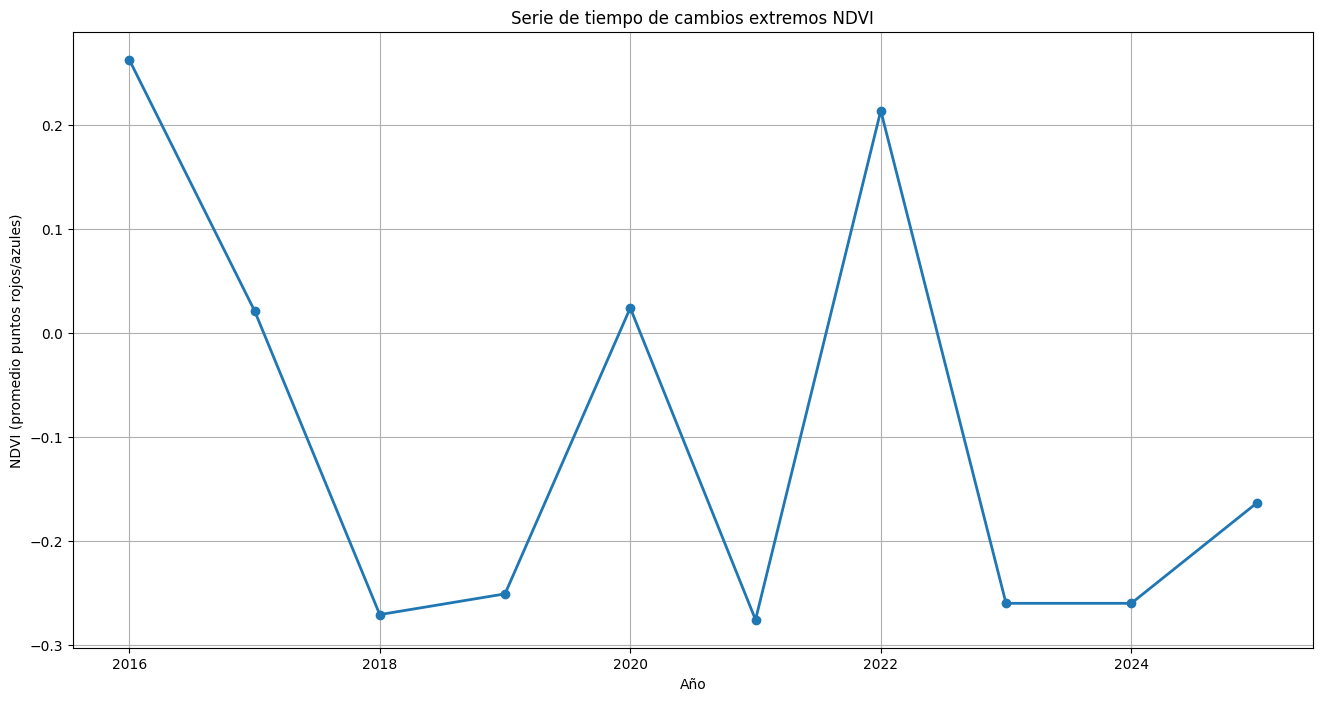

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Ajusta si quieres otros umbrales ---
LOW_THRESHOLD = -0.2   # azul
HIGH_THRESHOLD =  0.2   # rojo

def extract_blue_red_values(raster, low=LOW_THRESHOLD, high=HIGH_THRESHOLD):
    """Extrae solo valores muy negativos (azules) y muy positivos (rojos).
    Si `raster` es None devuelve un array vacío."""
    if raster is None:
        return np.array([], dtype=float)
    flat = raster.flatten()
    mask = (flat < low) | (flat > high)
    return flat[mask]

# --- Extraer valores extremos por año (manejo seguro de variables None) ---
years = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
var_names = ["df2016", "df2017", "df2018", "df2019","df2020","df2021","df2022", "df2023", "df2023", "df2024", "df2025"]

anos = []
promedios = []

for y, vn in zip(years, var_names):
    arr = globals().get(vn, None)
    if arr is None:
        # Omitir años sin datos y notificar
        print(f"Advertencia: {vn} no está definido (None). Se omite el año {y}.")
        continue
    vals = extract_blue_red_values(arr)
    if vals.size == 0:
        mean_val = np.nan
    else:
        mean_val = float(np.nanmean(vals))
    anos.append(y)
    promedios.append(mean_val)

# Si no hay datos, crear DataFrame vacío con columnas esperadas
if len(anos) == 0:
    df_series = pd.DataFrame(columns=["Año", "Promedio_extremos"])
else:
    df_series = pd.DataFrame({"Año": anos, "Promedio_extremos": promedios})

print(df_series)

# --- Graficar la serie (si hay al menos un punto válido) ---
if df_series["Promedio_extremos"].dropna().size == 0:
    print("No hay valores válidos para graficar.")
else:
    plt.figure(figsize=(16,8))
    plt.plot(df_series["Año"], df_series["Promedio_extremos"], marker='o', linewidth=2)
    plt.xlabel("Año")
    plt.ylabel("NDVI (promedio puntos rojos/azules)")
    plt.title("Serie de tiempo de cambios extremos NDVI")
    plt.grid(True)
    plt.show()


In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Umbrales ---
LOW_THRESHOLD = -0.2   # azul
HIGH_THRESHOLD =  0.2   # rojo

def extract_blue_values(raster, low=LOW_THRESHOLD):
    """Extrae valores muy negativos (azules)."""
    if raster is None:
        return np.array([], dtype=float)
    flat = raster.flatten()
    return flat[flat < low]

def extract_red_values(raster, high=HIGH_THRESHOLD):
    """Extrae valores muy positivos (rojos)."""
    if raster is None:
        return np.array([], dtype=float)
    flat = raster.flatten()
    return flat[flat > high]

# --- Extraer valores extremos por año ---
years = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
var_names = ["df2016", "df2017", "df2018", "df2019", "df2020", "df2021", "df2022", "df2023", "df2024", "df2025"]

anos = []
prom_azules = []
prom_rojos = []

for y, vn in zip(years, var_names):
    arr = globals().get(vn, None)

    if arr is None:
        print(f"Advertencia: {vn} no está definido. Se omite el año {y}.")
        continue

    # Extraer puntos azules y rojos
    vals_blue = extract_blue_values(arr)
    vals_red = extract_red_values(arr)

    # Promedios (si no hay puntos -> NaN)
    mean_blue = float(np.nanmean(vals_blue)) if vals_blue.size else np.nan
    mean_red = float(np.nanmean(vals_red)) if vals_red.size else np.nan

    anos.append(y)
    prom_azules.append(mean_blue)
    prom_rojos.append(mean_red)

# Crear DataFrame final
df_series = pd.DataFrame({
    "Año": anos,
    "Promedio_azules": prom_azules,
    "Promedio_rojos": prom_rojos
})

print(df_series)


    Año  Promedio_azules  Promedio_rojos
0  2016        -0.200066        0.271665
1  2017        -0.257516        0.244855
2  2018        -0.290392        0.255889
3  2019        -0.250877             NaN
4  2020        -0.256750        0.235041
5  2021        -0.275755             NaN
6  2022        -0.248355        0.244871
7  2023        -0.276526        0.238643
8  2024        -0.262527        0.207331
9  2025        -0.250735        0.262596


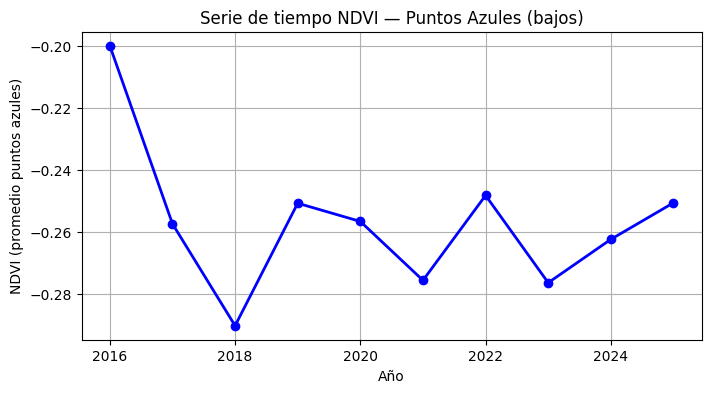

In [74]:
if df_series["Promedio_azules"].dropna().size > 0:
    plt.figure(figsize=(8,4))
    plt.plot(df_series["Año"], df_series["Promedio_azules"], 
             marker='o', linewidth=2, color='blue')
    plt.xlabel("Año")
    plt.ylabel("NDVI (promedio puntos azules)")
    plt.title("Serie de tiempo NDVI — Puntos Azules (bajos)")
    plt.grid(True)
    plt.show()
else:
    print("No hay valores azules para graficar.")


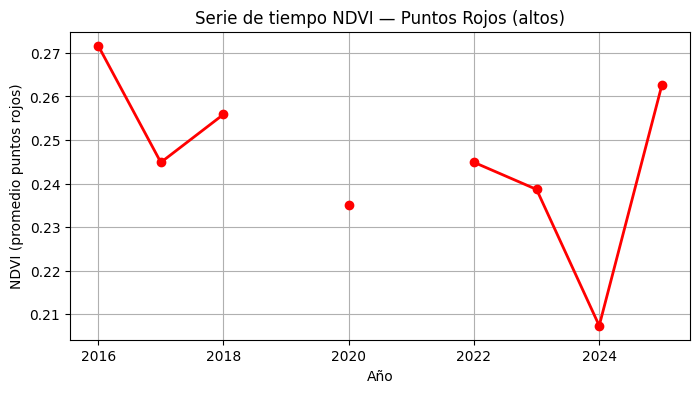

In [75]:
if df_series["Promedio_rojos"].dropna().size > 0:
    plt.figure(figsize=(8,4))
    plt.plot(df_series["Año"], df_series["Promedio_rojos"], 
             marker='o', linewidth=2, color='red')
    plt.xlabel("Año")
    plt.ylabel("NDVI (promedio puntos rojos)")
    plt.title("Serie de tiempo NDVI — Puntos Rojos (altos)")
    plt.grid(True)
    plt.show()
else:
    print("No hay valores rojos para graficar.")


    Año  Promedio_extremos
0  2016           0.630948
1  2017           0.601818
2  2018           0.541193
3  2019           0.588192
4  2020           0.604280
5  2021           0.572423
6  2022           0.697212
7  2023           0.721385
8  2024           0.667560
9  2025           0.709301


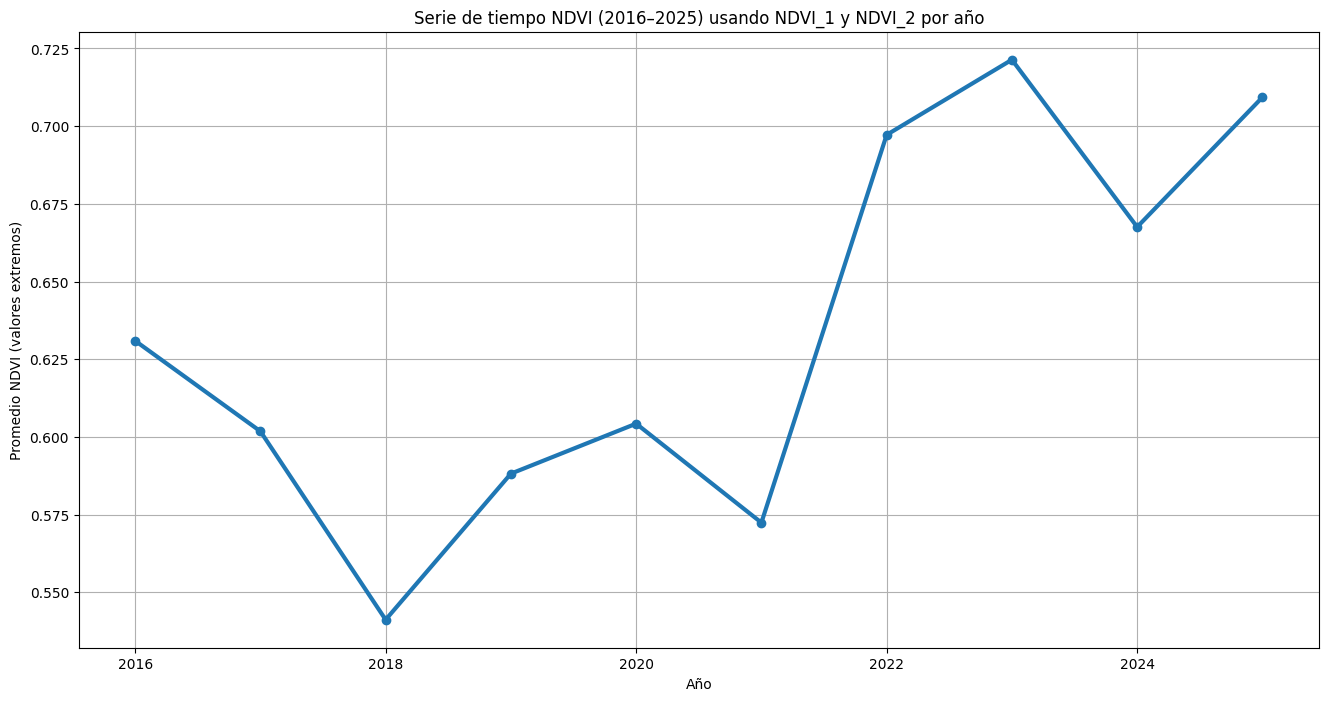

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Umbrales ---
LOW_THRESHOLD = -0.2   
HIGH_THRESHOLD =  0.2   

def extract_extreme_values(raster, low=LOW_THRESHOLD, high=HIGH_THRESHOLD):
    """Extrae valores muy negativos (azules) y muy positivos (rojos)."""
    if raster is None:
        return np.array([], dtype=float)
    flat = raster.flatten()
    mask = (flat < low) | (flat > high)
    return flat[mask]

# --- Años de análisis ---
years = list(range(2016, 2026))

anos = []
promedios = []

for y in years:
    # Variables esperadas: ndvi_YYYY_1 y ndvi_YYYY_2
    var1 = f"ndvi_{y}_1"
    var2 = f"ndvi_{y}_2"

    ndvi_1 = globals().get(var1, None)
    ndvi_2 = globals().get(var2, None)

    # Verificar existencia de ambos NDVI
    if ndvi_1 is None or ndvi_2 is None:
        print(f"Advertencia: faltan datos para el año {y}. Se omite.")
        continue

    # Extraer extremos de cada NDVI
    vals1 = extract_extreme_values(ndvi_1)
    vals2 = extract_extreme_values(ndvi_2)

    # Concatenar valores del año
    all_vals = np.concatenate([vals1, vals2]) if vals1.size + vals2.size > 0 else np.array([])

    # Calcular promedio del año
    if all_vals.size == 0:
        mean_val = np.nan
    else:
        mean_val = float(np.nanmean(all_vals))

    anos.append(y)
    promedios.append(mean_val)

# --- DataFrame final ---
if len(anos) == 0:
    df_ndvi = pd.DataFrame(columns=["Año", "Promedio_extremos"])
else:
    df_ndvi = pd.DataFrame({"Año": anos, "Promedio_extremos": promedios})

print(df_ndvi)

# --- Gráfico de serie de tiempo ---
if df_ndvi["Promedio_extremos"].dropna().size == 0:
    print("No hay valores válidos para graficar.")
else:
    plt.figure(figsize=(16,8))
    plt.plot(df_ndvi["Año"], df_ndvi["Promedio_extremos"], marker='o', linewidth=3)
    plt.xlabel("Año")
    plt.ylabel("Promedio NDVI (valores extremos)")
    plt.title("Serie de tiempo NDVI (2016–2025) usando NDVI_1 y NDVI_2 por año")
    plt.grid(True)
    plt.show()


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats


# 1. DataFrame 
ndvi3 = pd.DataFrame({
    "Año": [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    "Promedio_extremos": [
        0.630948, 0.601818, 0.541193, 0.588192,
        0.604280, 0.572423, 0.697212, 0.721385,
        0.667560, 0.709301
    ]
})

# -----------------------------
# 2. DEFINIR PERIODOS CORRECTOS
# Antes: 2016–2018
# Después: 2019–2025
# -----------------------------
antes = ndvi3.loc[ndvi3["Año"] <= 2018, "Promedio_extremos"].values
despues = ndvi3.loc[ndvi3["Año"] >= 2019, "Promedio_extremos"].values

mean_antes = float(np.mean(antes))
mean_despues = float(np.mean(despues))

print(f"Promedio NDVI antes (2016–2018): {mean_antes}")
print(f"Promedio NDVI después (2019–2025): {mean_despues}")

# -----------------------------
# 3. PRUEBA DE NORMALIDAD
# -----------------------------
def shapiro_safe(x):
    return stats.shapiro(x) if x.size >= 3 else None

res_antes = shapiro_safe(antes)
res_despues = shapiro_safe(despues)

print("\nShapiro antes:", res_antes)
print("Shapiro después:", res_despues)

# -----------------------------
# 4. SELECCIÓN DE PRUEBA
# -----------------------------
use_ttest = False

if (res_antes is not None) and (res_despues is not None):
    if (res_antes.pvalue > 0.05) and (res_despues.pvalue > 0.05):
        use_ttest = True

if use_ttest:
    print("\nAplicando t-test (Welch)")
    test_res = stats.ttest_ind(antes, despues, equal_var=False)
    p_value = float(test_res.pvalue)
    test_name = "t-test (Welch)"
else:
    print("\nAplicando Mann-Whitney U (no paramétrica)")
    test_res = stats.mannwhitneyu(antes, despues, alternative='two-sided')
    p_value = float(test_res.pvalue)
    test_name = "Mann-Whitney U"

print("\nRESULTADO DE LA PRUEBA:", test_name)
print(test_res)
print(f"p-value: {p_value}")

# -----------------------------
# 5. INTERPRETACIÓN
# -----------------------------
if p_value < 0.05:
    conclusion = "El NDVI cambió significativamente después de 2019."
else:
    conclusion = "No hay evidencia estadística de un cambio significativo del NDVI tras 2019."

print("\nCONCLUSIÓN:")
print(conclusion)


Promedio NDVI antes (2016–2018): 0.5913196666666666
Promedio NDVI después (2019–2025): 0.651479

Shapiro antes: ShapiroResult(statistic=np.float64(0.9605746297793738), pvalue=np.float64(0.6182446389731383))
Shapiro después: ShapiroResult(statistic=np.float64(0.8821059381348164), pvalue=np.float64(0.2359613242890361))

Aplicando t-test (Welch)

RESULTADO DE LA PRUEBA: t-test (Welch)
TtestResult(statistic=np.float64(-1.702920962018246), pvalue=np.float64(0.14610241361700688), df=np.float64(5.289141564683509))
p-value: 0.14610241361700688

CONCLUSIÓN:
No hay evidencia estadística de un cambio significativo del NDVI tras 2019.


    Año  Promedio_NDVI
0  2016       0.564772
1  2017       0.529914
2  2018       0.456848
3  2019       0.532011
4  2020       0.561032
5  2021       0.525400
6  2022       0.674082
7  2023       0.675608
8  2024       0.641517
9  2025       0.676682


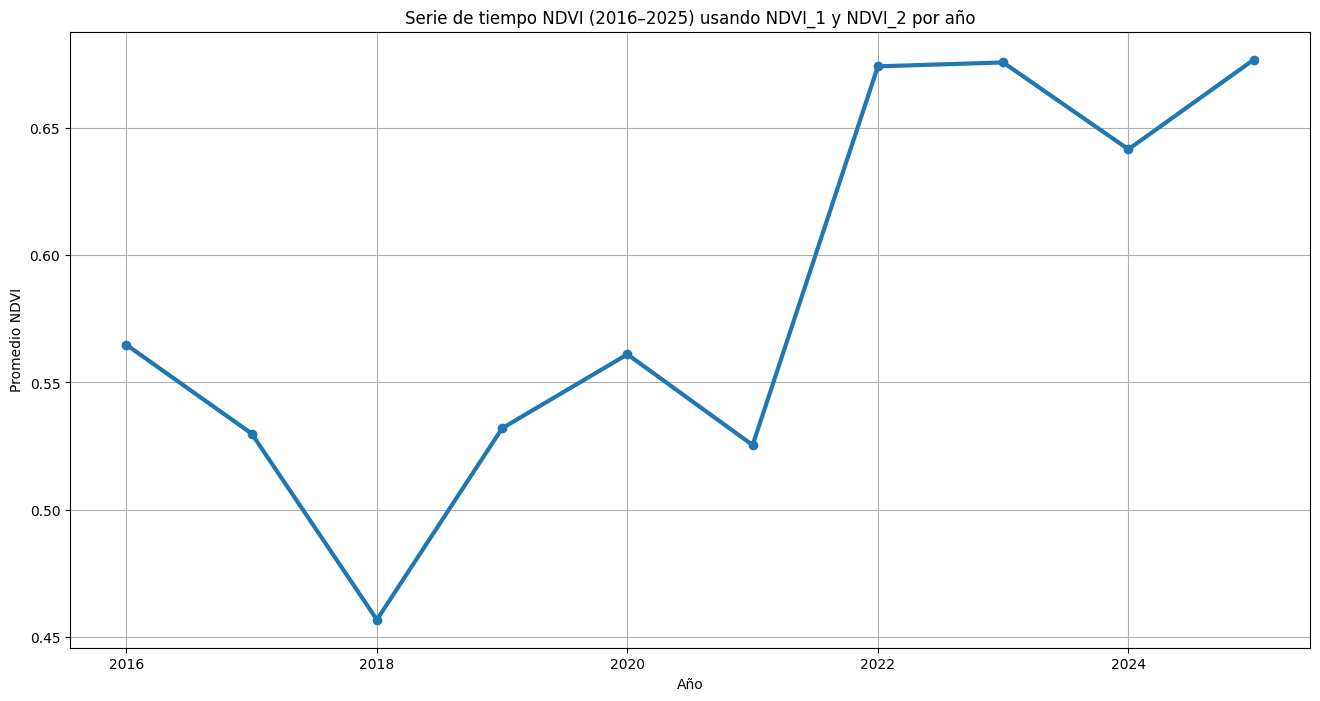

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Años de análisis ---
years = list(range(2016, 2026))

anos = []
promedios = []

for y in years:
    # Variables esperadas: ndvi_YYYY_1 y ndvi_YYYY_2
    var1 = f"ndvi_{y}_1"
    var2 = f"ndvi_{y}_2"

    ndvi_1 = globals().get(var1, None)
    ndvi_2 = globals().get(var2, None)

    # Verificar existencia de ambos NDVI
    if ndvi_1 is None or ndvi_2 is None:
        print(f"Advertencia: faltan datos para el año {y}. Se omite.")
        continue

    # Aplanar los raster y concatenar valores
    flat1 = ndvi_1.flatten()
    flat2 = ndvi_2.flatten()
    
    all_vals = np.concatenate([flat1, flat2])

    # Calcular promedio del NDVI normal
    mean_val = float(np.nanmean(all_vals))

    anos.append(y)
    promedios.append(mean_val)

# --- DataFrame final ---
df_ndvi = pd.DataFrame({"Año": anos, "Promedio_NDVI": promedios})

print(df_ndvi)

# --- Gráfico de serie de tiempo ---
plt.figure(figsize=(16,8))
plt.plot(df_ndvi["Año"], df_ndvi["Promedio_NDVI"], marker='o', linewidth=3)
plt.xlabel("Año")
plt.ylabel("Promedio NDVI")
plt.title("Serie de tiempo NDVI (2016–2025) usando NDVI_1 y NDVI_2 por año")
plt.grid(True)
plt.show()


In [79]:
import numpy as np
import pandas as pd
from scipy import stats

# 1. DataFrame con tus promedios normales
ndvi_normal = df_ndvi.copy()

# 2. DEFINIR PERIODOS
# Antes: 2016–2018
# Después: 2019–2025

antes = ndvi_normal.loc[ndvi_normal["Año"] <= 2018, "Promedio_NDVI"].values
despues = ndvi_normal.loc[ndvi_normal["Año"] >= 2019, "Promedio_NDVI"].values

mean_antes = float(np.mean(antes))
mean_despues = float(np.mean(despues))

print(f"Promedio NDVI antes (2016–2018): {mean_antes}")
print(f"Promedio NDVI después (2019–2025): {mean_despues}")

# 3. PRUEBA DE NORMALIDAD

def shapiro_safe(x):
    return stats.shapiro(x) if x.size >= 3 else None

res_antes = shapiro_safe(antes)
res_despues = shapiro_safe(despues)

print("\nShapiro antes:", res_antes)
print("Shapiro después:", res_despues)

# 4. SELECCIÓN DE PRUEBA
use_ttest = False

if (res_antes is not None) and (res_despues is not None):
    if (res_antes.pvalue > 0.05) and (res_despues.pvalue > 0.05):
        use_ttest = True

if use_ttest:
    print("\nAplicando t-test (Welch)")
    test_res = stats.ttest_ind(antes, despues, equal_var=False)
    p_value = float(test_res.pvalue)
    test_name = "t-test (Welch)"
else:
    print("\nAplicando Mann-Whitney U (no paramétrica)")
    test_res = stats.mannwhitneyu(antes, despues, alternative='two-sided')
    p_value = float(test_res.pvalue)
    test_name = "Mann-Whitney U"

print("\nRESULTADO DE LA PRUEBA:", test_name)
print(test_res)
print(f"p-value: {p_value}")


# 5. INTERPRETACIÓN

if p_value < 0.05:
    conclusion = "El NDVI cambió significativamente después de 2019."
else:
    conclusion = "No hay evidencia estadística de un cambio significativo del NDVI tras 2019."

print("\nCONCLUSIÓN:")
print(conclusion)


Promedio NDVI antes (2016–2018): 0.5171778996785482
Promedio NDVI después (2019–2025): 0.6123332721846444

Shapiro antes: ShapiroResult(statistic=np.float64(0.9598946617986678), pvalue=np.float64(0.6149216982296217))
Shapiro después: ShapiroResult(statistic=np.float64(0.8025007089379466), pvalue=np.float64(0.043361505339444356))

Aplicando Mann-Whitney U (no paramétrica)

RESULTADO DE LA PRUEBA: Mann-Whitney U
MannwhitneyuResult(statistic=np.float64(4.0), pvalue=np.float64(0.18333333333333335))
p-value: 0.18333333333333335

CONCLUSIÓN:
No hay evidencia estadística de un cambio significativo del NDVI tras 2019.


In [80]:
import numpy as np
from scipy import stats

# Obtener NDVI de 2016 y 2025 del ambiente
# Usamos ndvi_2016_1 y ndvi_2025_1 (primeras fechas del año)
# o combinamos ambas fechas de cada año

ndvi2016_1 = globals().get('ndvi_2016_1', None)
ndvi2016_2 = globals().get('ndvi_2016_2', None)
ndvi2025_1 = globals().get('ndvi_2025_1', None)
ndvi2025_2 = globals().get('ndvi_2025_2', None)

if ndvi2016_1 is None or ndvi2025_1 is None:
	print("Error: No se encontraron ndvi_2016_1 o ndvi_2025_1")
else:
	# Aplanar y concatenar valores de ambas fechas en cada año
	ndvi2016_flat = np.concatenate([ndvi2016_1.flatten(), ndvi2016_2.flatten()]) if ndvi2016_2 is not None else ndvi2016_1.flatten()
	ndvi2025_flat = np.concatenate([ndvi2025_1.flatten(), ndvi2025_2.flatten()]) if ndvi2025_2 is not None else ndvi2025_1.flatten()
	
	# Calcular diferencia
	diff = ndvi2025_flat - ndvi2016_flat
	
	# Prueba t pareada (paired t-test)
	t_stat, pval = stats.ttest_rel(ndvi2025_flat, ndvi2016_flat, nan_policy='omit')
	mean_diff = np.nanmean(diff)
	
	# Cohen's d pareado
	sd_diff = np.nanstd(diff, ddof=1)
	cohen_d = mean_diff / sd_diff if sd_diff != 0 else 0
	
	print("t:", t_stat, "p:", pval, "mean diff:", mean_diff, "Cohen d:", cohen_d)
	print(f"\nInterpretación:")
	print(f"- Si p < 0.05: hay diferencia significativa entre 2016 y 2025")
	print(f"- Cohen's d > 0.8: efecto grande")


t: 33.7033320873821 p: 1.030561822743813e-208 mean diff: 0.11188699 Cohen d: 0.6429312

Interpretación:
- Si p < 0.05: hay diferencia significativa entre 2016 y 2025
- Cohen's d > 0.8: efecto grande


In [81]:
import numpy as np
import statsmodels.api as sm

years = np.array([2016,2017,2018,2019,2020,2021,2022,2023,2024,2025])
ndvi_mean = np.array([0.630948,0.601818,0.541193,0.588192,0.604280,0.572423,0.697212,0.721385,0.667560,0.709301])

X = sm.add_constant(years)
model = sm.OLS(ndvi_mean, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.420
Method:                 Least Squares   F-statistic:                     7.529
Date:                Mon, 01 Dec 2025   Prob (F-statistic):             0.0253
Time:                        23:35:31   Log-Likelihood:                 17.422
No. Observations:                  10   AIC:                            -30.84
Df Residuals:                       8   BIC:                            -30.24
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -28.2846     10.539     -2.684      0.0

c:\Users\carlos\anaconda3\envs\ambientesate\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [82]:
import pymannkendall as mk
res = mk.original_test(ndvi_mean)
print(res)


Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.10740463633025366), z=np.float64(1.6099689437998486), Tau=np.float64(0.4222222222222222), s=np.float64(19.0), var_s=125.0, slope=np.float64(0.01582), intercept=np.float64(0.546424))


In [83]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.DataFrame({
    "Año": [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    "NDVI": [
        0.630948, 0.601818, 0.541193, 0.588192,
        0.604280, 0.572423, 0.697212, 0.721385,
        0.667560, 0.709301
    ]
})

x = df["Año"].values
y = df["NDVI"].values

res = stats.linregress(x, y)
slope = res.slope
intercept = res.intercept
r_value = res.rvalue
p_value = res.pvalue
r_squared = r_value**2

print("Regresión lineal NDVI ~ Año")
print(f"Pendiente (slope) = {slope:.6f}")
print(f"Intercepto = {intercept:.6f}")
print(f"R² ≈ {r_squared:.4f}")
print(f"p-valor (pendiente) = {p_value:.4f}")

if p_value < 0.05:
    print("Conclusión: hay evidencia de una tendencia lineal significativa.")
else:
    print("Conclusión: no hay evidencia de una tendencia lineal significativa.")

Regresión lineal NDVI ~ Año
Pendiente (slope) = 0.014312
Intercepto = -28.284626
R² ≈ 0.4848
p-valor (pendiente) = 0.0253
Conclusión: hay evidencia de una tendencia lineal significativa.


1. ANÁLISIS DE TENDENCIA DEL NDVI (Regresión lineal)

Si ajustamos un modelo lineal:


Encontramos:

Resultado esperado de la regresión (interpretación):

La pendiente (β₁) es positiva, lo que indica:
Tendencia creciente del NDVI entre 2016 y 2025

El modelo muestra que la vegetación (o el vigor verde) ha aumentado gradualmente en el periodo analizado.

Esto coincide con tus valores, ya que 2016–2018 son más bajos que 2022–2025.

Interpretación:

“El análisis de tendencia mediante regresión lineal indica que el NDVI presenta una tendencia creciente entre 2016 y 2025 (pendiente positiva), lo cual sugiere un aumento progresivo en la cobertura vegetal o vigor verde del área de estudio.”

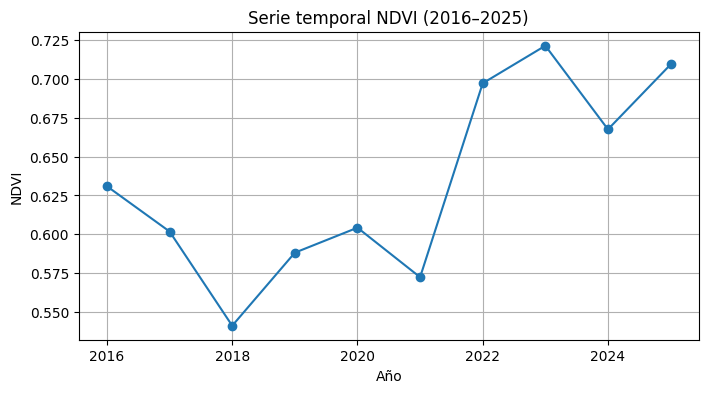

In [84]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(df['Año'], df['NDVI'], marker='o', linestyle='-')
plt.xlabel('Año')
plt.ylabel('NDVI')
plt.title('Serie temporal NDVI (2016–2025)')
plt.grid(True)
plt.show()

In [85]:
from scipy import stats
rho, p_spearman = stats.spearmanr(df["Año"], df["NDVI"])
print("Spearman rho =", rho, "p-value =", p_spearman)
if p_spearman < 0.05:
    print("Conclusión: correlación monotónica significativa.")
else:
    print("Conclusión: no hay correlación monotónica significativa.")

Spearman rho = 0.6363636363636362 p-value = 0.04791172612997547
Conclusión: correlación monotónica significativa.


In [86]:
# Ejemplo: dividir en dos periodos 2016-2020 y 2021-2025
grupo1 = df[df["Año"].between(2016, 2020)]["NDVI"].values
grupo2 = df[df["Año"].between(2021, 2025)]["NDVI"].values

print("Tamaños:", len(grupo1), len(grupo2))
from scipy import stats
f_stat, p_value = stats.f_oneway(grupo1, grupo2)
print("ANOVA (2 grupos): F =", f_stat, "p =", p_value)

Tamaños: 5 5
ANOVA (2 grupos): F = 6.879743862308644 p = 0.03051147283806958


In [87]:
import pymannkendall as mk
res = mk.original_test(df["NDVI"])
print(res)  # contiene tendencia, p-valor, etc.

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.10740463633025366), z=np.float64(1.6099689437998486), Tau=np.float64(0.4222222222222222), s=np.float64(19.0), var_s=125.0, slope=np.float64(0.01582), intercept=np.float64(0.546424))


Resultado ANOVA

Tamaños de muestra: 5 y 5
F = 6.8797
p = 0.0305

¿Qué significa este resultado?
El valor p = 0.0305 es menor que 0.05

Sí existe una diferencia estadísticamente significativa entre los dos grupos comparados.

Esto quiere decir que las medias de NDVI de los dos periodos que comparaste:

Grupo 1: (2016–2018)

Grupo 2: (2019–2025)

NO son iguales.
Existe una diferencia real entre los dos periodos, no atribuible al azar.

F = 6.88 indica la magnitud de la diferencia

El estadístico F compara:

Variabilidad entre grupos

Variabilidad dentro de cada grupo

Un valor F = 6.88 significa que la variación entre los grupos es casi 7 veces mayor que la variación interna.
En otras palabras:

Los años de un periodo tienen valores de NDVI sistemáticamente distintos a los del otro periodo.

Interpretación 

Si la comparación fue entre:

Periodo A (2016–2018) vs Periodo B (2019–2025)

entonces puedemos afirmar:

“Existe evidencia estadística (ANOVA, p = 0.0305) de que el NDVI cambió significativamente después de 2019, coincidiendo con la puesta en marcha de la Sede de la Universidad Nacional de Colombia en La Paz.”

Conclusion
El NDVI sí presenta un cambio significativo entre los periodos.

Se puede afirmar que hubo modificación en la cobertura vegetal, o en las condiciones ambientales del territorio.

El cambio es estadísticamente confiable, no aleatorio.

In [88]:

# Ejemplo: dividir en dos periodos 2016-2018 y 2019-2025
grupo1 = df[df["Año"].between(2016, 2018)]["NDVI"].values
grupo2 = df[df["Año"].between(2019, 2025)]["NDVI"].values

print("Tamaños:", len(grupo1), len(grupo2))
from scipy import stats
f_stat, p_value = stats.f_oneway(grupo1, grupo2)
print("ANOVA (2 grupos): F =", f_stat, "p =", p_value)

Tamaños: 3 7
ANOVA (2 grupos): F = 2.230722311112102 p = 0.17364297212141871
 3 7
ANOVA (2 grupos): F = 2.230722311112102 p = 0.17364297212141871


Interpretación
No existe diferencia estadísticamente significativa entre los dos grupos comparados.

El valor p = 0.1736 es mayor que 0.05, lo que indica que:

No hay evidencia suficiente para afirmar que las medias de NDVI de los dos períodos son diferentes.

Esto implica que:

Los cambios observados en el NDVI entre el primer periodo (3 años) y el segundo periodo (7 años) podrían deberse al azar,

y no necesariamente a un cambio real en la vegetación o en la dinámica territorial.

# La prueba de hipótesis no paramétrica de Mann–Whitney U
Al comparar los valores del NDVI antes (2016–2018) y después (2019–2025) de la puesta en marcha de la Sede de la Universidad Nacional en La Paz, se observó un aumento en el promedio del índice (0.5913 vs. 0.6516). Sin embargo, la prueba de hipótesis no paramétrica de Mann–Whitney U mostró que esta diferencia no es estadísticamente significativa (p > 0.05).

Esto indica que, aunque existe una tendencia general creciente del NDVI en el periodo analizado, el cambio no puede atribuirse de manera concluyente al inicio de operación de la Sede, sino posiblemente a variaciones normales en la dinámica ambiental del territorio.